<div style='text-align: center'>
    <p style='font-size:50px; margin-bottom: 0px'>Statistics</p>
    <o style='font-size:20px;'>This notebook handles calculating stats for all variations and putting them into a table</p>
</div>

In [1]:
import cogsworth
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import sys
sys.path.append('../src')
import plotting, helpers, constants
from importlib import reload

%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [2]:
reload(constants)
files = constants.SIMULATION_FILES

main_labels = [
    r"$f_{\rm bin} = 1.0$",
    r"$f_{\rm bin} = 0.0$",
    "No BH kicks", "No fallback rescaling", "Hobbs+2005",
    "Fryer+2012 Rapid", r"Mandel\&Muller2020", "Maltsev+2025",
    r"$f_{\rm fb} = 0.0$", r"$f_{\rm fb} = 0.25$", r"$f_{\rm fb} = 0.75$", r"$f_{\rm fb} = 1.0$",
    r"$P({\rm pf}) = 0.0$", r"$P({\rm pf}) = 1.0$",
    'Time-evolving potential'
]
markers = ['o'] * (len(main_labels) - 1) + ['d']
initC_labels = [
    r"$\alpha_{\rm IMF} = -1.9$", r"$\alpha_{\rm IMF} = -2.7$",
    r"$\kappa = -1.0$", r"$\kappa = 1.0$",
    r"$q_{\rm min} = -1.0$",
    r"$\pi = 0.0$", r"$\pi = -1.0$",
    r"$P_{\rm orb, max} = 10^3\,{\rm days}$"
]
markers += ['^'] * len(initC_labels)
main_labels += initC_labels
mt_labels = [
    r"$\beta = 0.0$", r"$\beta = 0.5$", r"$\beta = 1.0$",
    r"$\alpha_{\rm CE} = 0.1$", r"$\alpha_{\rm CE} = 0.5$", r"$\alpha_{\rm CE} = 2.0$", r"$\alpha_{\rm CE} = 10.0$",
    r"$q_{\rm crit, B} = 0$", r"$q_{\rm crit, B} = \infty$",
]
markers += ['s'] * len(mt_labels)
labels = main_labels + mt_labels
mt_labels = [main_labels[0]] + mt_labels  # include the fiducial model in the MT section

In [3]:
plot_labels = [
    "Fiducial",
    "Singles",
    "No BH kicks",
    "No fallback rescaling",
    "Hobbs+2005",
    "Fryer+2012 Rapid", r"Mandel & Muller 2020", "Maltsev+2025 (Default)",
    r"Maltsev+2025 ($f_{\rm fb} = 0.0$)", r"Maltsev+2025 ($f_{\rm fb} = 0.25$)", r"Maltsev+2025 ($f_{\rm fb} = 0.75$)", r"Maltsev+2025 ($f_{\rm fb} = 1.0$)",
    r"Maltsev+2025 ($P({\rm pf}) = 0.0$)", r"Maltsev+2025 ($P({\rm pf}) = 1.0$)",
    'Time-evolving potential',
    # initC
    r"$\alpha_{\rm IMF} = -1.9$", r"$\alpha_{\rm IMF} = -2.7$",
    r"$\kappa = -1.0$", r"$\kappa = 1.0$",
    r"$q_{\rm min} = -1.0$",
    r"$\pi = 0.0$", r"$\pi = -1.0$",
    r"$P_{\rm orb, max} = 10^3\,{\rm days}$",
    # mt
    r"$\beta = 0.0$", r"$\beta = 0.5$", r"$\beta = 1.0$",
    r"$\alpha_{\rm CE} = 0.1$", r"$\alpha_{\rm CE} = 0.5$", r"$\alpha_{\rm CE} = 2.0$", r"$\alpha_{\rm CE} = 10.0$",
    r"$q_{\rm crit, B} = 0$", r"$q_{\rm crit, B} = \infty$"
]

In [4]:
groups = [
    {
        "title": "Binary fraction",
        "members": [r"$f_{\rm bin} = 1.0$", r"$f_{\rm bin} = 0.0$"],
        "colour": "black"
    },
    {
        "title": "Supernova natal kicks",
        "members": ["No BH kicks", "No fallback rescaling", "Hobbs+2005"],
        "colour": "tab:green"
    },
    {
        "title": "Remnant mass prescriptions",
        "members": ["Fryer+2012 Rapid", r"Mandel\&Muller2020", "Maltsev+2025", r"$f_{\rm fb} = 0.0$", r"$f_{\rm fb} = 0.25$", r"$f_{\rm fb} = 0.75$", r"$f_{\rm fb} = 1.0$", r"$P({\rm pf}) = 0.0$", r"$P({\rm pf}) = 1.0$"],
        "colour": "#f14432"
    },
    {
        "title": "Time-evolving potential",
        "members": ['Time-evolving potential'],
        "colour": "#FF9D1E"
    },
    {
        "title": "Initial distributions",
        "members": [r"$\alpha_{\rm IMF} = -1.9$", r"$\alpha_{\rm IMF} = -2.7$", r"$\kappa = -1.0$", r"$\kappa = 1.0$", r"$q_{\rm min} = -1.0$", r"$\pi = 0.0$", r"$\pi = -1.0$", r"$P_{\rm orb, max} = 10^3\,{\rm days}$"],
        "colour": "black"
    },
    {
        "title": "Mass transfer physics",
        "members": [r"$\beta = 0.0$", r"$\beta = 0.5$", r"$\beta = 1.0$", r"$\alpha_{\rm CE} = 0.1$", r"$\alpha_{\rm CE} = 0.5$", r"$\alpha_{\rm CE} = 2.0$", r"$\alpha_{\rm CE} = 10.0$", r"$q_{\rm crit, B} = 0$", r"$q_{\rm crit, B} = \infty$"],
        "colour": "tab:blue"
    }
]

group_spacing = 2.0
member_spacing = 1.0

y_positions = [("group", "Binary fraction", (group_spacing + member_spacing) / 2)]
group_ind = 0
label_ind = 0
while label_ind < len(labels):
    label = labels[label_ind]
    if label not in groups[group_ind]["members"]:
        group_ind += 1
        y_positions.append(("group", groups[group_ind]["title"], (group_spacing + member_spacing) / 2))
        continue

    y_positions.append(("member", label, member_spacing))
    label_ind += 1

In [5]:
reload(helpers)
pops, data = helpers.load_postprocessed_pops(files, labels, [None] * len(files))

Loading post-processed data for $f_{\rm bin} = 1.0$ from fiducial
Loading post-processed data for $f_{\rm bin} = 0.0$ from singles
Loading post-processed data for No BH kicks from bhflag_0
Loading post-processed data for No fallback rescaling from bhflag_3
Loading post-processed data for Hobbs+2005 from kickflag_1
Loading post-processed data for Fryer+2012 Rapid from fryer_rapid
Loading post-processed data for Mandel\&Muller2020 from mandel_muller
Loading post-processed data for Maltsev+2025 from maltsev_fallback_0.5
Loading post-processed data for $f_{\rm fb} = 0.0$ from maltsev_fallback_0.0
Loading post-processed data for $f_{\rm fb} = 0.25$ from maltsev_fallback_0.25
Loading post-processed data for $f_{\rm fb} = 0.75$ from maltsev_fallback_0.75
Loading post-processed data for $f_{\rm fb} = 1.0$ from maltsev_fallback_1.0
Loading post-processed data for $P({\rm pf}) = 0.0$ from maltsev_pf_prob_0.0
Loading post-processed data for $P({\rm pf}) = 1.0$ from maltsev_pf_prob_1.0
Loading pos

In [6]:
for pop in pops:
    if "companion" not in data[pop.label]:
        for key in ["n_BH_star", "n_BH_wd", "n_BH_NS", "n_BH_BH", "n_NS_star", "n_NS_wd", "n_NS_NS"]:
            data[pop.label][key] = np.nan
        print("Skipping", pop.label)
        continue
    data[pop.label]["n_BH_star"] = np.sum((data[pop.label]["sep"]["BH"] > 0) & (data[pop.label]["companion"]["BH"] < 10))
    data[pop.label]["n_BH_wd"] = np.sum((data[pop.label]["sep"]["BH"] > 0) & (np.isin(data[pop.label]["companion"]["BH"], [10, 11, 12])))
    data[pop.label]["n_BH_NS"] = np.sum((data[pop.label]["sep"]["BH"] > 0) & (data[pop.label]["companion"]["BH"] == 13))
    data[pop.label]["n_BH_BH"] = np.sum((data[pop.label]["sep"]["BH"] > 0) & (data[pop.label]["primary"]["BH"]) & (data[pop.label]["companion"]["BH"] == 14))

    data[pop.label]["n_NS_star"] = np.sum((data[pop.label]["sep"]["NS"] > 0) & (data[pop.label]["companion"]["NS"] < 10))
    data[pop.label]["n_NS_wd"] = np.sum((data[pop.label]["sep"]["NS"] > 0) & (np.isin(data[pop.label]["companion"]["NS"], [10, 11, 12])))
    data[pop.label]["n_NS_NS"] = np.sum((data[pop.label]["sep"]["NS"] > 0) & (data[pop.label]["primary"]["NS"]) & (data[pop.label]["companion"]["NS"] == 13))

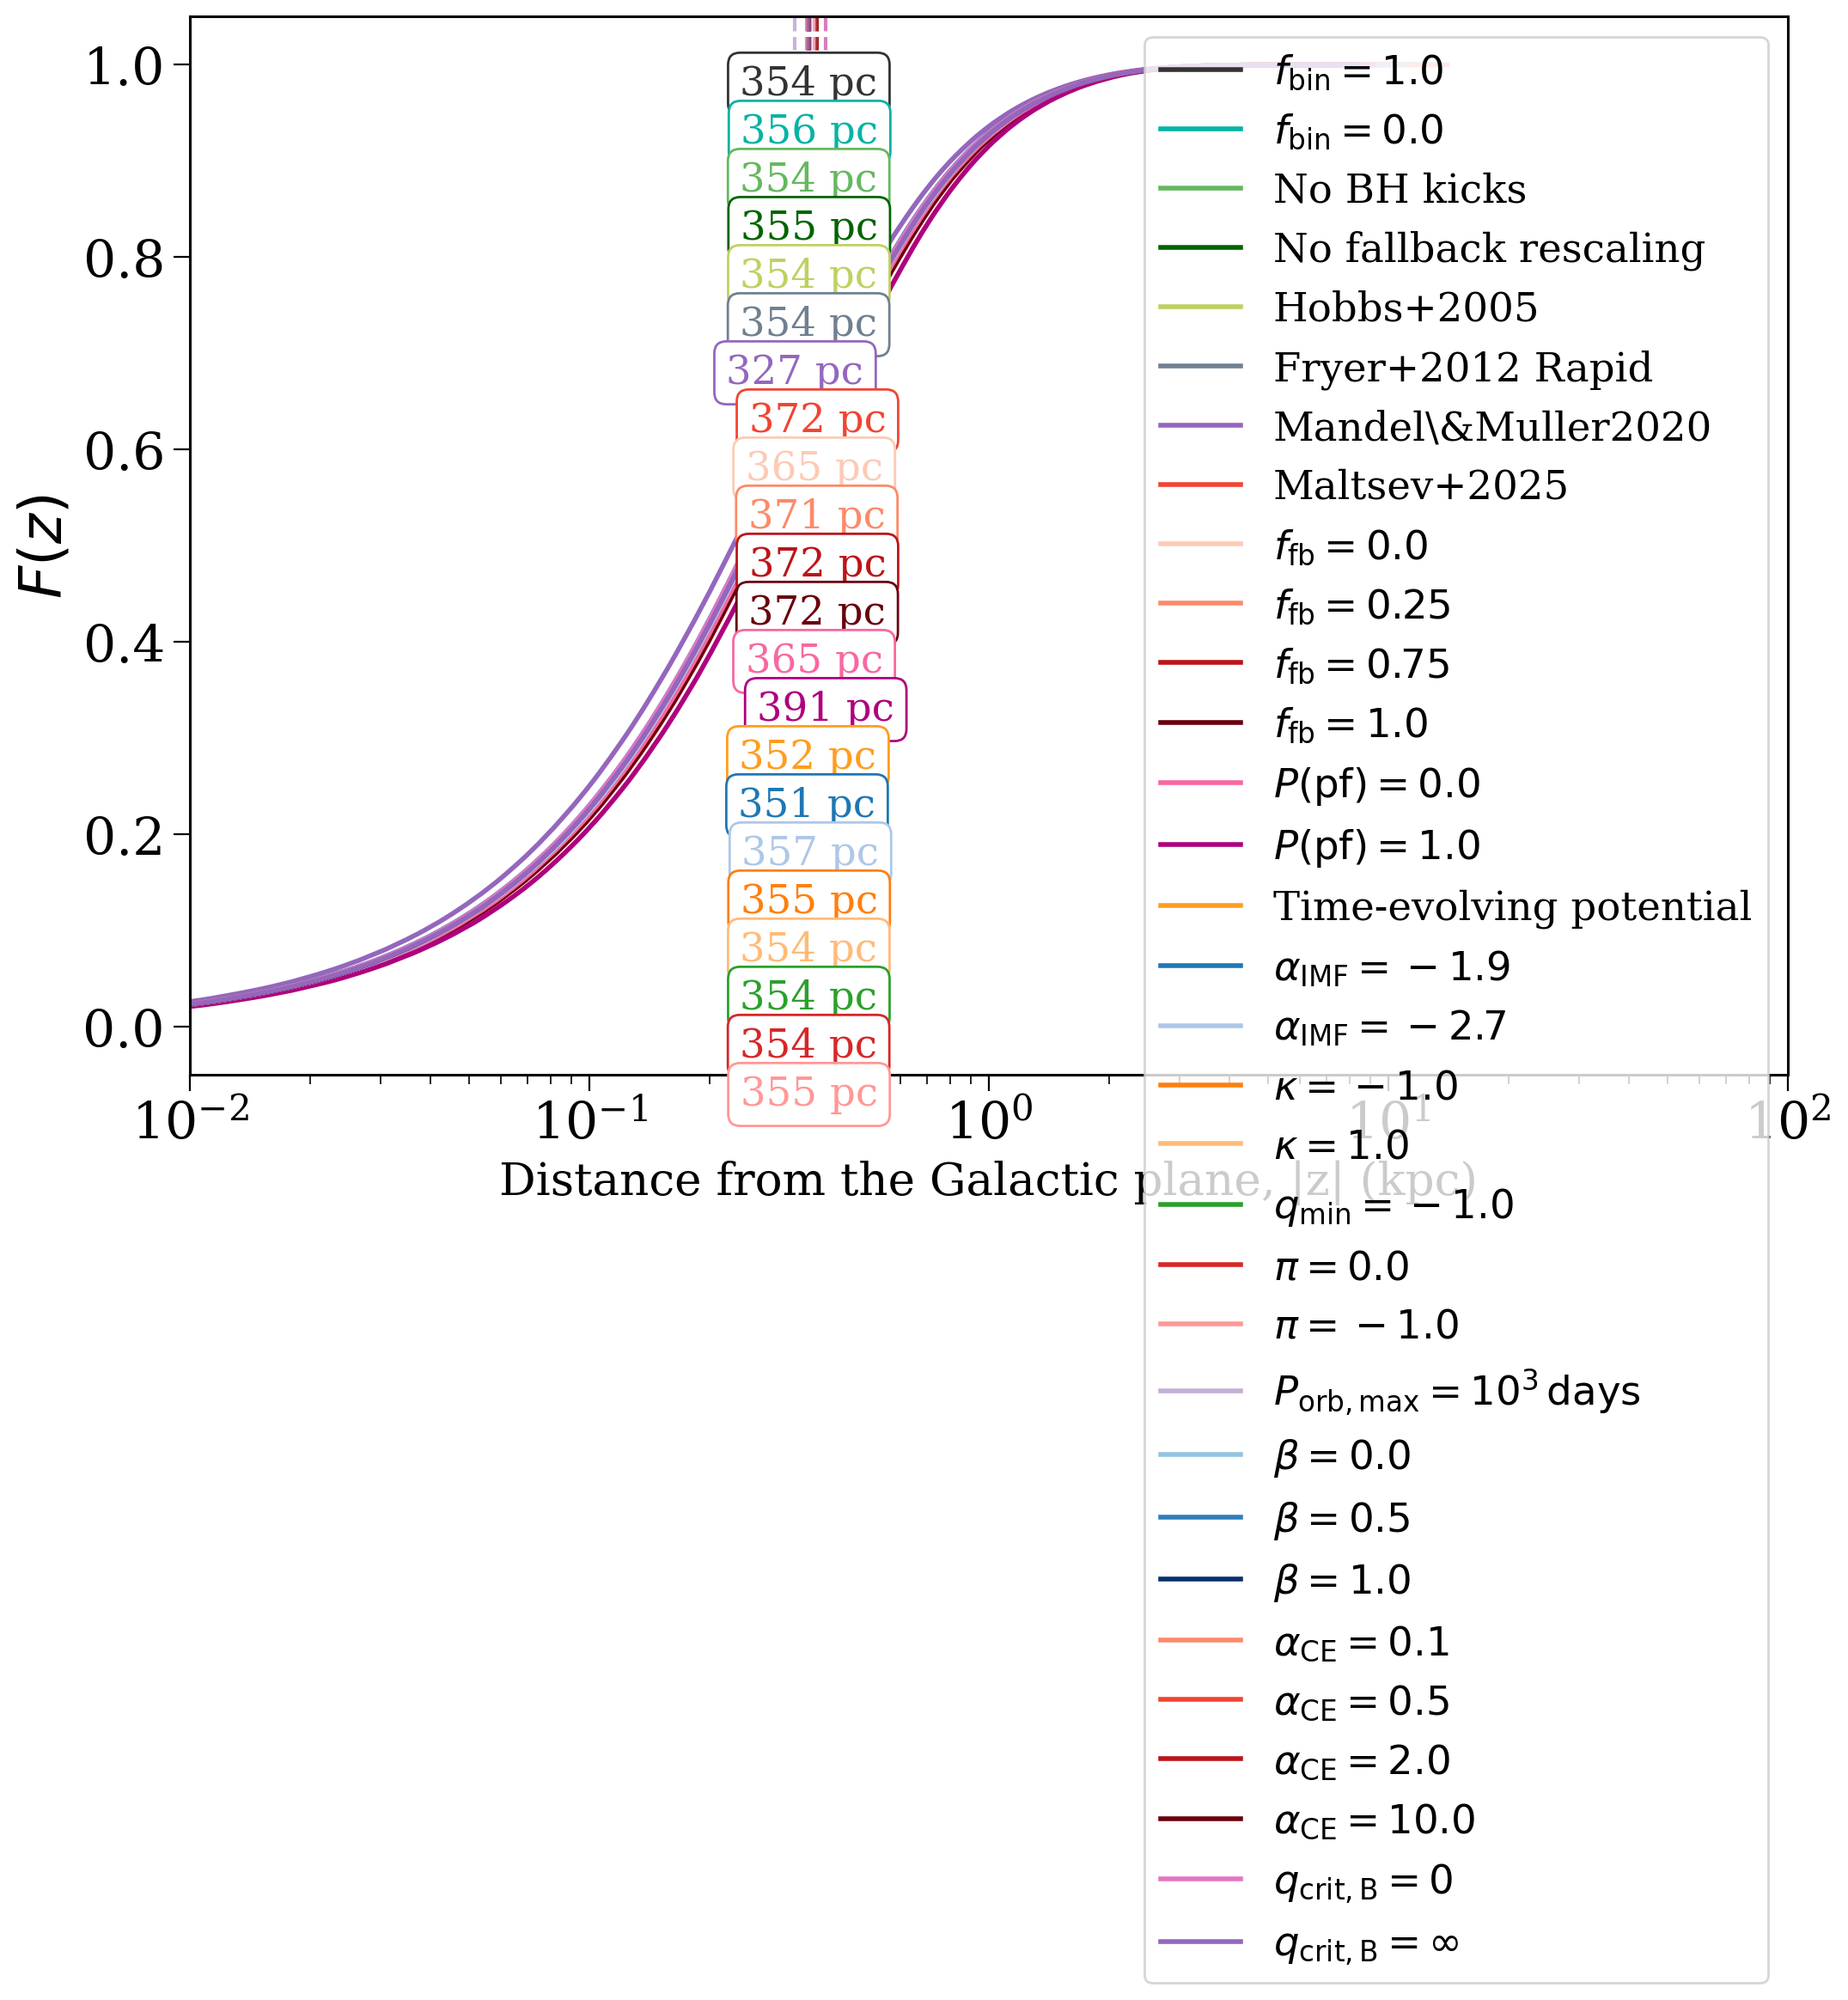

In [7]:
reload(plotting)

fig, ax = plt.subplots()

scale_heights = []
scale_height_errs = []

for label, colour in zip(labels, constants.SIMULATION_COLOURS):
    sh, sh_err, _, _ = plotting.estimate_scale_height_cdf(
        z=data[label]["init_z"]["BH"][~data[label]["escaped"]["BH"]],
        fig=fig,
        ax=ax,
        plot=True,#label == "No BH kicks",
        show=False,
        label=label,
        colour=colour,
        xlim=(1e-2, 1e2),
        scale_height_loc=1 - labels.index(label) * 0.05
    )
    scale_heights.append(sh * 1000)
    scale_height_errs.append(0 * 1000)

ax.legend()
plt.show()

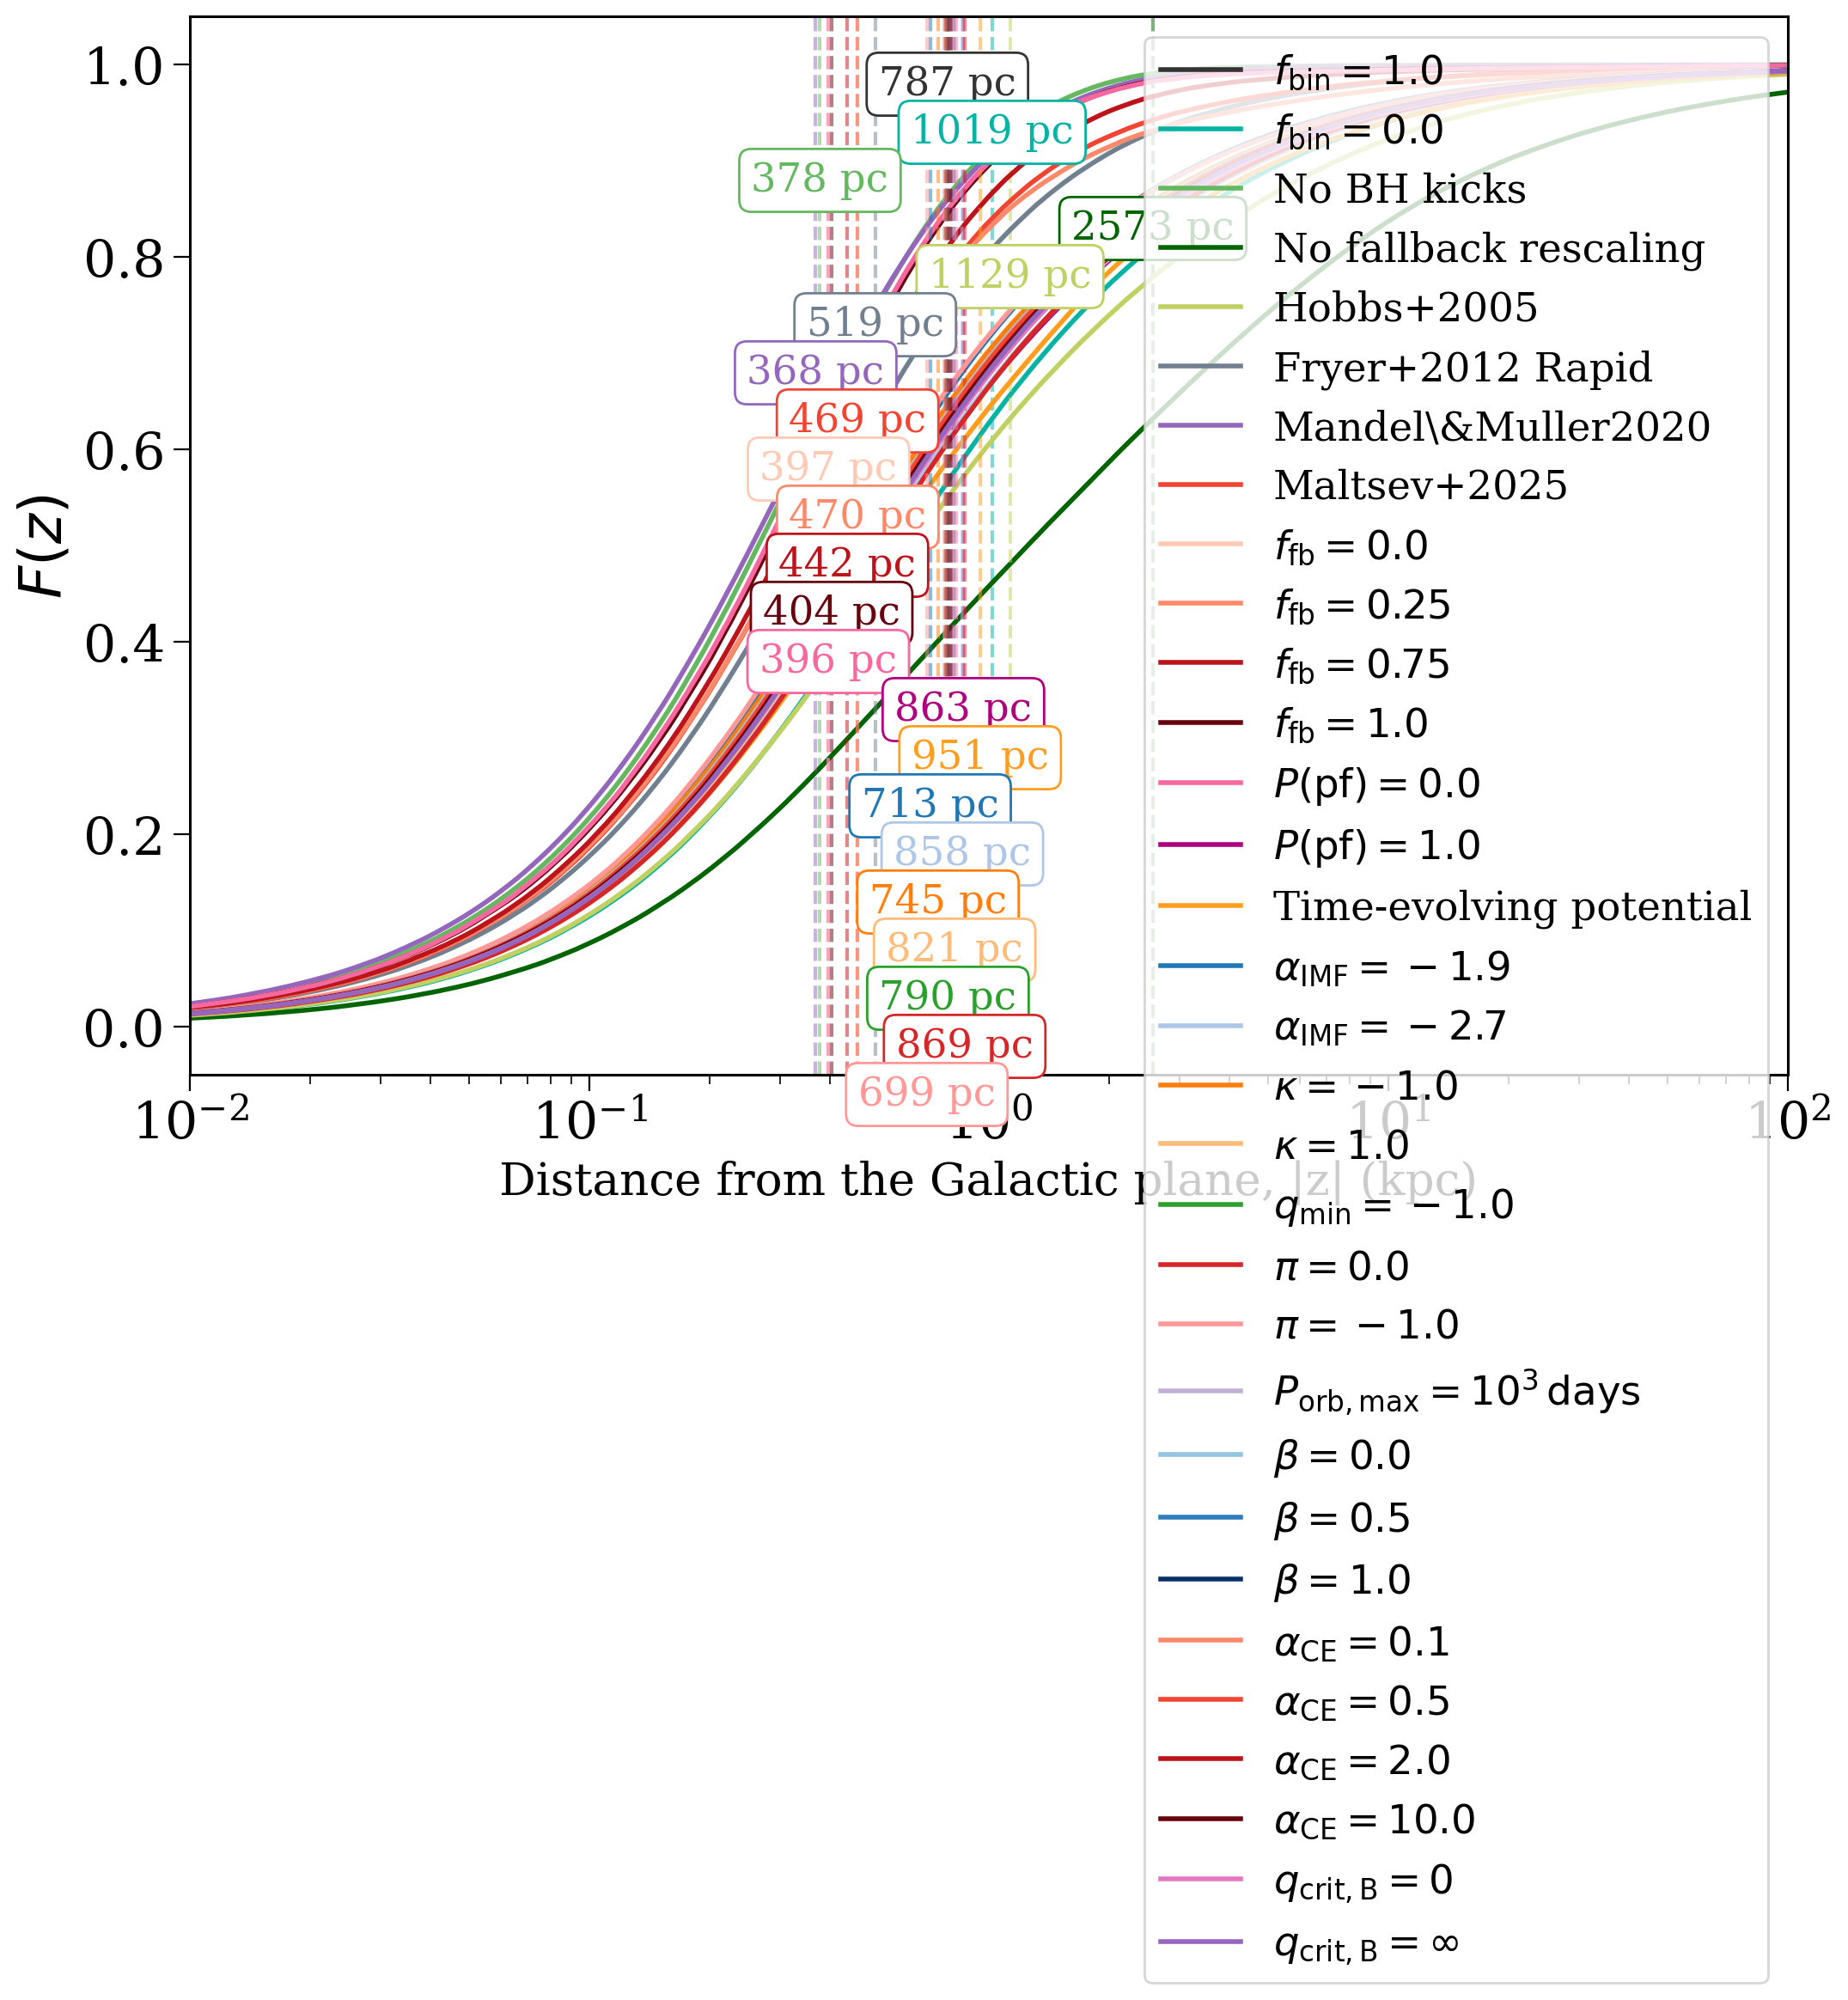

In [8]:
reload(plotting)

fig, ax = plt.subplots()

scale_heights = []
scale_height_errs = []

for label, colour in zip(labels, constants.SIMULATION_COLOURS):
    sh, sh_err, _, _ = plotting.estimate_scale_height_cdf(
        z=data[label]["pos"]["BH"][:, 2][~data[label]["escaped"]["BH"]],
        fig=fig,
        ax=ax,
        plot=True,#label == "No BH kicks",
        show=False,
        label=label,
        colour=colour,
        xlim=(1e-2, 1e2),
        scale_height_loc=1 - labels.index(label) * 0.05
    )
    scale_heights.append(sh * 1000)
    scale_height_errs.append(0 * 1000)

ax.legend()
plt.show()

In [9]:
stats = {
    "scale_up": [6e10 / data[label]["mass_binaries"] for label in labels],
    "n_BH": [data[label]["n_BH"] for label in labels],
    "m_BH": [sum(data[label]["mass"]["BH"]) for label in labels],
    "scale_height": scale_heights,
    "scale_height_err": scale_height_errs,
    r"$f_{\rm esc}$": [data[label]["escaped"]["BH"].sum() / len(data[label]["escaped"]["BH"])
                       for label in labels],
    r"$\langle m \rangle_{|z| < 1 \, {\rm kpc}}$": [data[label]["mass"]["BH"][(abs(data[label]["pos"]["BH"][:, 2]) < 1) & ~(data[label]["escaped"]["BH"])].mean() for label in labels],
    r"$\langle m \rangle_{|z| \ge 1 \, {\rm kpc}}$": [data[label]["mass"]["BH"][(abs(data[label]["pos"]["BH"][:, 2]) >= 1) & ~(data[label]["escaped"]["BH"])].mean() for label in labels],
    r"$f_{\rm bound}$": [(data[label]["sep"]["BH"] > 0).sum() / data[label]["n_BH"] for label in labels],
    r"$f_{\rm merger}$": [(data[label]["sep"]["BH"] == 0).sum() / data[label]["n_BH"] for label in labels],
    r"$f_{\rm unbound}$": [(data[label]["sep"]["BH"] < 0).sum() / data[label]["n_BH"] for label in labels],
    "n_BH_star": [data[label]["n_BH_star"] for label in labels],
    "n_BH_wd": [data[label]["n_BH_wd"] for label in labels],
    "n_BH_NS": [data[label]["n_BH_NS"] for label in labels],
    "n_BH_BH": [data[label]["n_BH_BH"] for label in labels],
    "n_NS_star": [data[label]["n_NS_star"] for label in labels],
    "n_NS_wd": [data[label]["n_NS_wd"] for label in labels],
    "n_NS_NS": [data[label]["n_NS_NS"] for label in labels],
}

df = pd.DataFrame(stats)
df.index = labels

# fix stats for singles because wide binaries make it funky
df.loc[r"$f_{\rm bin} = 0.0$", [r"$f_{\rm bound}$", r"$f_{\rm merger}$", r"$f_{\rm unbound}$", "n_BH_star", "n_BH_wd", "n_BH_NS", "n_BH_BH", "n_NS_star", "n_NS_wd", "n_NS_NS"]] = [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]

for col, norm in zip(
    ["n_BH", "m_BH", "n_BH_star", "n_BH_wd", "n_BH_NS", "n_BH_BH", "n_NS_star", "n_NS_wd", "n_NS_NS"],
    [1e8, 1e9, 1e4, 1e5, 1e5, 1e6, 1e4, 1e5, 1e4]
):
    df[col] *= df["scale_up"] / norm
del df["scale_up"]

latex_header = [r"$N_{\rm BH} / 10^8$", r"$M_{\rm BH} / 10^9 M_\odot$", r"$h_z$ (pc)", r"$\sigma_{h_z}$ (pc)"]
df.rename(columns=dict(zip(df.columns, latex_header)), inplace=True)
df.rename(columns={
    "n_BH_star": r"$N_{\rm BH\text{-}star} / 10^4$",
    "n_BH_wd": r"$N_{\rm BH\text{-}WD} / 10^5$",
    "n_BH_NS": r"$N_{\rm BH\text{-}NS} / 10^5$",
    "n_BH_BH": r"$N_{\rm BH\text{-}BH} / 10^6$",
    "n_NS_star": r"$N_{\rm NS\text{-}star} / 10^4$",
    "n_NS_wd": r"$N_{\rm NS\text{-}WD} / 10^5$",
    "n_NS_NS": r"$N_{\rm NS\text{-}NS} / 10^4$",
}, inplace=True)

df.round(2)

,$N_{\rm BH} / 10^8$,$M_{\rm BH} / 10^9 M_\odot$,$h_z$ (pc),$\sigma_{h_z}$ (pc),$f_{\rm esc}$,"$\langle m \rangle_{|z| < 1 \, {\rm kpc}}$","$\langle m \rangle_{|z| \ge 1 \, {\rm kpc}}$",$f_{\rm bound}$,$f_{\rm merger}$,$f_{\rm unbound}$,$N_{\rm BH\text{-}star} / 10^4$,$N_{\rm BH\text{-}WD} / 10^5$,$N_{\rm BH\text{-}NS} / 10^5$,$N_{\rm BH\text{-}BH} / 10^6$,$N_{\rm NS\text{-}star} / 10^4$,$N_{\rm NS\text{-}WD} / 10^5$,$N_{\rm NS\text{-}NS} / 10^4$
$f_{\rm bin} = 1.0$,1.73,1.51,787.15,0,0.03,9.41,7.47,0.09,0.33,0.58,18.38,13.21,1.29,6.64,47.13,30.92,9.88
$f_{\rm bin} = 0.0$,1.64,1.43,1018.74,0,0.03,9.68,7.39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
No BH kicks,1.69,1.47,377.69,0,0.00,8.57,9.79,0.32,0.35,0.32,77.96,58.10,3.73,23.99,48.06,30.90,9.84
No fallback rescaling,1.77,1.54,2572.96,0,0.16,8.01,9.18,0.00,0.30,0.69,2.78,2.76,0.40,0.24,47.50,31.03,9.83
Hobbs+2005,1.81,1.57,1129.48,0,0.03,9.76,7.26,0.07,0.31,0.62,16.89,11.20,0.51,5.87,36.35,22.06,5.47
Fryer+2012 Rapid,1.34,1.51,519.26,0,0.01,11.51,10.23,0.15,0.34,0.51,38.48,25.49,3.37,8.47,44.25,26.37,9.28
Mandel\&Muller2020,2.17,1.90,368.47,0,0.00,8.81,8.41,0.26,0.42,0.32,110.18,82.18,3.10,23.48,43.87,24.12,9.10
Maltsev+2025,0.38,0.47,469.21,0,0.01,12.90,10.87,0.17,0.31,0.51,16.39,10.77,3.78,2.45,45.86,28.25,9.25
$f_{\rm fb} = 0.0$,0.31,0.43,396.78,0,0.00,13.79,15.18,0.21,0.31,0.48,16.16,10.67,4.00,2.40,44.91,28.22,9.34
$f_{\rm fb} = 0.25$,0.37,0.45,469.57,0,0.02,12.88,9.52,0.17,0.31,0.52,16.23,10.68,3.74,2.43,45.22,28.18,9.29


# Main summary table

In [10]:
first_label_to_section = {
    r"$f_{\rm bin} = 0.0$": "Binary fraction", "No BH kicks": "Supernova natal kicks",
    "Fryer+2012 Rapid": "Remnant mass prescriptions",
    r"$f_{\rm fb} = 0.0$": "Maltsev+2025 fallback mass fraction",
    r"$P({\rm pf}) = 0.0$": "Maltsev+2025 partial fallback probability",
    "Time-evolving potential": "Galactic gravitational potential",
    r"$\alpha_{\rm IMF} = -1.9$": "Initial mass function",
    r"$\kappa = -1.0$": "Initial mass ratio distribution",
    r"$\pi = 0.0$": "Initial orbital period distribution"
}

cols = [col for col in df.columns if col != r"$\sigma_{h_z}$ (pc)"]
latex_table = r"""\begin{tabular}{lcccccccc}
\toprule
"""
latex_table += "Model & " + " & ".join(cols[:-8]) + r" \\" + "\n"
latex_table += r"\midrule" + "\n"

in_maltsev_subsection = False



for i, row in df.loc[main_labels].iterrows():
    if i in first_label_to_section:

        if first_label_to_section[i].startswith("Maltsev+2025"):
            in_maltsev_subsection = True
            first_label_to_section[i] = r"\quad " + first_label_to_section[i]
        else:
            in_maltsev_subsection = False
            # add a small bit of vertical space before the section header
            latex_table += r"\addlinespace[0.5em]" + "\n"

        header_type = "bf" if not in_maltsev_subsection else "it"
        latex_table += r"\multicolumn{8}{l}{" + r"\text" + header_type + "{" + first_label_to_section[i] + r"}} \\" + "\n"

    vals = row.values

    bound_perc = fr"${vals[7] * 100:1.0f}\%$" if not np.isnan(vals[7]) else "-"
    merger_perc = fr"${vals[8] * 100:1.0f}\%$" if not np.isnan(vals[8]) else "-"

    model_name = r"\quad" + (r"\quad " if in_maltsev_subsection else " ") + i
    if i == r"$f_{\rm bin} = 1.0$":
        model_name = r"\textbf{Fiducial}"

    latex_table += model_name + f' & ${vals[0]:.2f}$ & ${vals[1]:.2f}$ & ${vals[2]:.0f}$ & {vals[4] * 100:1.1f}\% & ${vals[5]:.2f}$ & ${vals[6]:.2f}$ & {bound_perc} & {merger_perc} \\\\' + "\n"
latex_table += r"\bottomrule" + "\n"
latex_table += r"\end{tabular}"

print(latex_table)

\begin{tabular}{lcccccccc}
\toprule
Model & $N_{\rm BH} / 10^8$ & $M_{\rm BH} / 10^9 M_\odot$ & $h_z$ (pc) & $f_{\rm esc}$ & $\langle m \rangle_{|z| < 1 \, {\rm kpc}}$ & $\langle m \rangle_{|z| \ge 1 \, {\rm kpc}}$ & $f_{\rm bound}$ & $f_{\rm merger}$ \\
\midrule
\textbf{Fiducial} & $1.73$ & $1.51$ & $787$ & 2.7\% & $9.41$ & $7.47$ & $9\%$ & $33\%$ \\
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Binary fraction}} \\
\quad $f_{\rm bin} = 0.0$ & $1.64$ & $1.43$ & $1019$ & 3.5\% & $9.68$ & $7.39$ & - & - \\
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Supernova natal kicks}} \\
\quad No BH kicks & $1.69$ & $1.47$ & $378$ & 0.0\% & $8.57$ & $9.79$ & $32\%$ & $35\%$ \\
\quad No fallback rescaling & $1.77$ & $1.54$ & $2573$ & 15.6\% & $8.01$ & $9.18$ & $0\%$ & $30\%$ \\
\quad Hobbs+2005 & $1.81$ & $1.57$ & $1129$ & 2.6\% & $9.76$ & $7.26$ & $7\%$ & $31\%$ \\
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Remnant mass prescriptions}} \\
\quad Fryer+2012 Rapid & $1.34$ & $1.51$ & $519$ 

# Appendix MT summary plot

In [11]:
first_label_to_section = {
    # r"$f_{\rm bin} = 1.0$": "Fiducial",
    r"$\beta = 0.0$": "Mass transfer efficiency",
    r"$\alpha_{\rm CE} = 0.1$": "Common-envelope efficiency",
    r"$q_{\rm crit, B} = 0$": "Mass transfer stability",
}

cols = [col for col in df.columns if col != r"$\sigma_{h_z}$ (pc)"]
latex_table = r"""\begin{tabular}{lcccccccc}
\toprule
"""
latex_table += "Model & " + " & ".join(cols[:-8]) + r" \\" + "\n"
latex_table += r"\midrule" + "\n"

for i, row in df.loc[mt_labels].iterrows():
    if i in first_label_to_section:
        # add a small bit of vertical space before the section header
        latex_table += r"\addlinespace[0.5em]" + "\n"
        latex_table += r"\multicolumn{8}{l}{" + r"\textbf{" + first_label_to_section[i] + r"}} \\" + "\n"
    vals = row.values

    model_name = r"\quad" + (r"\quad " if in_maltsev_subsection else " ") + i
    if i == r"$f_{\rm bin} = 1.0$":
        model_name = r"\textbf{Fiducial}"

    bound_perc = fr"${vals[7] * 100:1.0f}\%$" if not np.isnan(vals[7]) else "-"
    merger_perc = fr"${vals[8] * 100:1.0f}\%$" if not np.isnan(vals[8]) else "-"

    latex_table += model_name + f' & ${vals[0]:.2f}$ & ${vals[1]:.2f}$ & ${vals[2]:.0f}$ & {vals[4] * 100:1.1f}\% & ${vals[5]:.2f}$ & ${vals[6]:.2f}$ & {bound_perc} & {merger_perc} \\\\' + "\n"
latex_table += r"\bottomrule" + "\n"
latex_table += r"\end{tabular}"

print(latex_table)

\begin{tabular}{lcccccccc}
\toprule
Model & $N_{\rm BH} / 10^8$ & $M_{\rm BH} / 10^9 M_\odot$ & $h_z$ (pc) & $f_{\rm esc}$ & $\langle m \rangle_{|z| < 1 \, {\rm kpc}}$ & $\langle m \rangle_{|z| \ge 1 \, {\rm kpc}}$ & $f_{\rm bound}$ & $f_{\rm merger}$ \\
\midrule
\textbf{Fiducial} & $1.73$ & $1.51$ & $787$ & 2.7\% & $9.41$ & $7.47$ & $9\%$ & $33\%$ \\
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Mass transfer efficiency}} \\
\quad $\beta = 0.0$ & $1.37$ & $1.22$ & $772$ & 2.6\% & $9.65$ & $7.42$ & $11\%$ & $38\%$ \\
\quad $\beta = 0.5$ & $1.53$ & $1.35$ & $790$ & 2.7\% & $9.58$ & $7.41$ & $10\%$ & $35\%$ \\
\quad $\beta = 1.0$ & $1.74$ & $1.51$ & $786$ & 2.7\% & $9.40$ & $7.46$ & $9\%$ & $33\%$ \\
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Common-envelope efficiency}} \\
\quad $\alpha_{\rm CE} = 0.1$ & $1.77$ & $1.54$ & $777$ & 2.7\% & $9.36$ & $7.52$ & $8\%$ & $35\%$ \\
\quad $\alpha_{\rm CE} = 0.5$ & $1.75$ & $1.52$ & $780$ & 2.7\% & $9.39$ & $7.49$ & $9\%$ & $34\%$ \\
\quad 

# Summary plot

In [18]:
def summary_plot(label_subset, col, fig=None, ax=None, show=True, groups_to_show=groups, legend_kwargs={"loc":"lower left", "fontsize":12, "ncol":5, "bbox_to_anchor":(0.0, 1.0)}, ax_kwargs={}, norm=1.0):

    default_ax_kwargs = {
        "xscale": 'log',
    }
    default_ax_kwargs.update(ax_kwargs)
    ax_kwargs = default_ax_kwargs

    if fig is None or ax is None:
        fig, ax = plt.subplots()
    
    labels_inds = np.array([labels.index(label) for label in label_subset])

    # create a legend with the labels
    handles = [plt.Line2D([0], [0], color=constants.SIMULATION_COLOURS[i], marker=markers[i], linestyle='', markersize=10) for i in labels_inds]

    if legend_kwargs is not None:
        ax.legend(handles, np.array(plot_labels)[labels_inds], **legend_kwargs)


    plot_df = df.loc[label_subset]

    vs = plot_df[col].values.copy() * norm
    cs = np.array([constants.SIMULATION_COLOURS[i] for i in labels_inds])
    ms = np.array([markers[i] for i in labels_inds])

    group_titles_to_show = [group["title"] for group in groups_to_show]
    group_ys = []
    ys = []
    current_y = 0.0
    for pos_type, label, dy in y_positions:
        if pos_type == "group" and label in group_titles_to_show:
            group_ys.append(current_y + (dy - member_spacing) / 2)
            current_y += dy
        elif pos_type == "member" and label in label_subset:
            ys.append(current_y)
            current_y += dy

    ys = np.array(ys)

    # ys = np.array([member_y_positions[i] for i in labels_inds])

    for m in np.unique(ms):
        mask = ms == m
        ax.scatter(vs[mask], ys[mask], color=cs[mask], marker=m, zorder=10, s=100)

            # print(labels[i], "not in labels_inds", member_y_positions[i], to_subtract)

    # ys = np.array([member_y_positions[i] for i in labels_inds])

    for m in np.unique(ms):
        mask = ms == m
        ax.scatter(vs[mask], ys[mask], color=cs[mask], marker=m, zorder=10, s=100)

    for group, group_y in zip(groups_to_show, group_ys):
        gc = "grey"#group["colour"]
        ax.annotate(group["title"], xy=(0.5, group_y), fontsize=10, color=gc, ha='center', va='center', xycoords=ax.get_yaxis_transform(),
                    bbox=dict(boxstyle="round,pad=0.0", fc="white", ec="white"), clip_on=True)
        ax.axhline(group_y, color=gc, ls='-', lw=1, zorder=-1)

    if group_ys == []:
        group_ys = [min(ys)]
    ax.set_ylim(top=min(min(group_ys), min(ys)) - 0.8, bottom=max(max(group_ys), max(ys)) + 0.8)

    ax.axvline(plot_df[col].values[0] * norm, color="#333", ls="--", zorder=-1, lw=1)

    ax.set(**ax_kwargs)
    ax.set_yticks([])

    ax.grid(True, which='both', axis='x', ls=':', lw=0.5, zorder=-100)
    ax.tick_params(which='both', axis='x', labelsize=16)

    if show:
        plt.show()

    return fig, ax

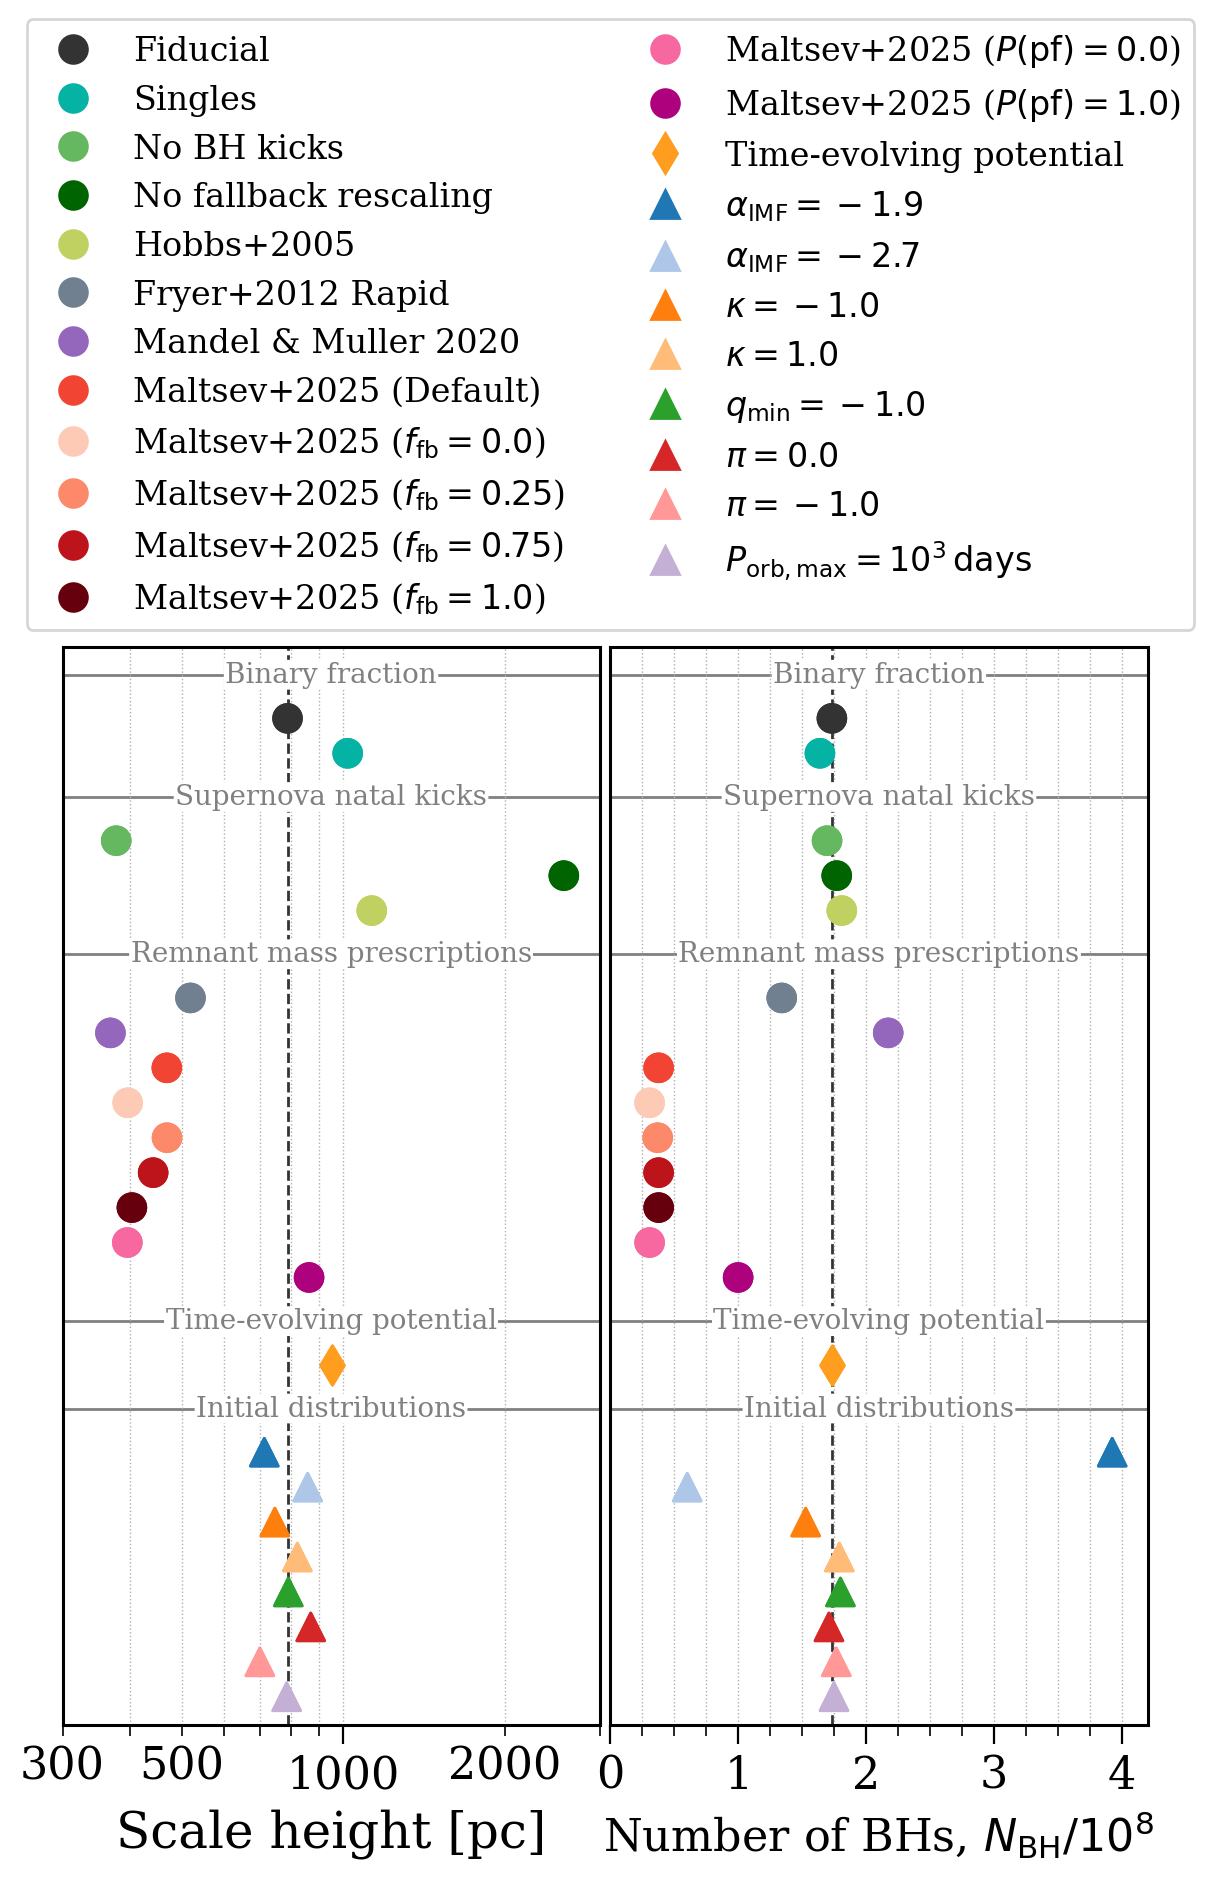

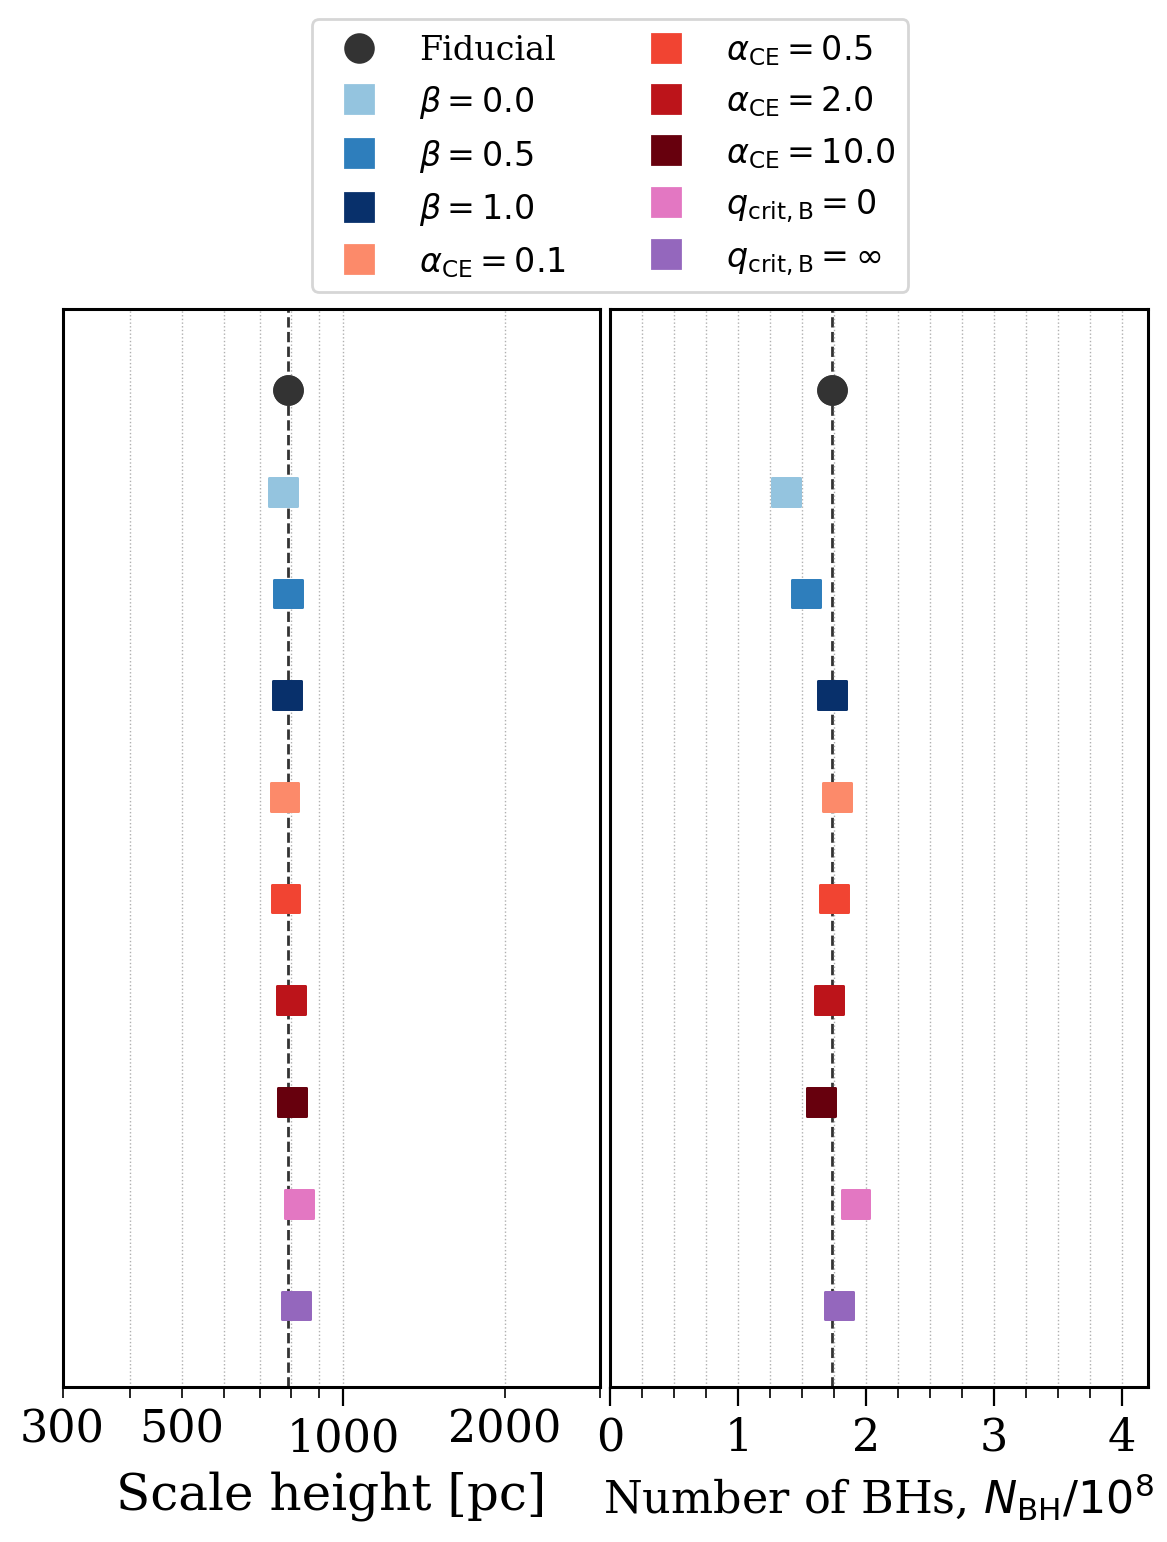

In [19]:
for label_set, groups_to_show, save_file in zip([main_labels, mt_labels], [groups[:-1], []], ["bh_summary_stats", "bh_summary_stats_mt"]):
    fig, axes = plt.subplots(1, 2, figsize=(7, 7), sharey=True)

    fig.subplots_adjust(wspace=0.02)

    summary_plot(label_set, col="$h_z$ (pc)", fig=fig, ax=axes[0], show=False, legend_kwargs=None, groups_to_show=groups_to_show)
    summary_plot(label_set, col="$N_{\\rm BH} / 10^8$", fig=fig, ax=axes[1], show=False, legend_kwargs={"loc":"lower center", "fontsize":12, "ncol":2, "bbox_to_anchor":(0.0, 1.0)}, ax_kwargs={"xscale": 'linear'}, groups_to_show=groups_to_show)

    label_these = [300, 500, 1000, 2000]
    formatter = mticker.FuncFormatter(lambda x, pos: f'{int(x)}' if x in label_these else '')
    axes[0].xaxis.set_minor_formatter(formatter)
    axes[0].xaxis.set_major_formatter(formatter)

    axes[0].set_xlabel("Scale height [pc]", fontsize=18)

    axes[1].set_xlabel(r"Number of BHs, $N_{\rm BH} / 10^8$", fontsize=16)
    axes[1].xaxis.set_major_locator(plt.MultipleLocator(1))
    axes[1].xaxis.set_minor_locator(plt.MultipleLocator(.25))

    axes[0].set_xlim(300, 3000)
    axes[1].set_xlim(0, 4.2)

    plt.savefig(f"../plots/{save_file}.pdf", format='pdf', bbox_inches='tight')

    plt.show()

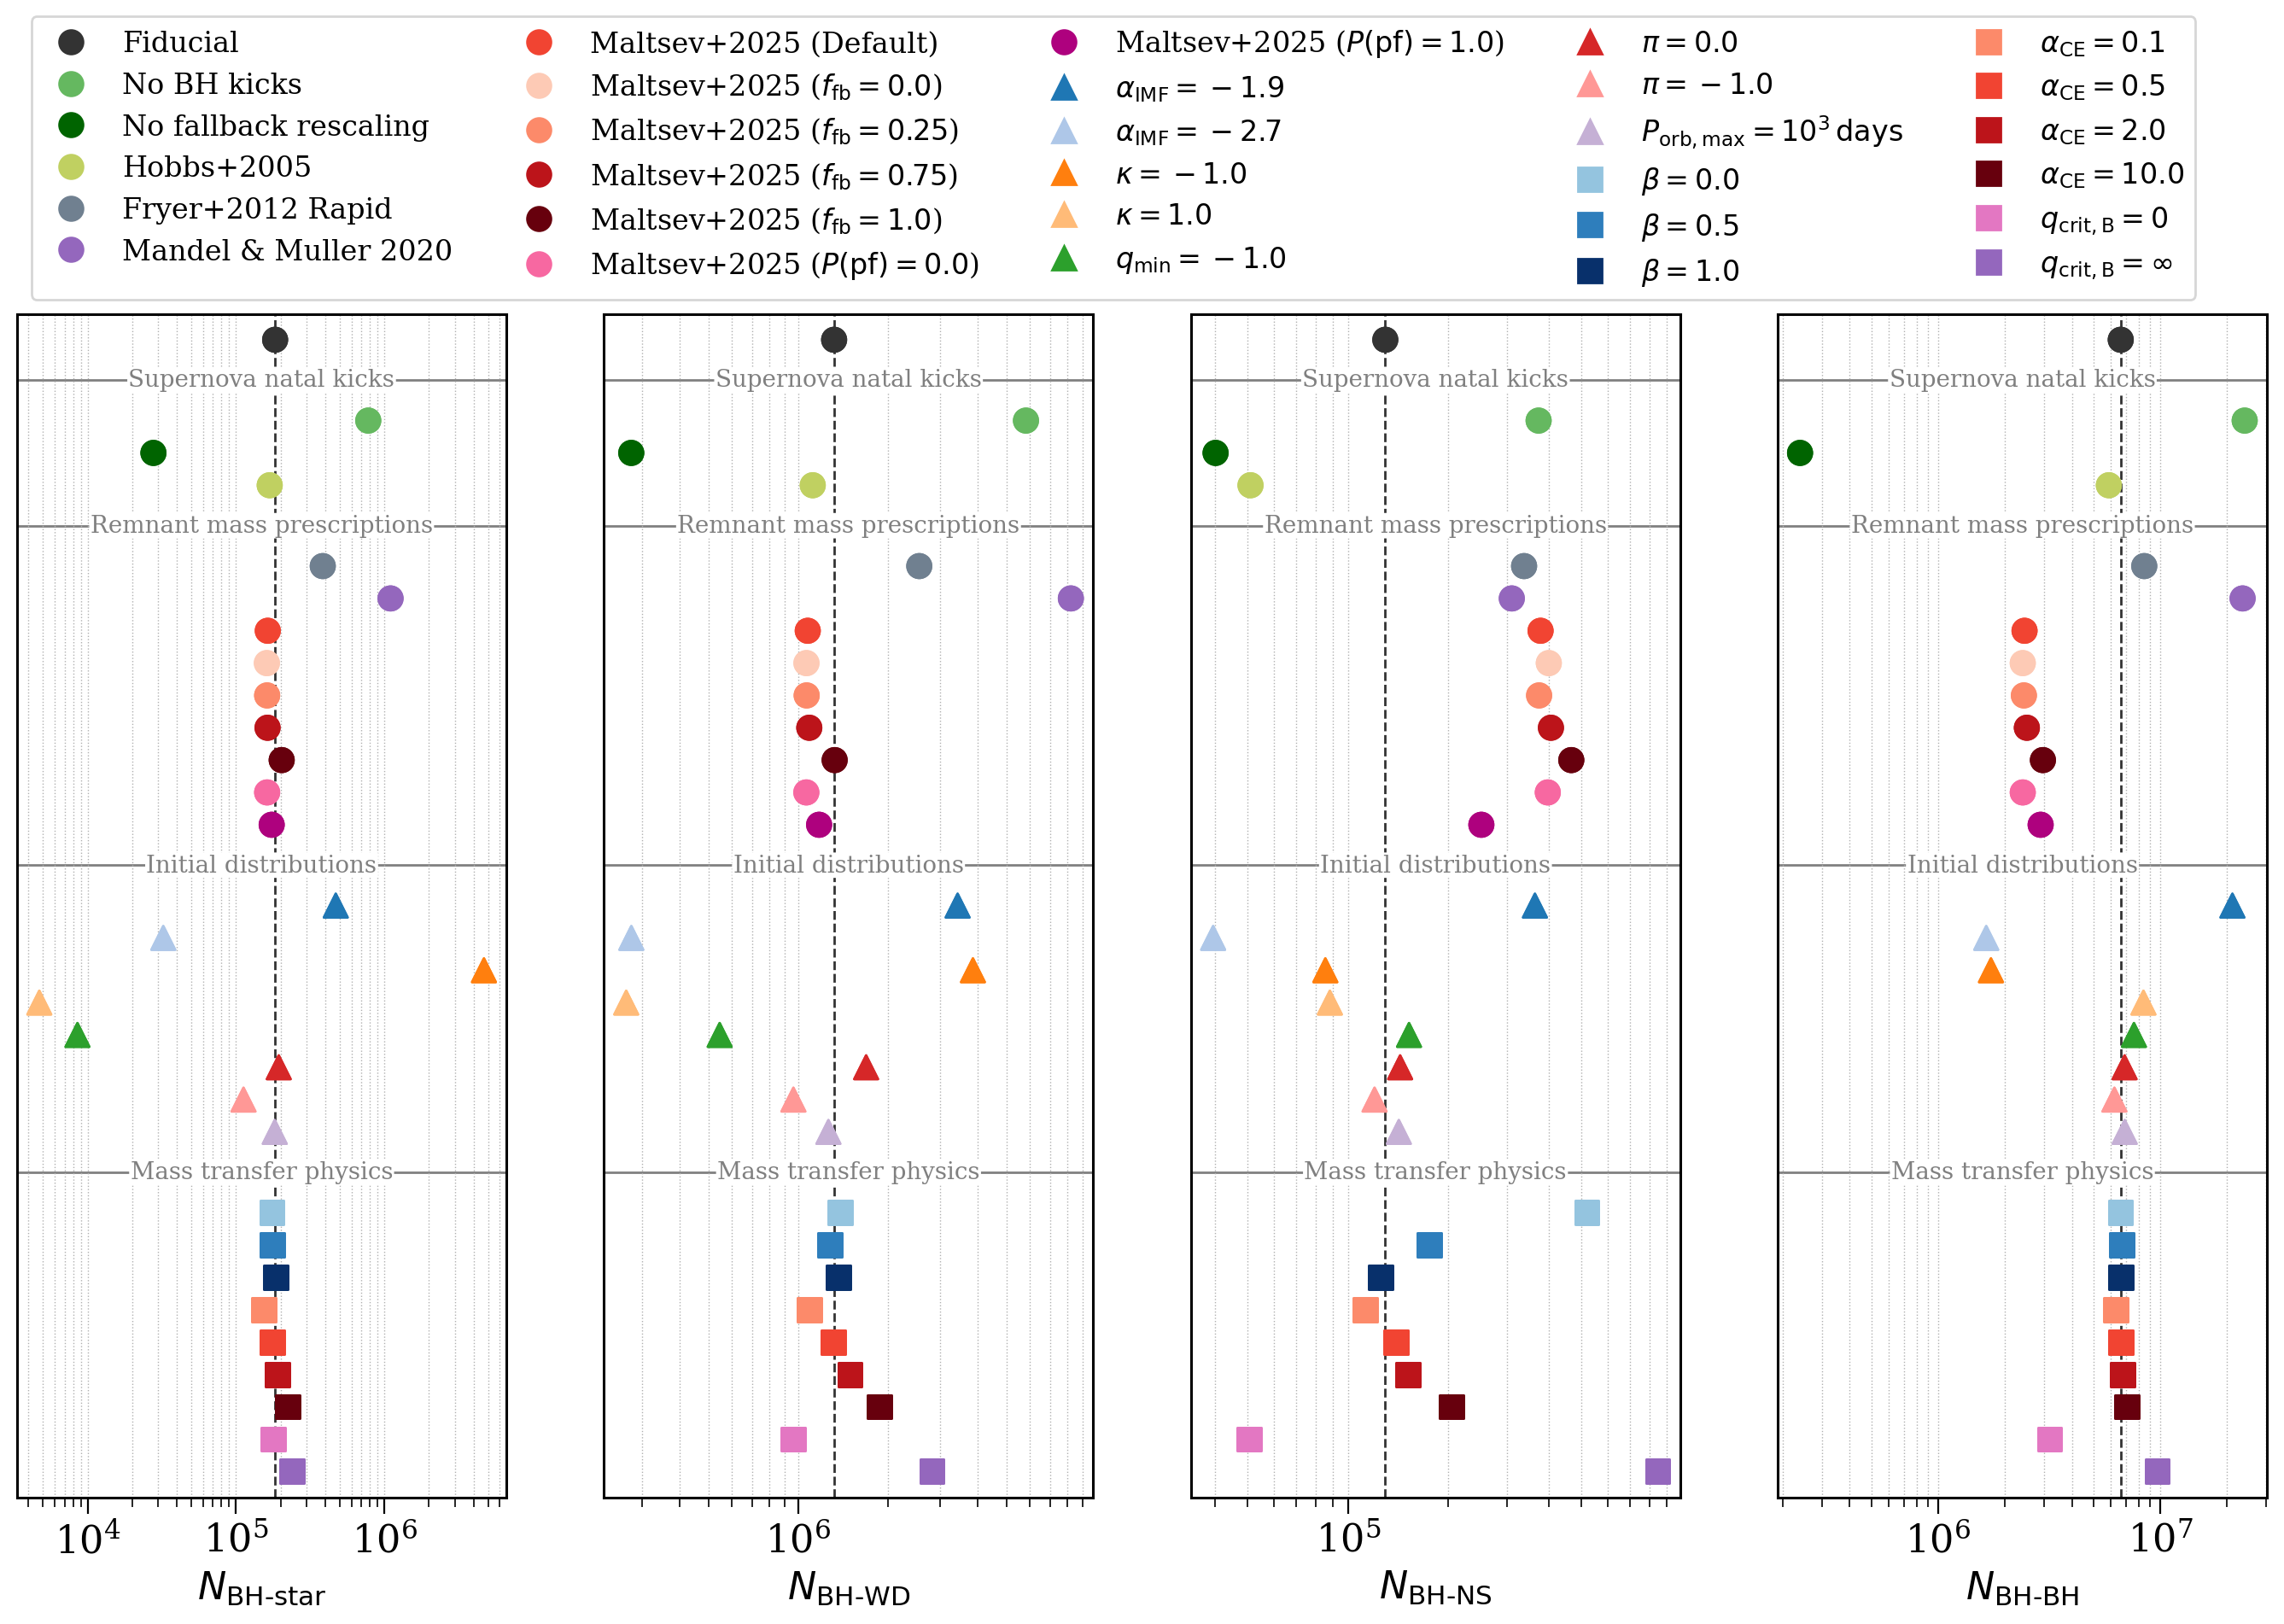

In [20]:
reload(constants)

fig, axes = plt.subplots(1, 4, figsize=(17, 9), sharey=True)

# main labels without the 2nd entry
main_labels_no_singles = [label for label in main_labels if (label != r"$f_{\rm bin} = 0.0$" and label != "Time-evolving potential")]
main_labels_no_singles += [label for label in mt_labels if label != r"$f_{\rm bin} = 1.0$"]
labels_inds = np.array([labels.index(label) for label in main_labels_no_singles])

for col, ax, norm in zip(
    [r"$N_{\rm BH\text{-}star} / 10^4$", r"$N_{\rm BH\text{-}WD} / 10^5$", r"$N_{\rm BH\text{-}NS} / 10^5$", r"$N_{\rm BH\text{-}BH} / 10^6$"],
    axes,
    [1e4, 1e5, 1e5, 1e6]
):

    summary_plot(main_labels_no_singles, col=col, fig=fig, ax=ax, show=False,
                 legend_kwargs={"loc":"lower left", "fontsize":12, "ncol":5, "bbox_to_anchor":(0.0, 1.0)} if ax == axes[0] else None,
                 norm=norm, groups_to_show=[g for g in groups if g["title"] != "Time-evolving potential" and g["title"] != "Binary fraction"])

    ax.set_xlabel(col.split("/")[0] + "$", fontsize=16)


plt.savefig("../plots/bh_summary_stats_bound.pdf", format='pdf', bbox_inches='tight')

plt.show()

$f_{\rm bin} = 1.0$ 1917


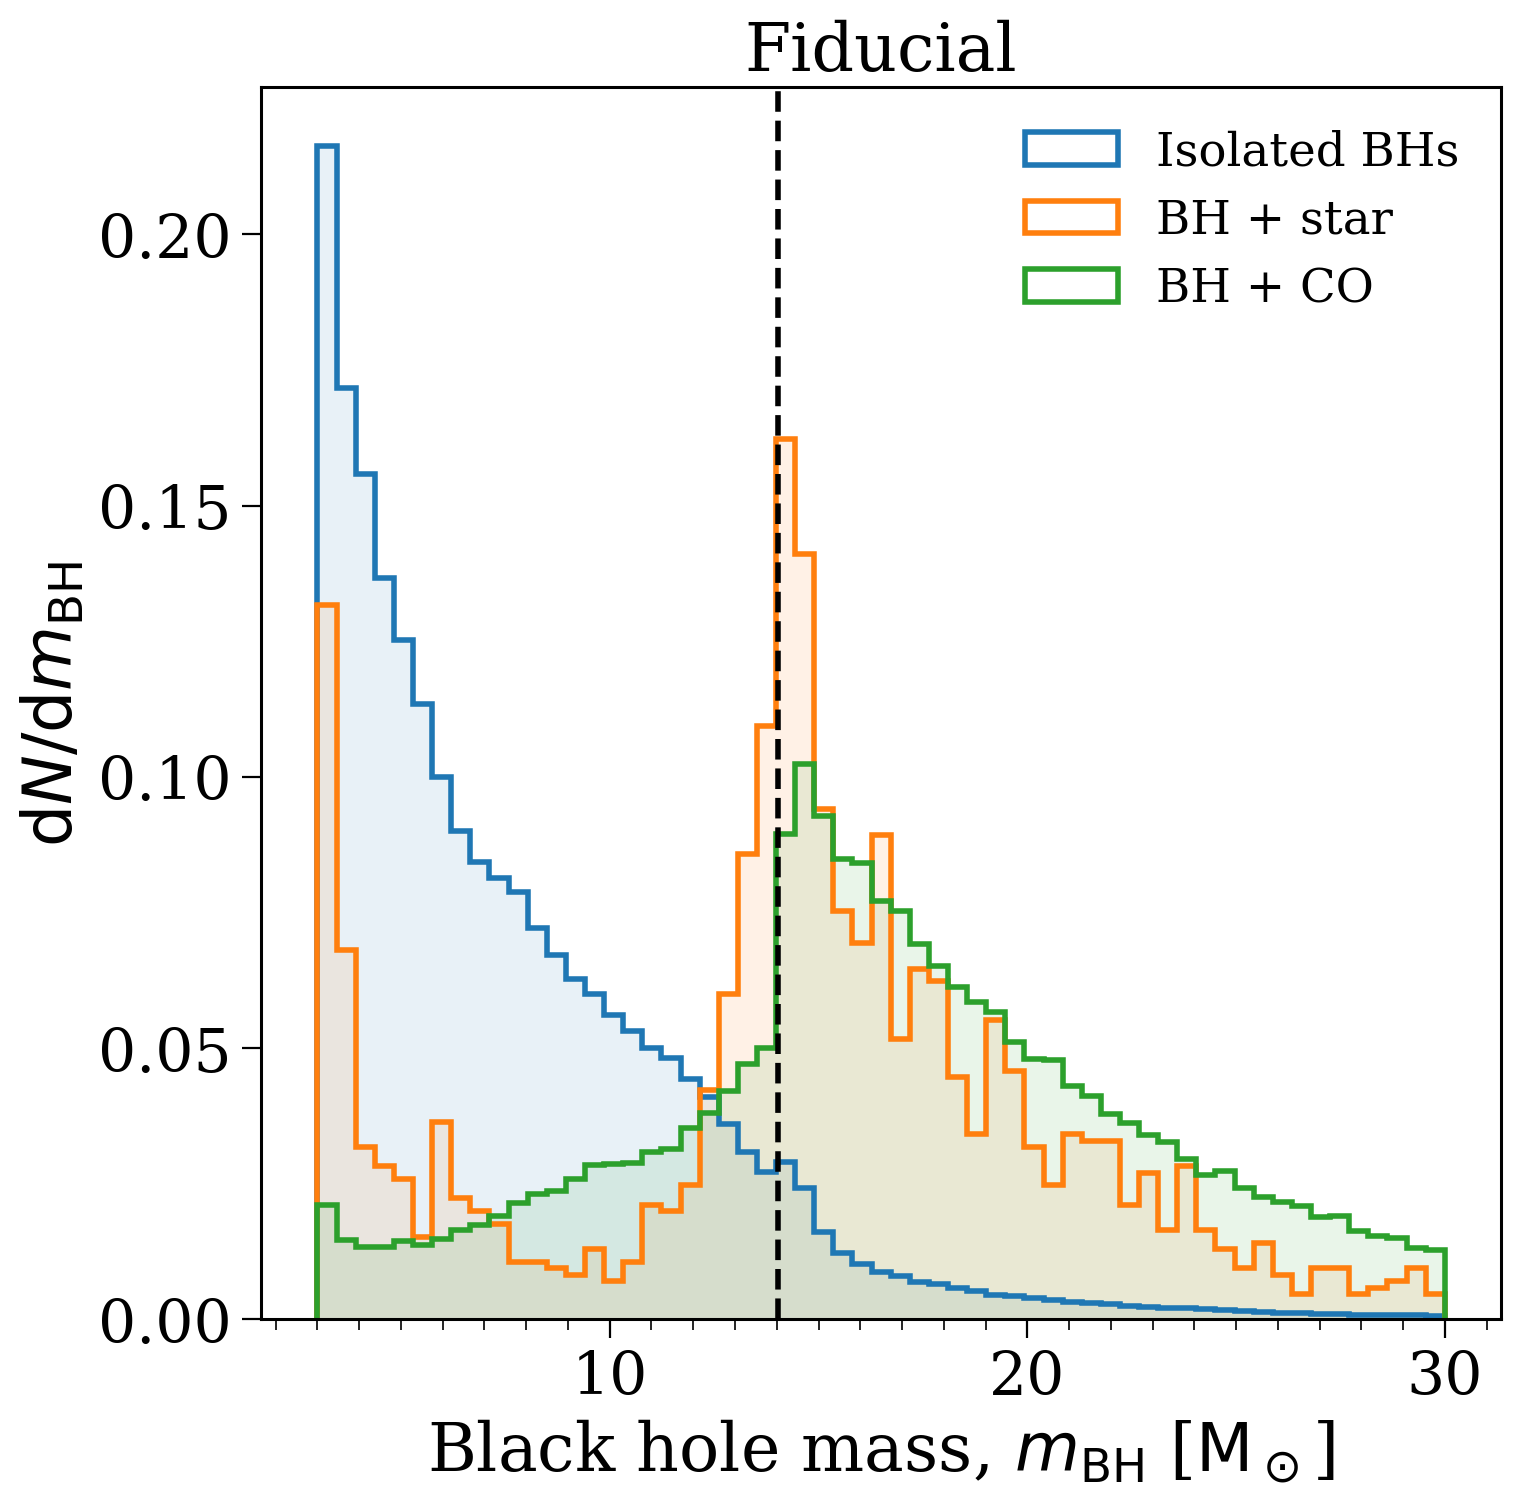

No BH kicks 8132


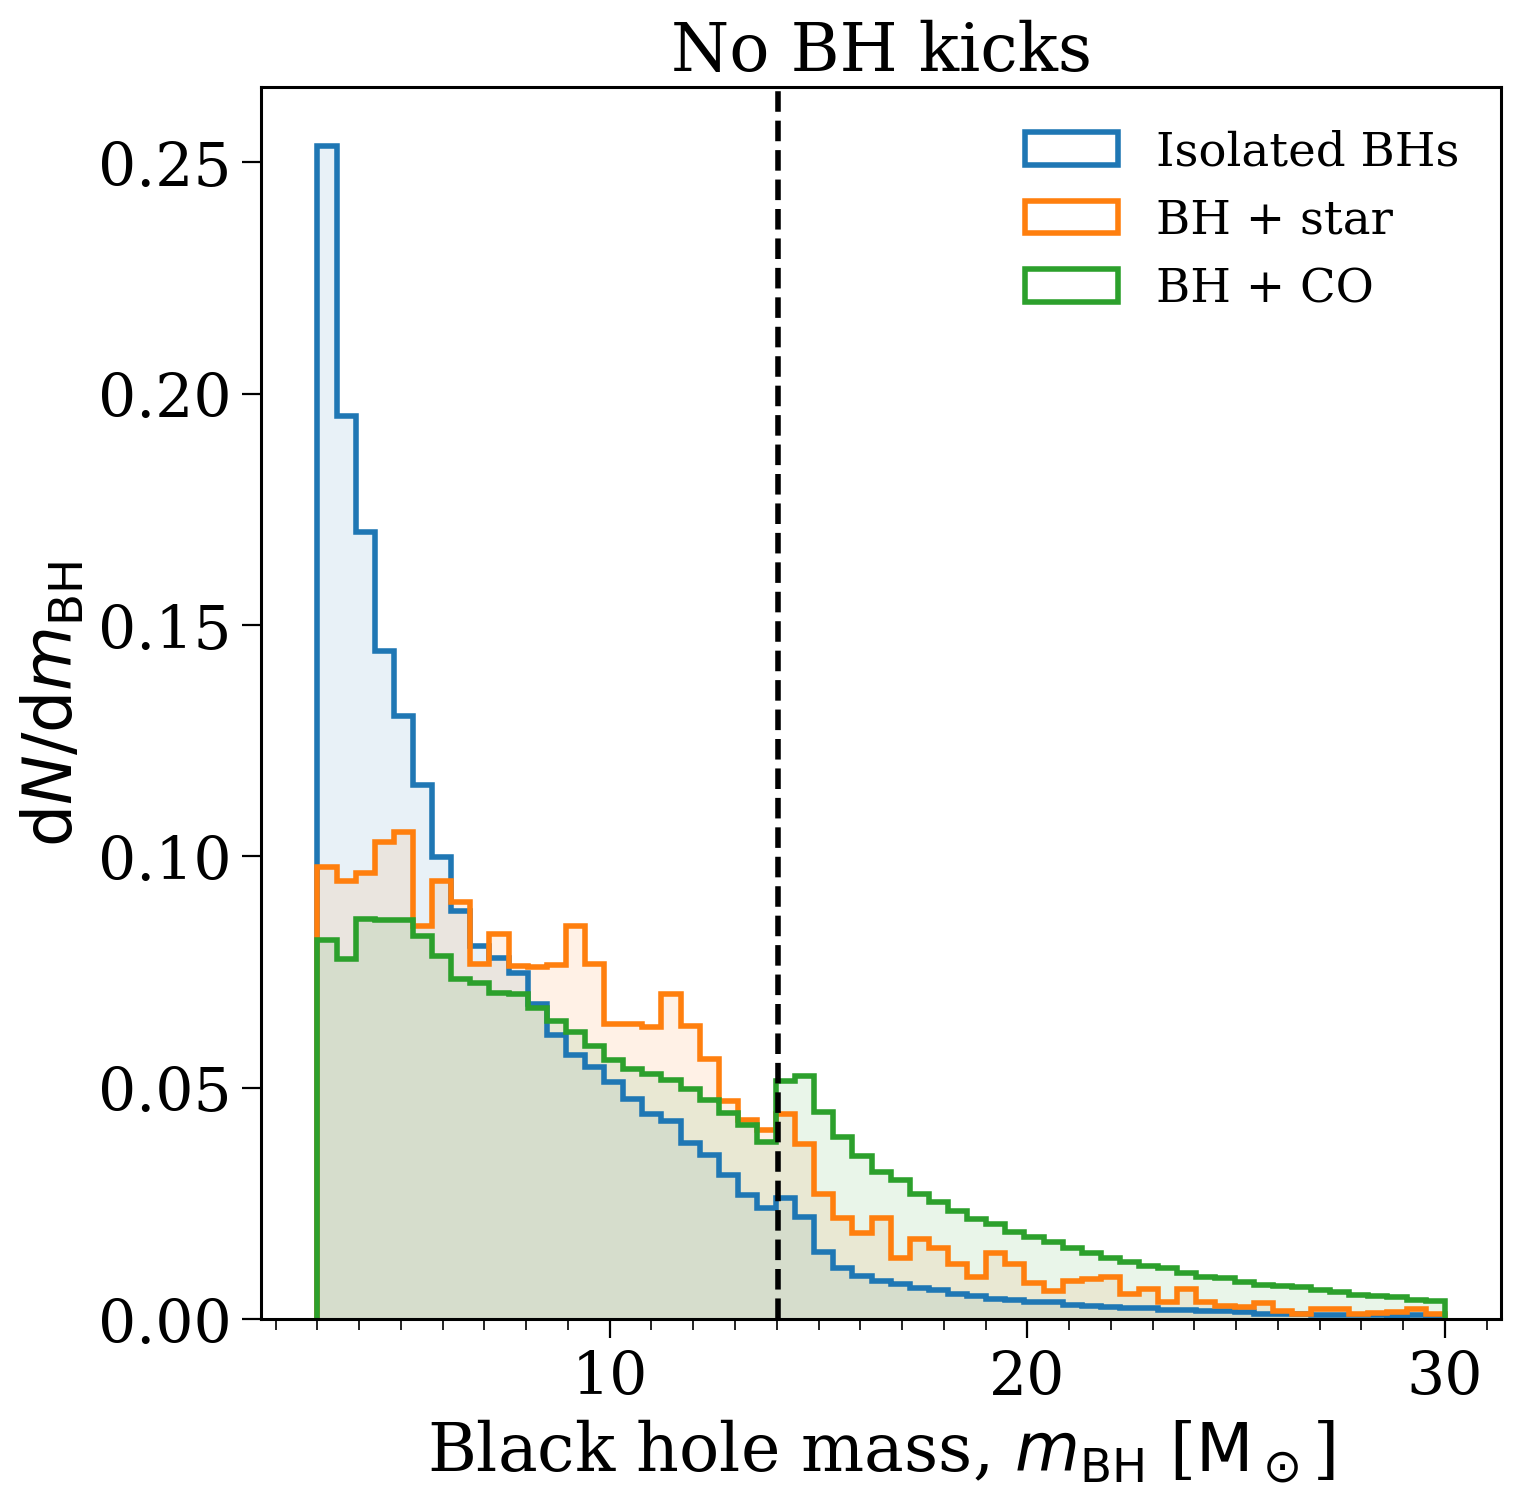

No fallback rescaling 290


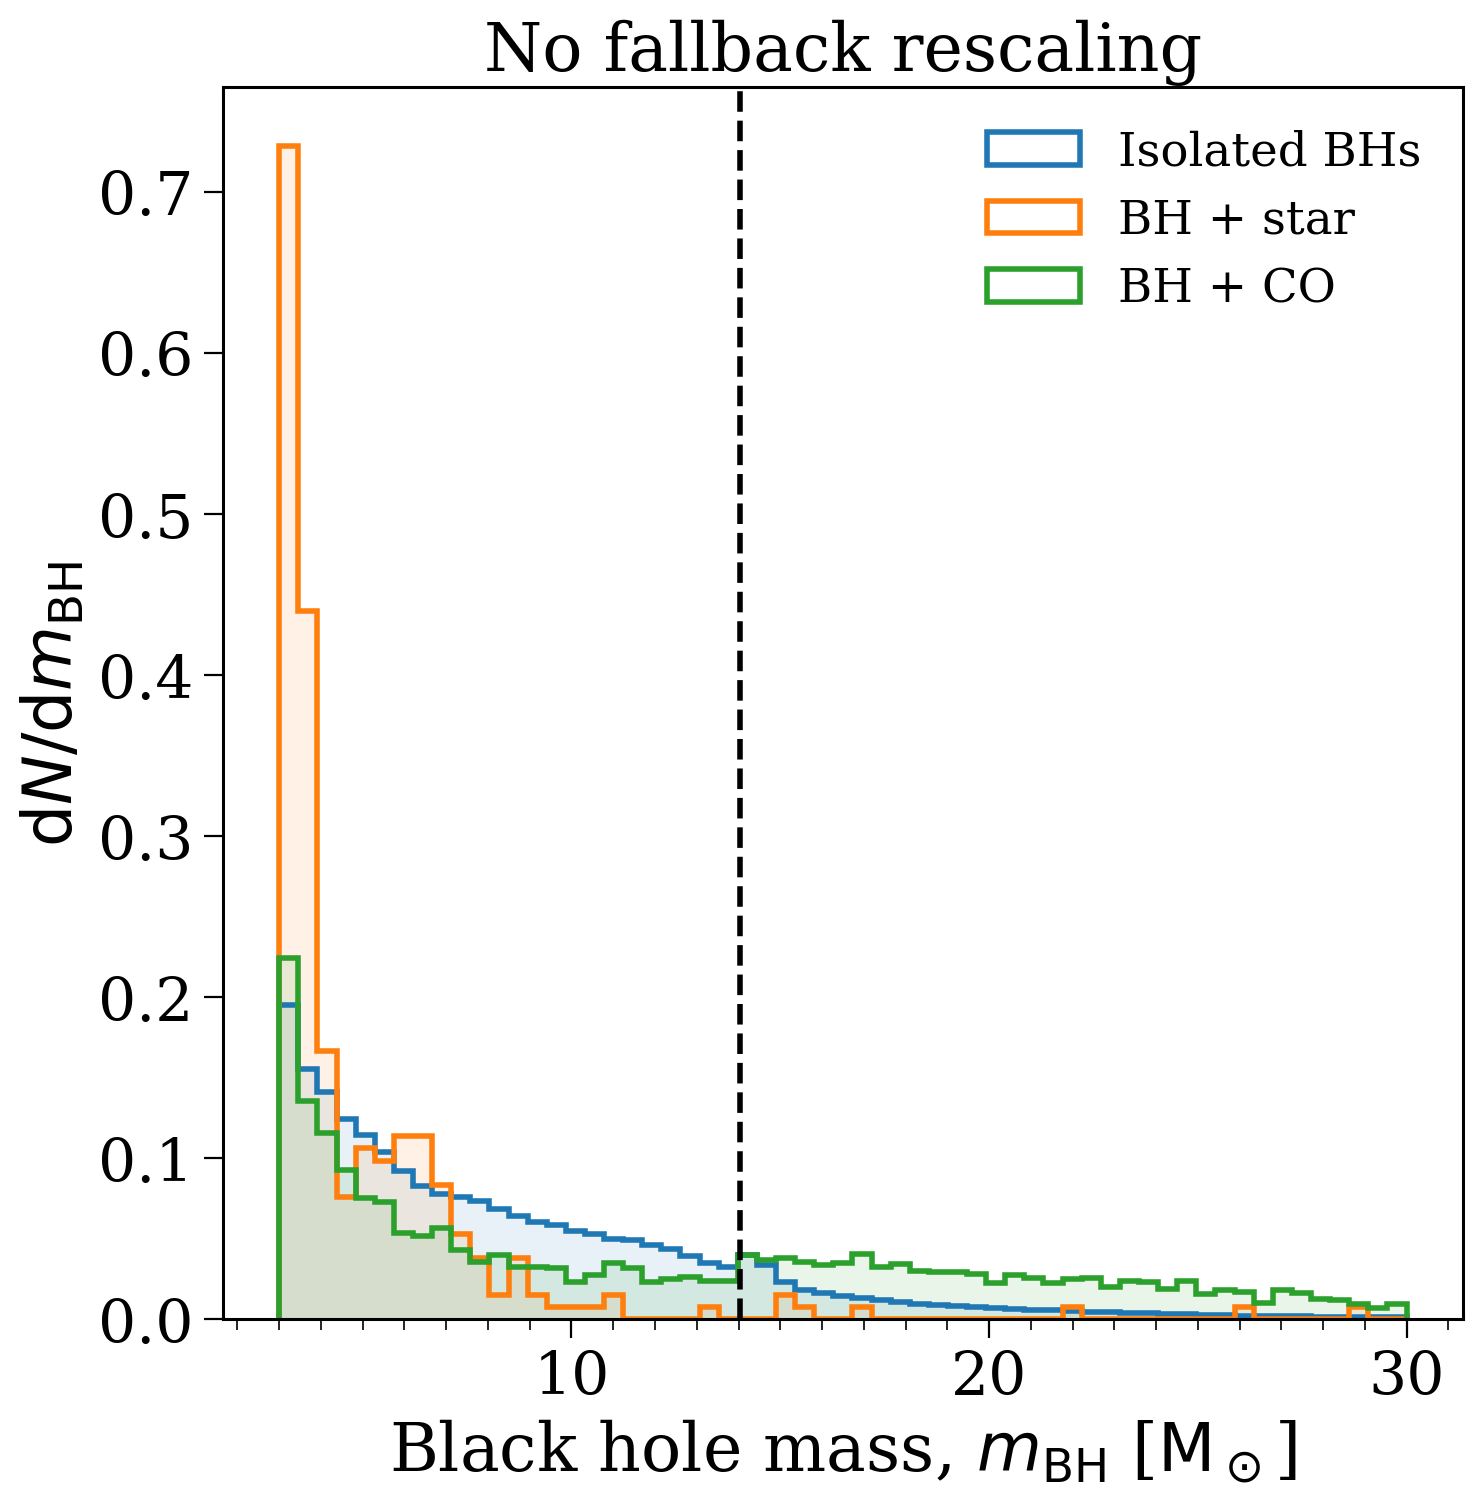

Hobbs+2005 1762


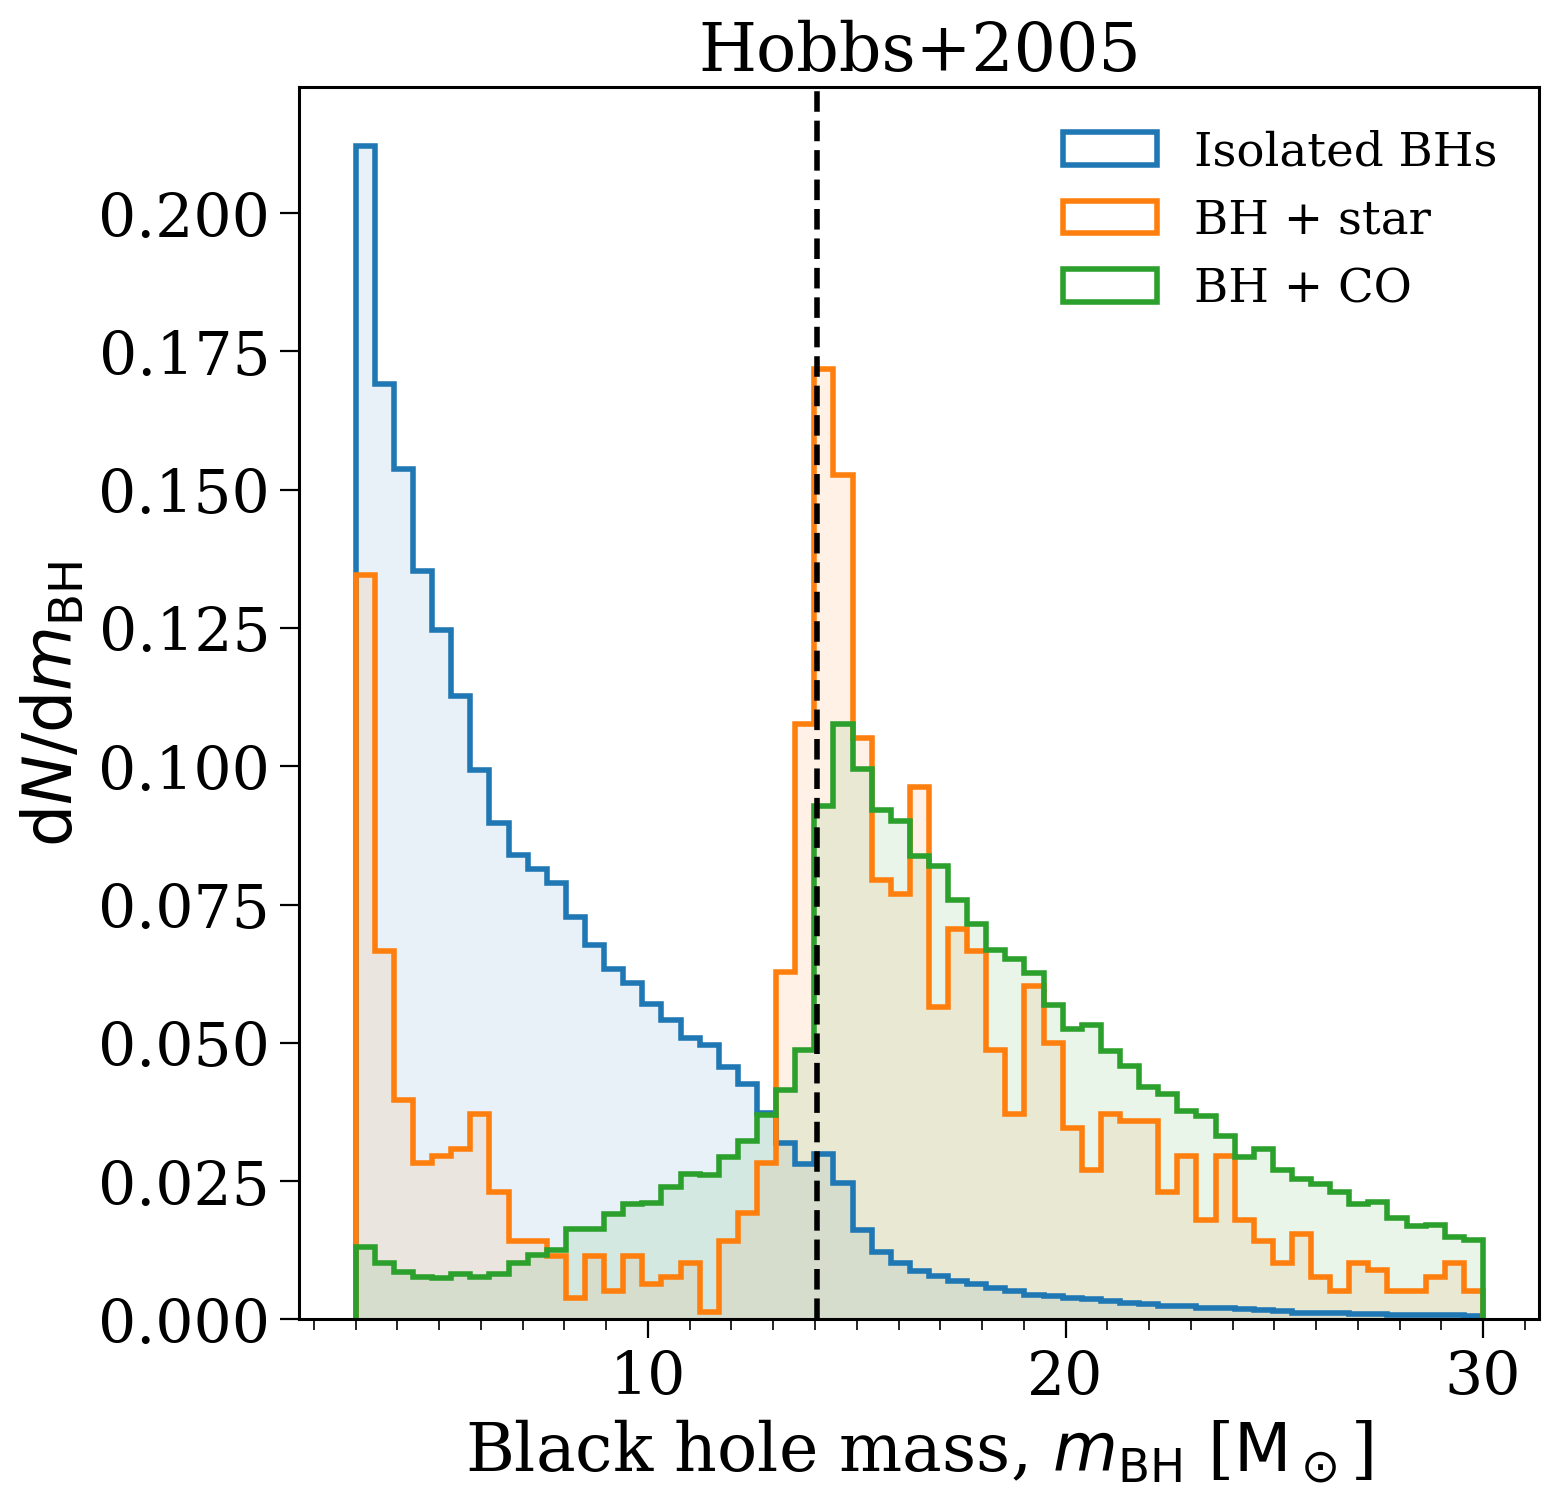

Fryer+2012 Rapid 4014


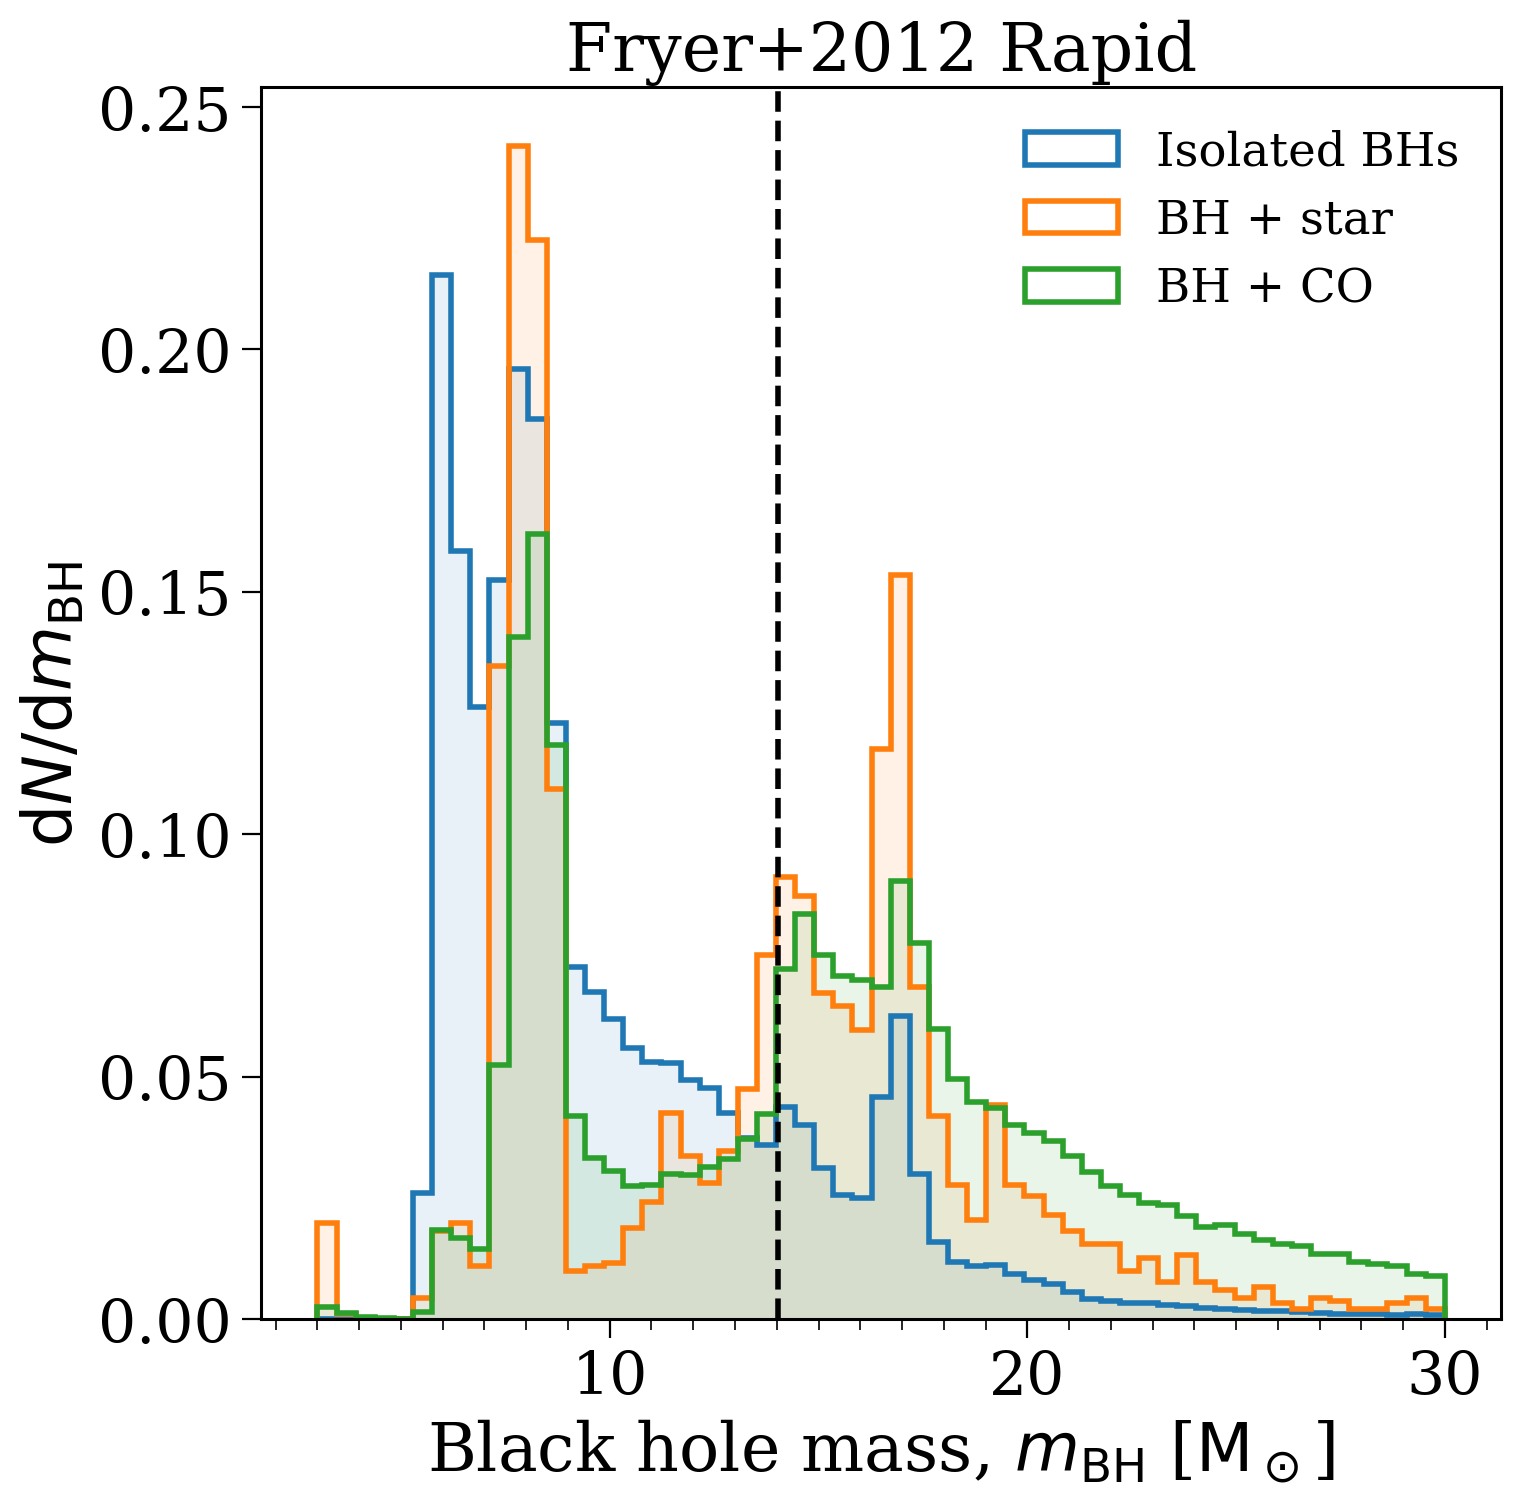

Mandel\&Muller2020 11493


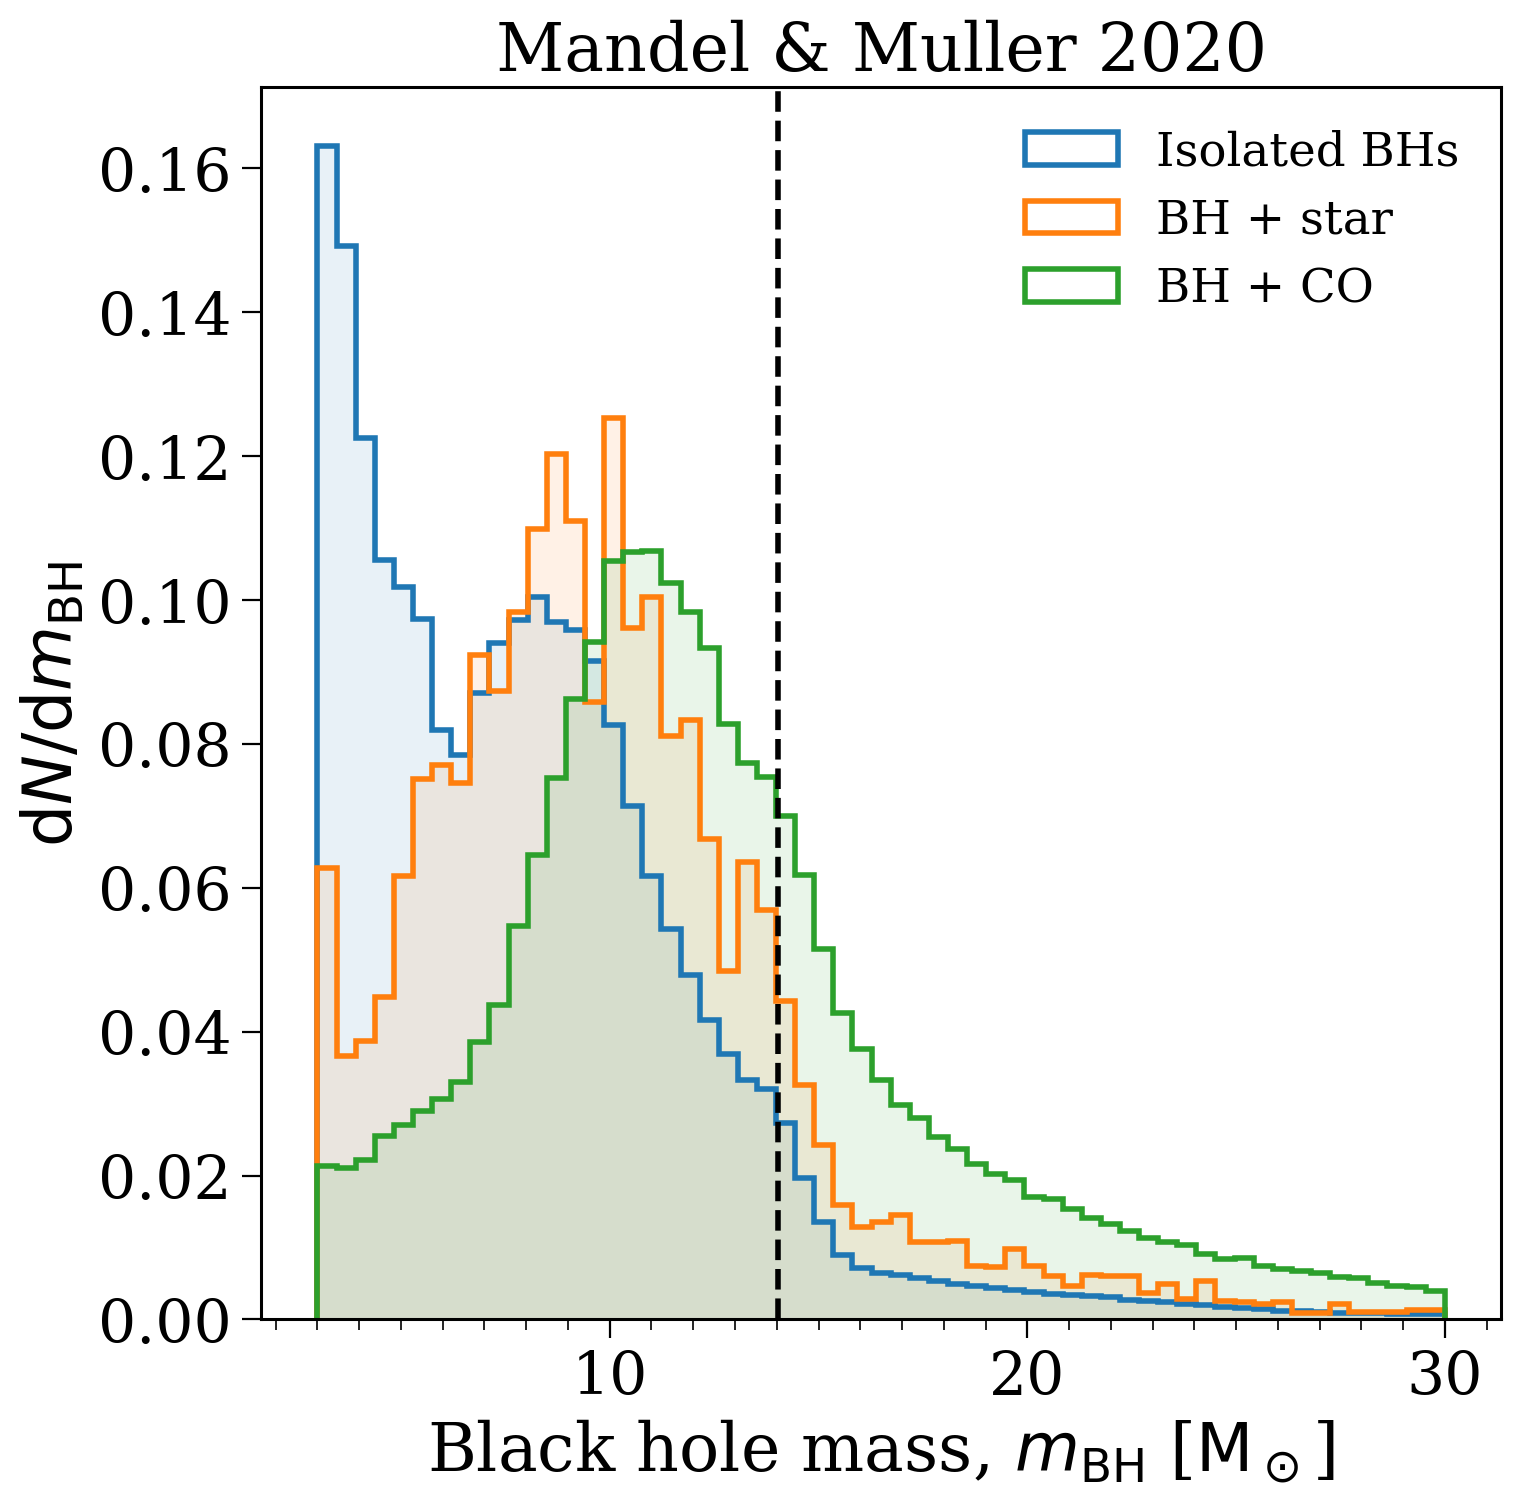

Maltsev+2025 1710


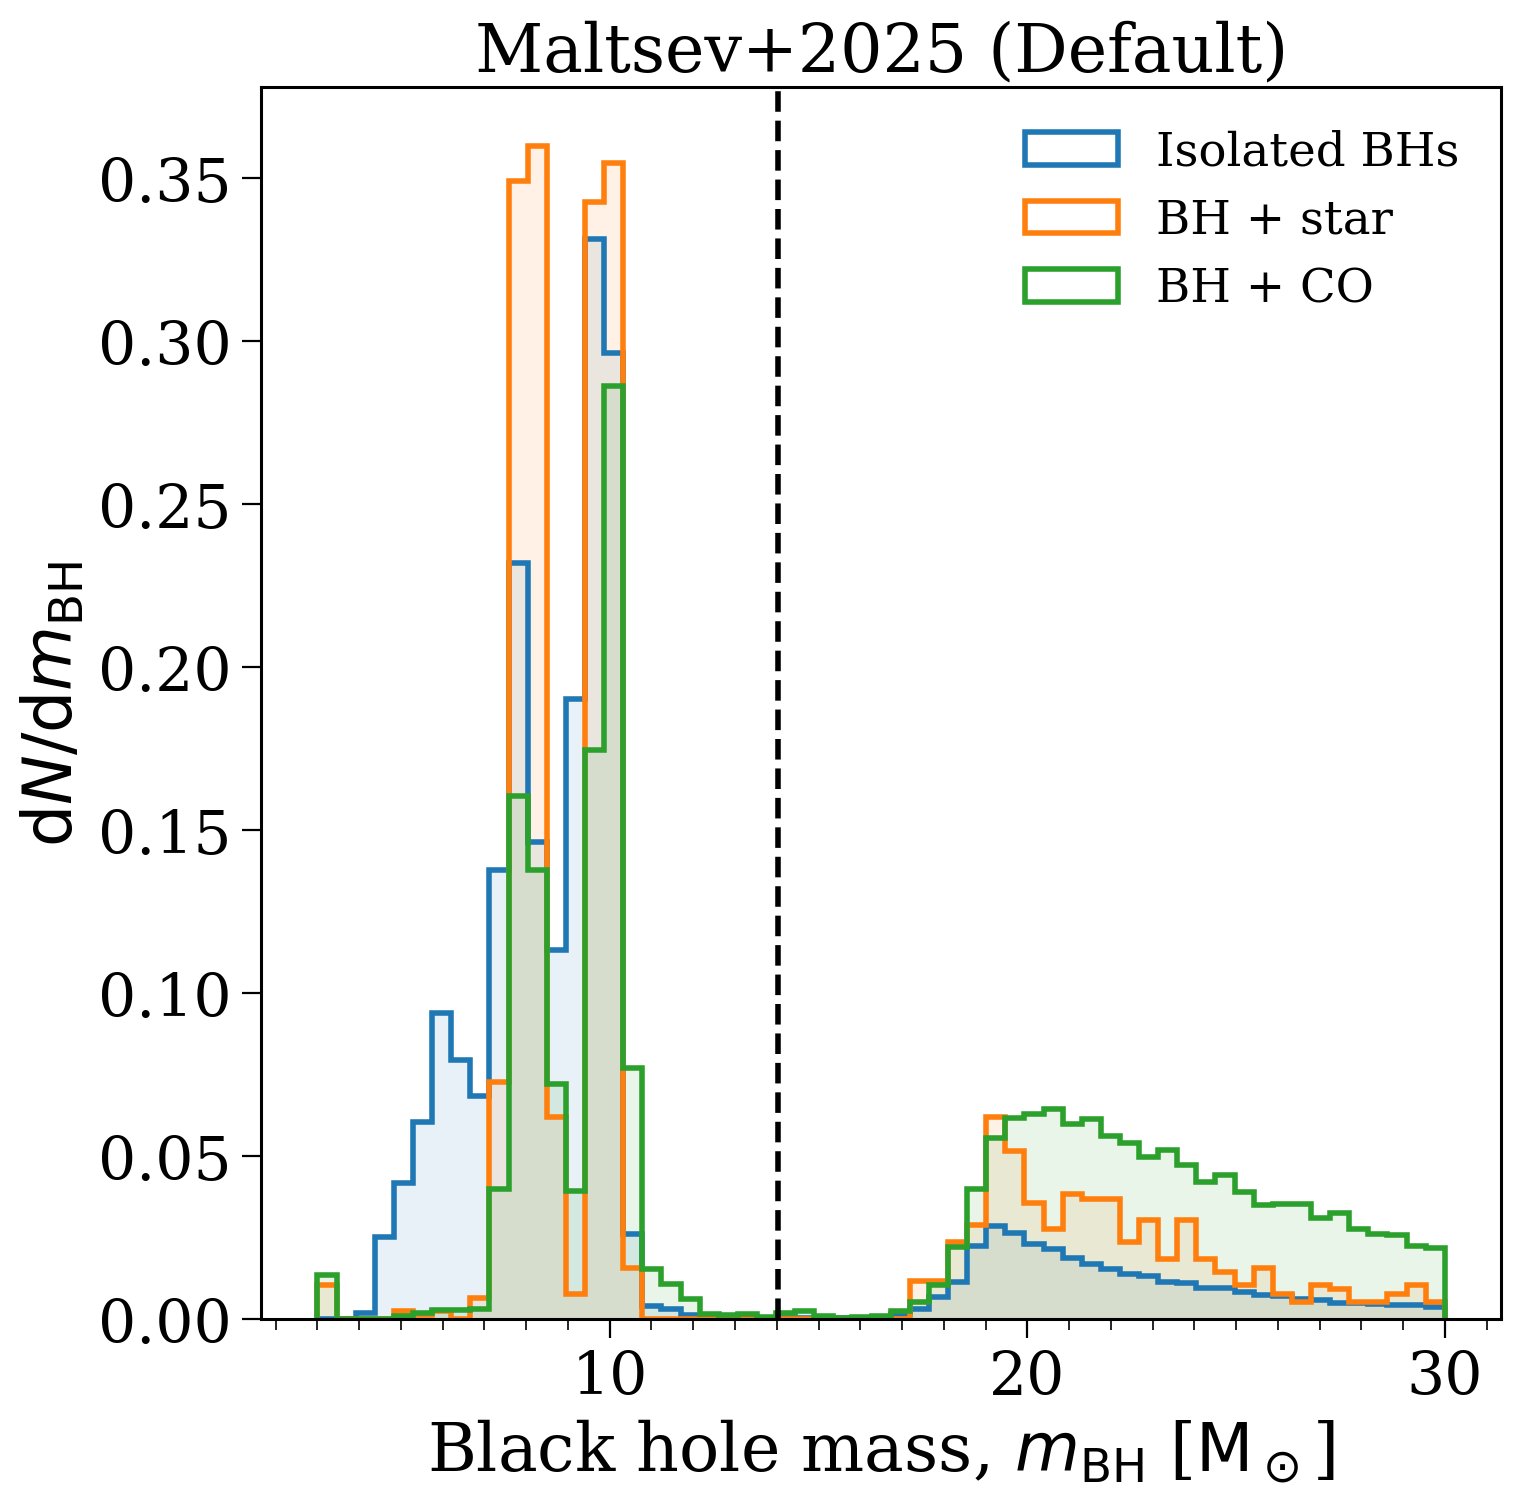

$f_{\rm fb} = 0.0$ 1686


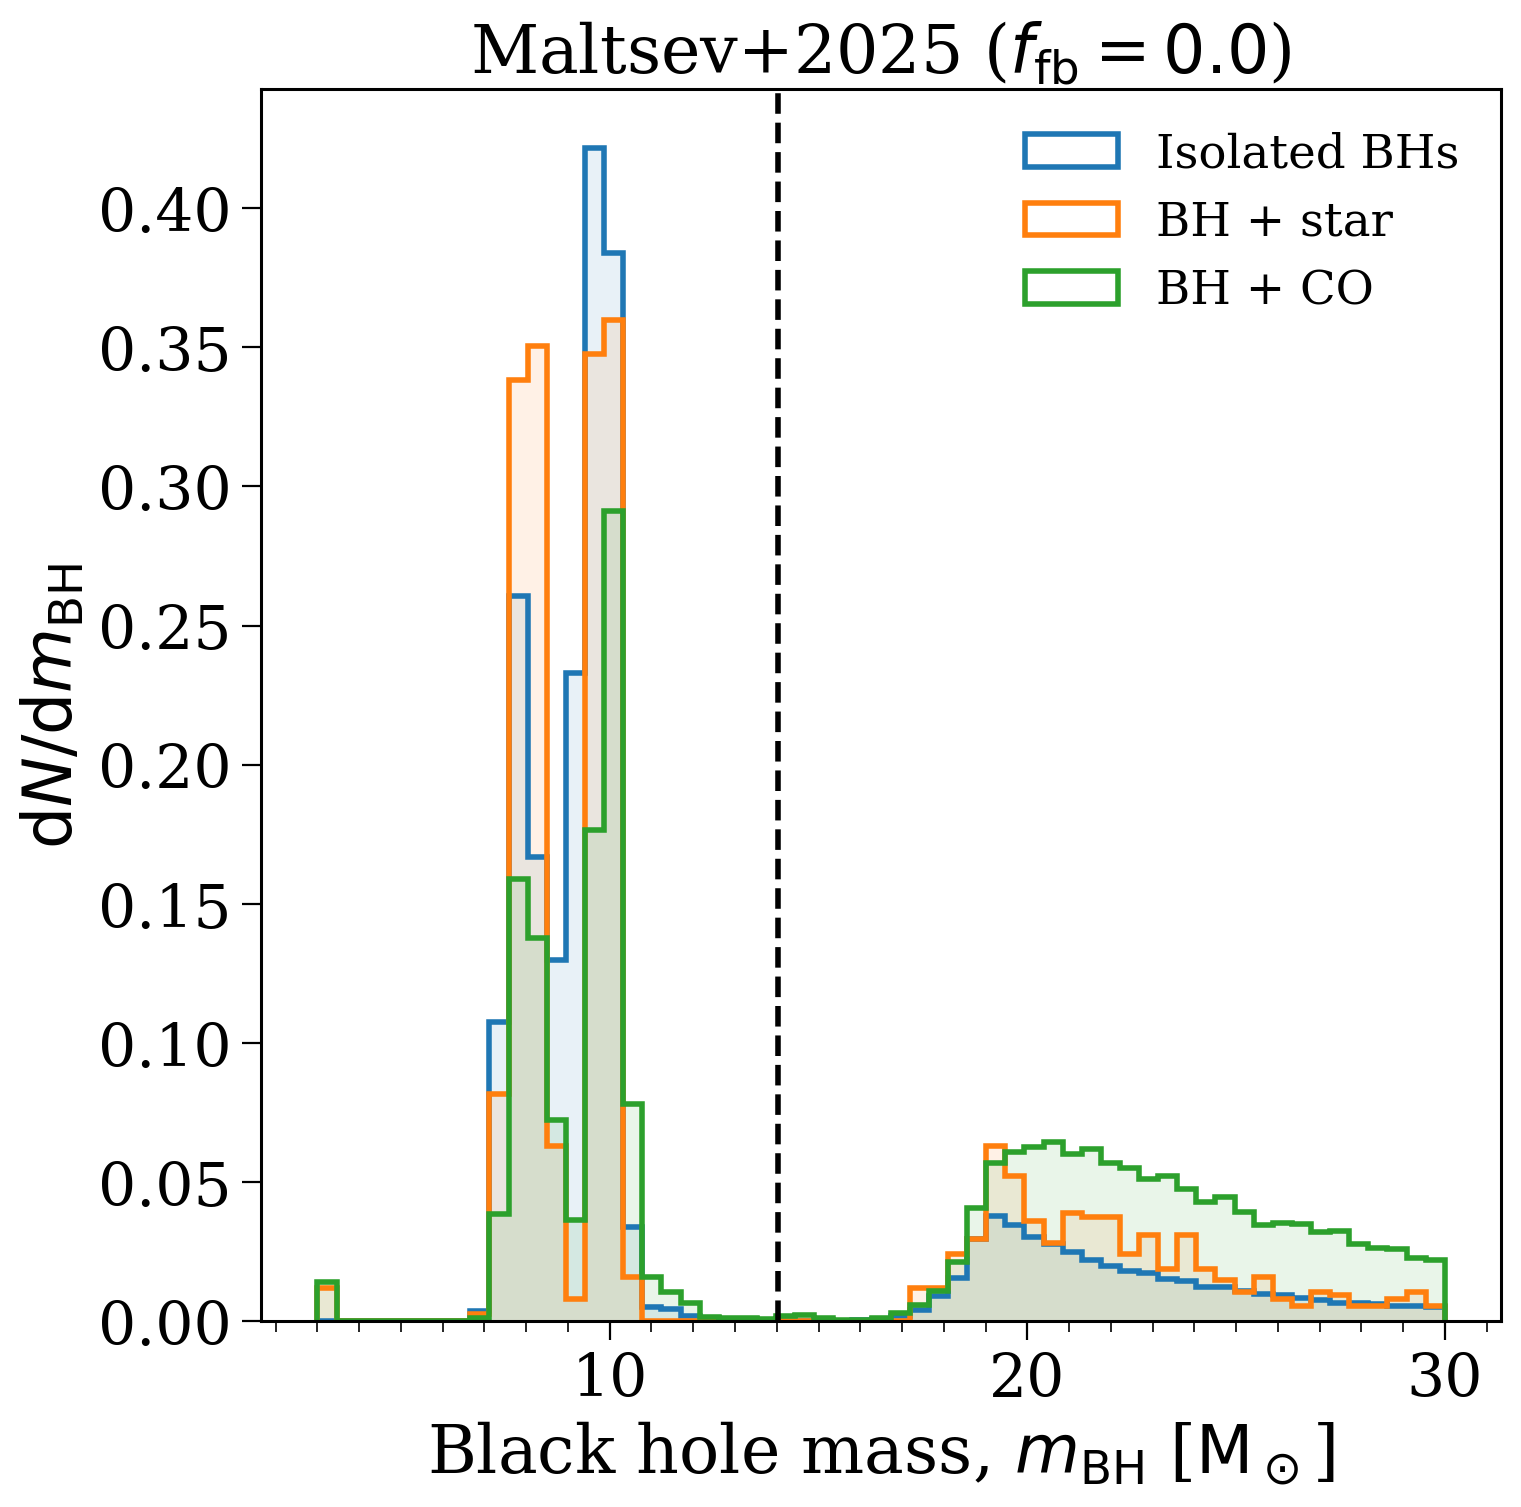

$f_{\rm fb} = 0.25$ 1693


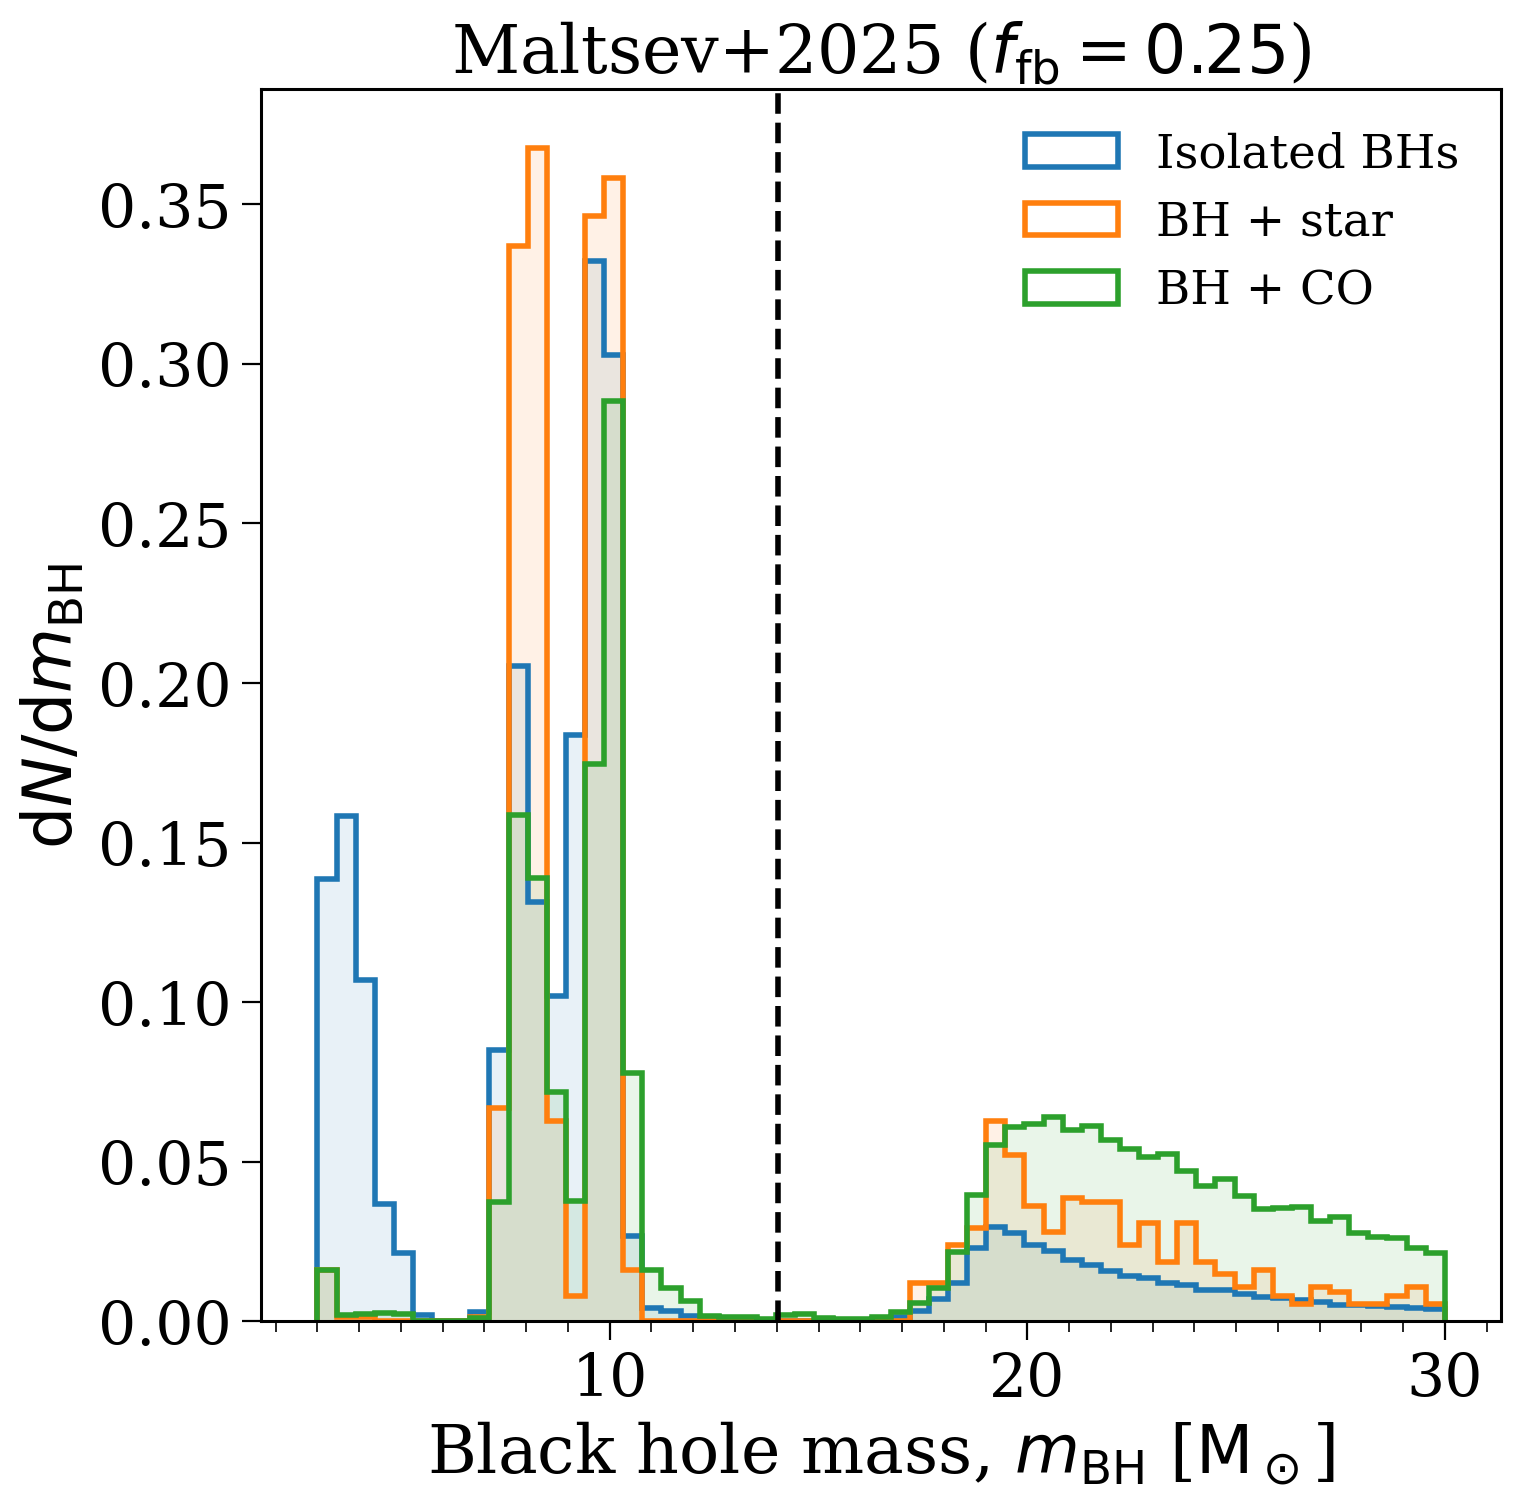

$f_{\rm fb} = 0.75$ 1704


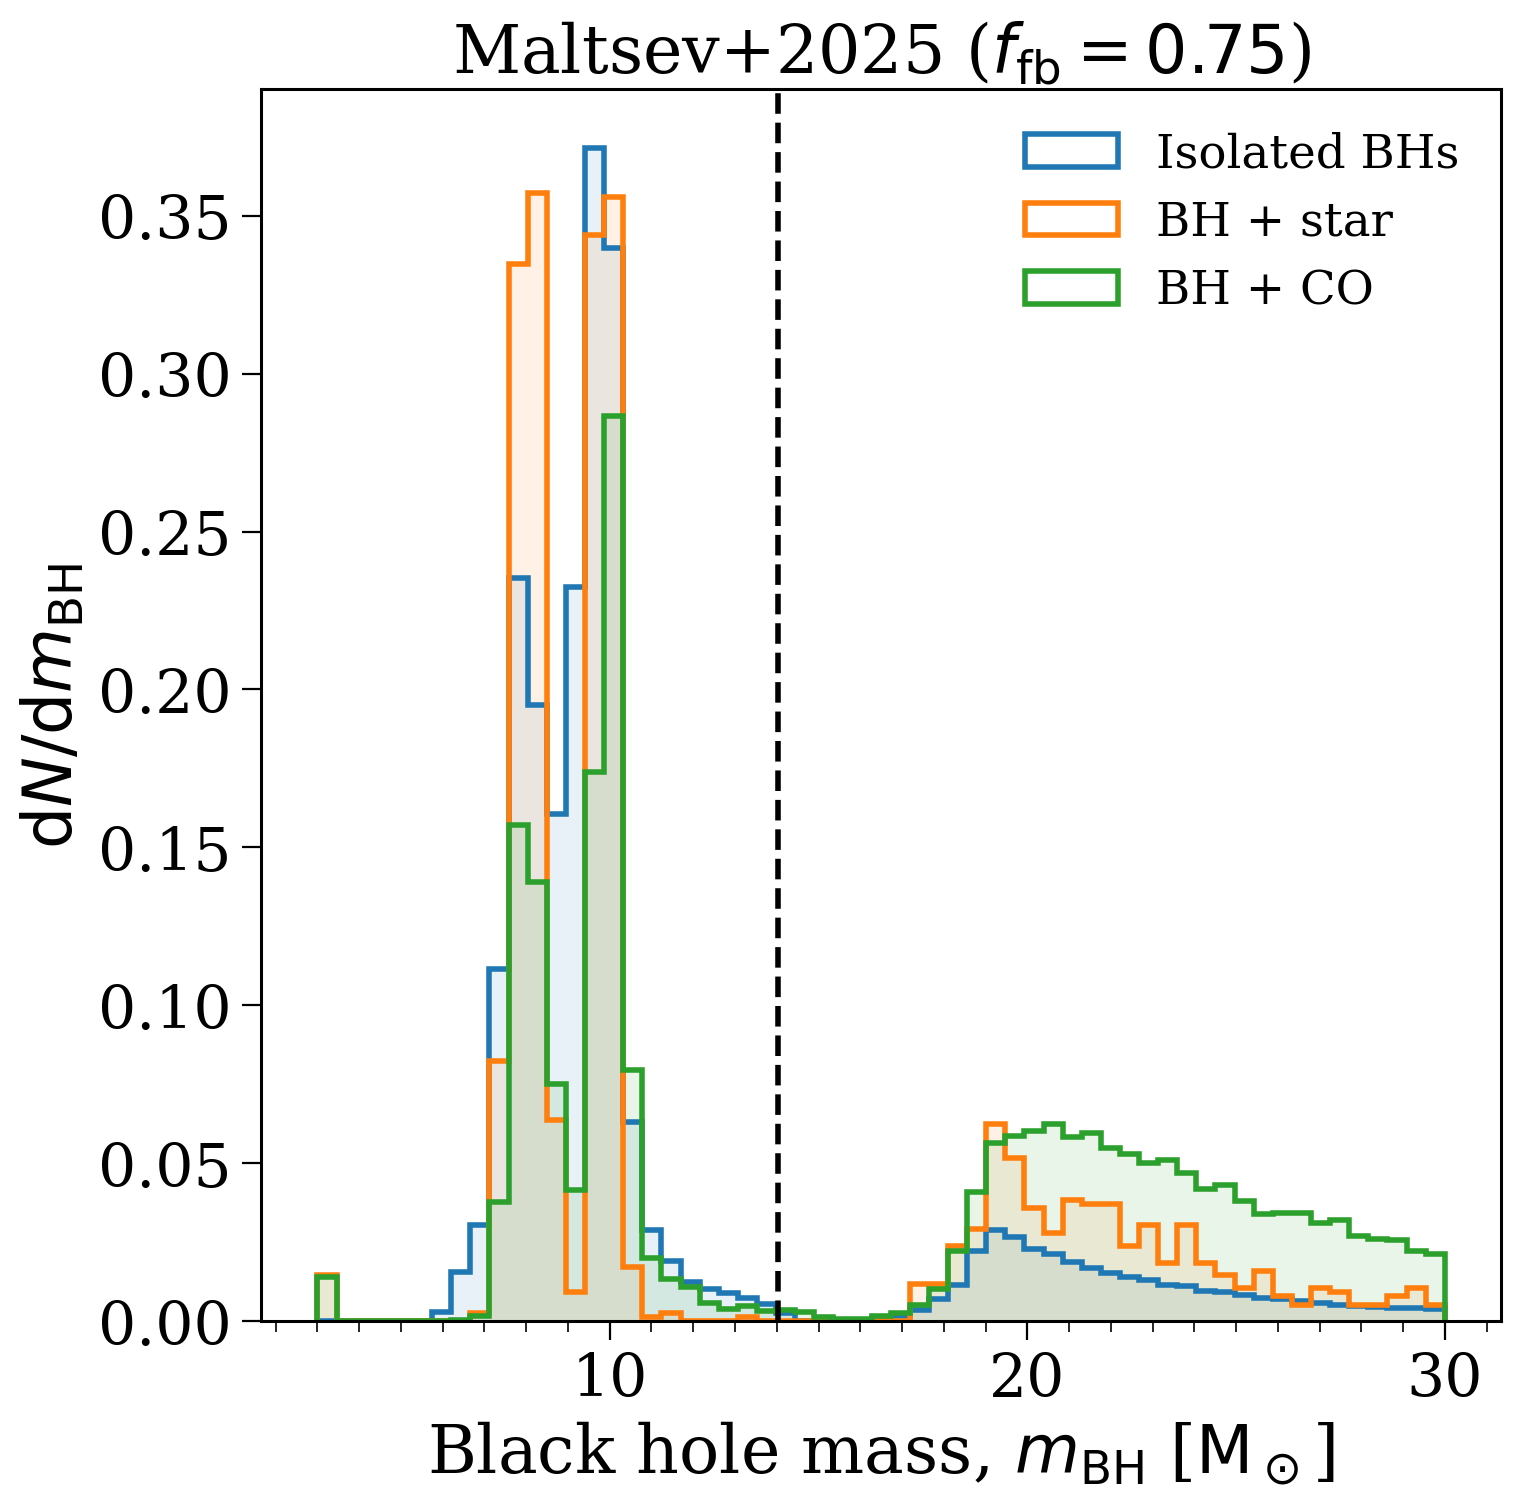

$f_{\rm fb} = 1.0$ 2122


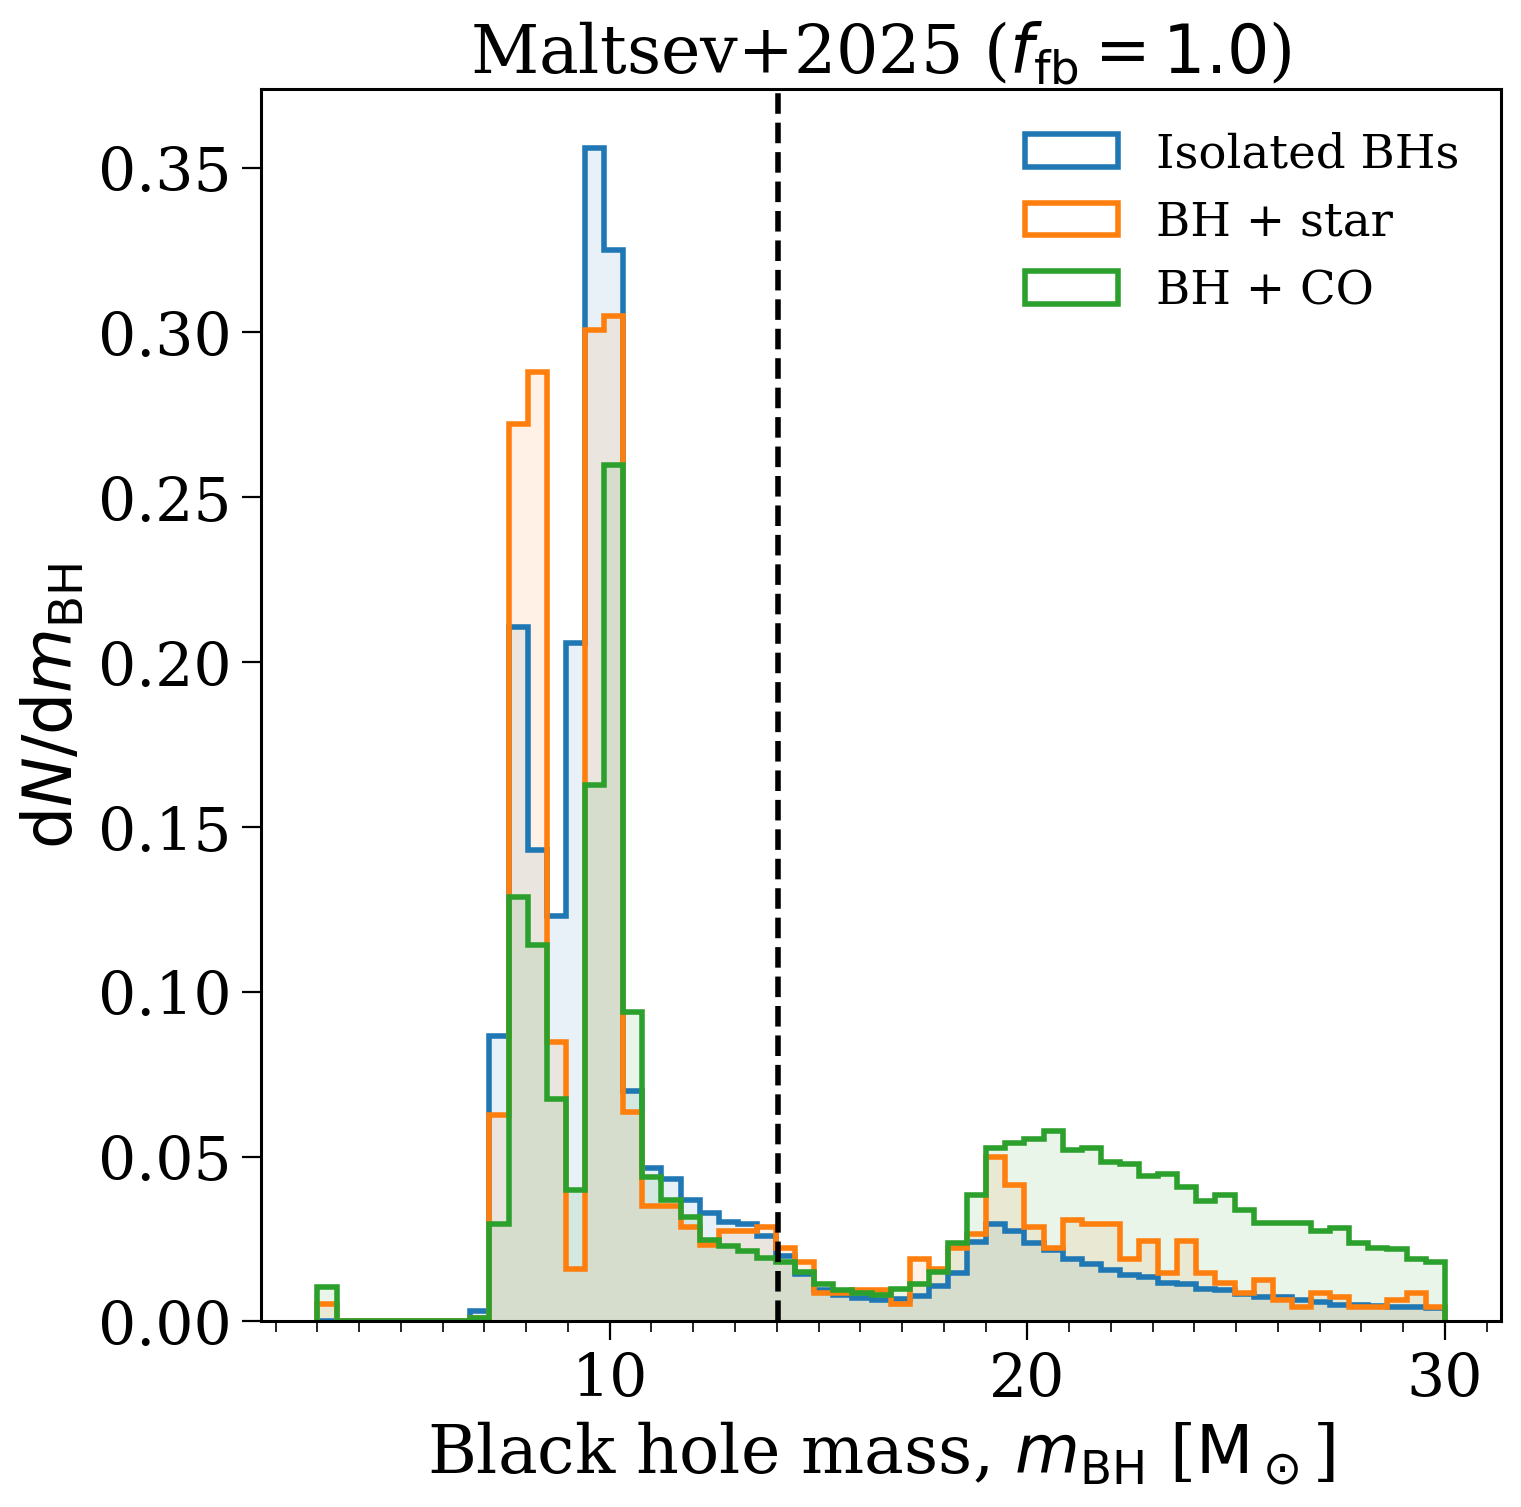

$P({\rm pf}) = 0.0$ 1693


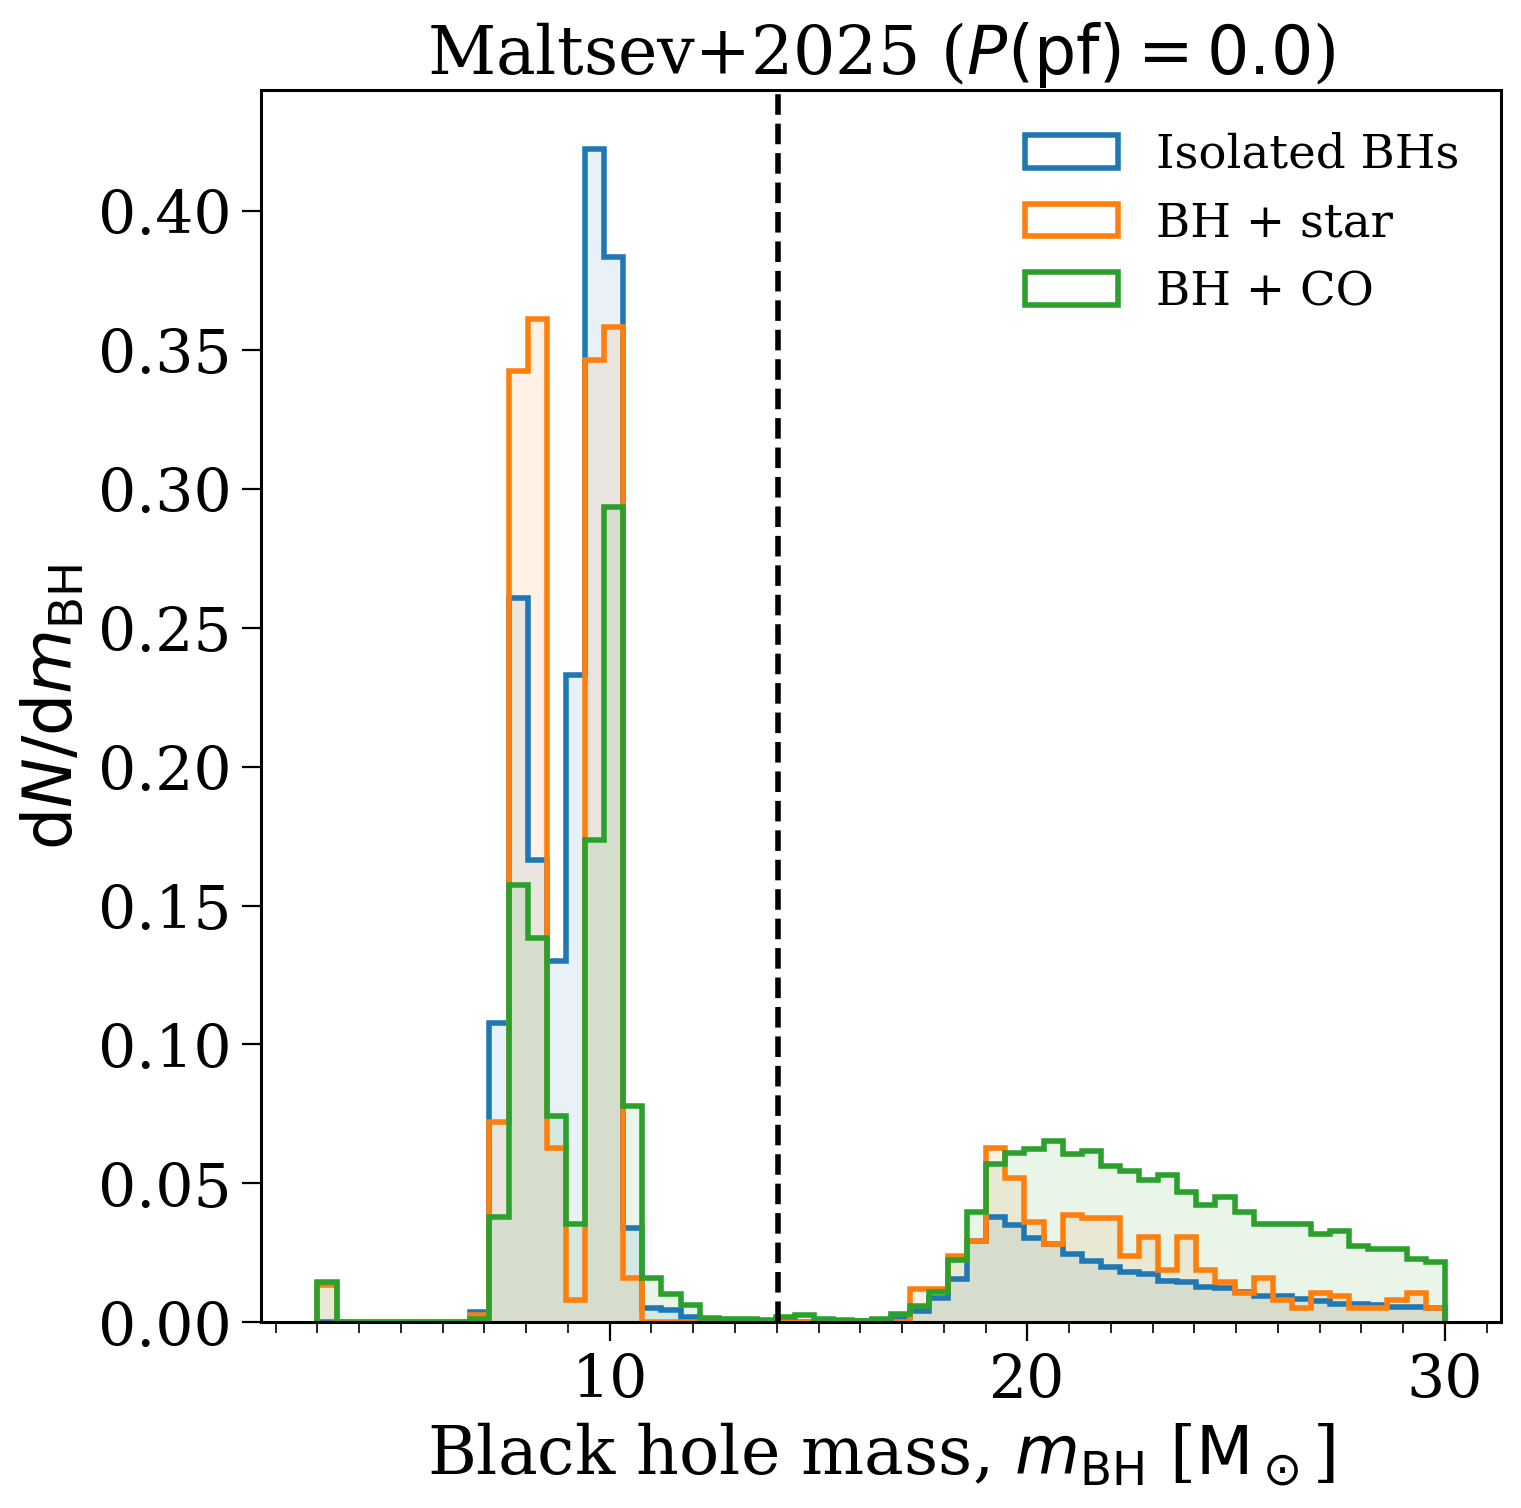

$P({\rm pf}) = 1.0$ 1817


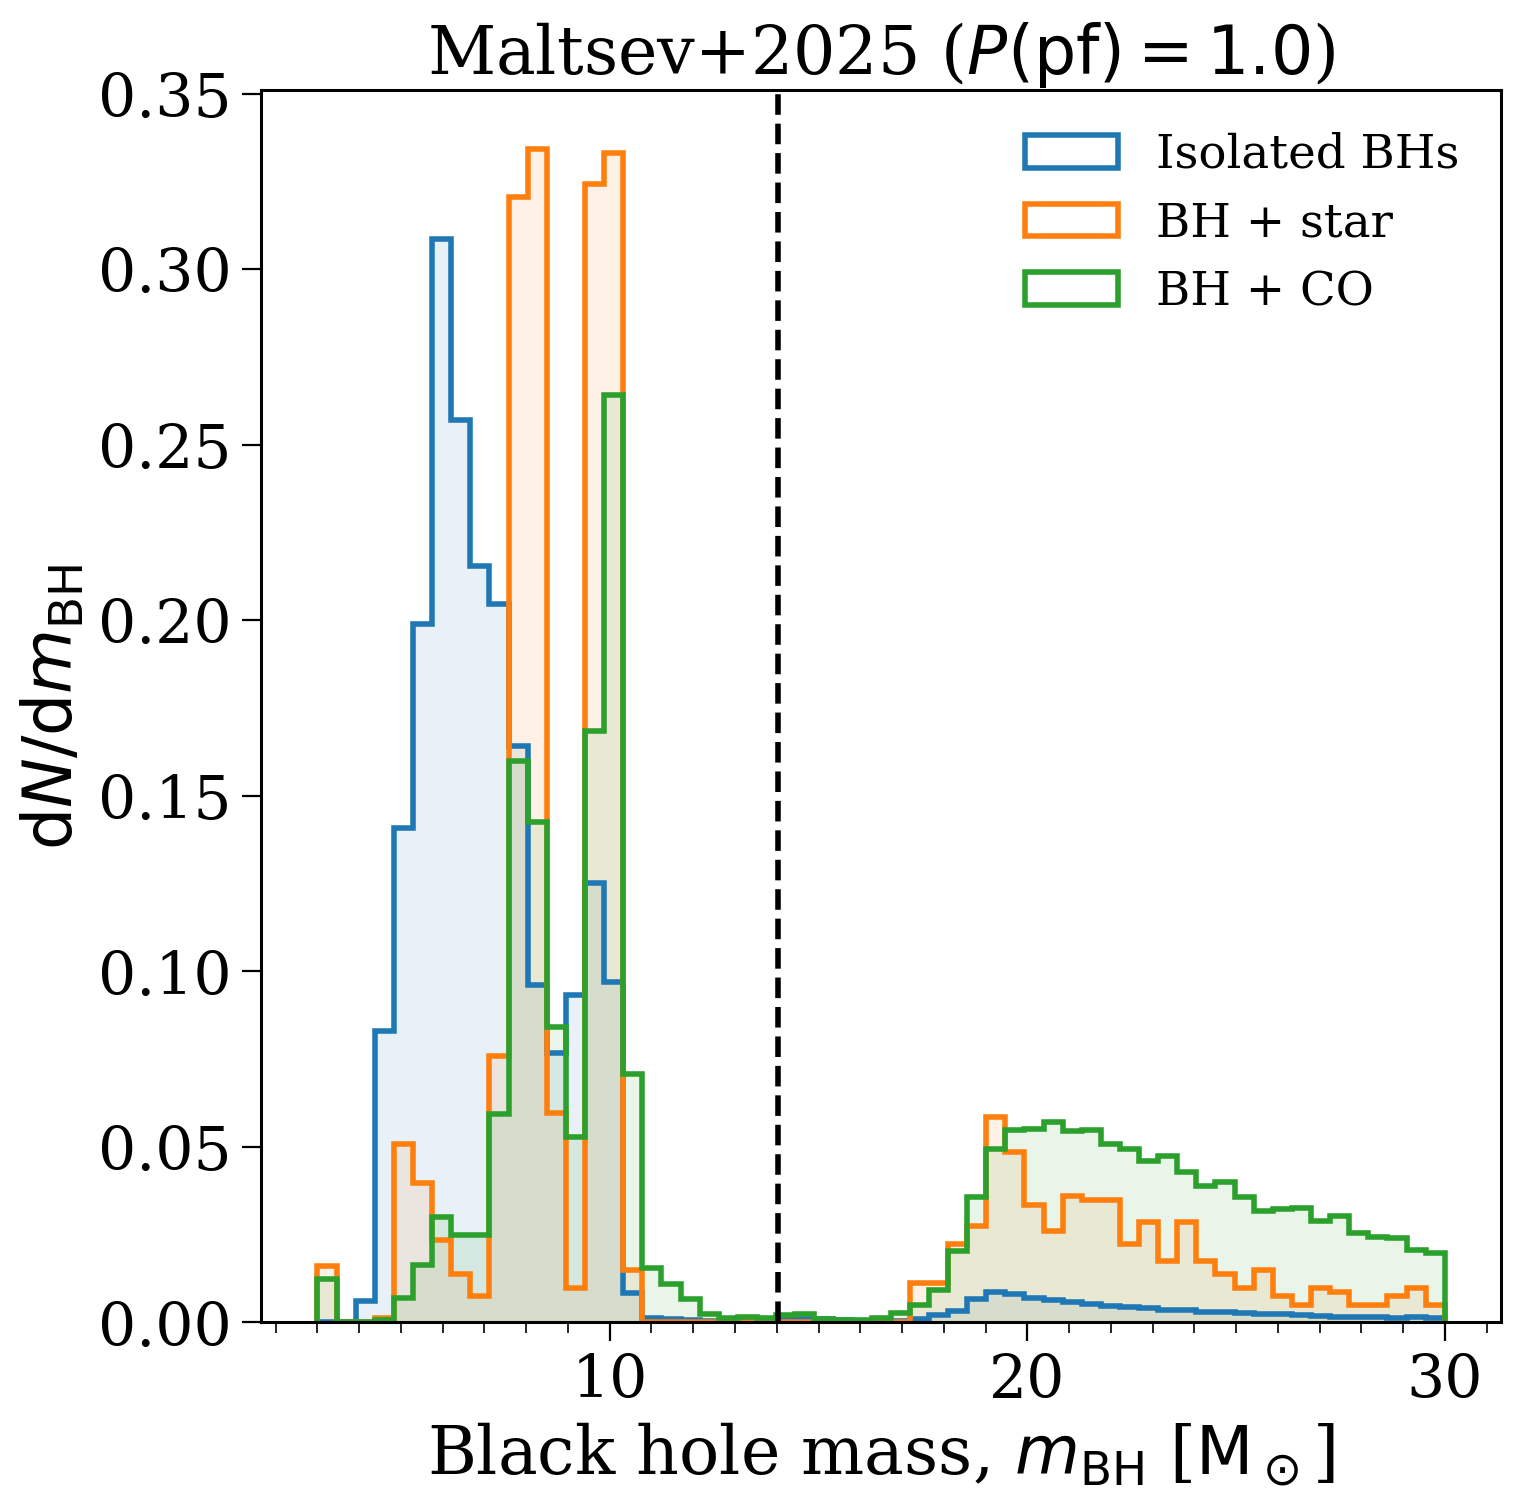

Time-evolving potential 1917


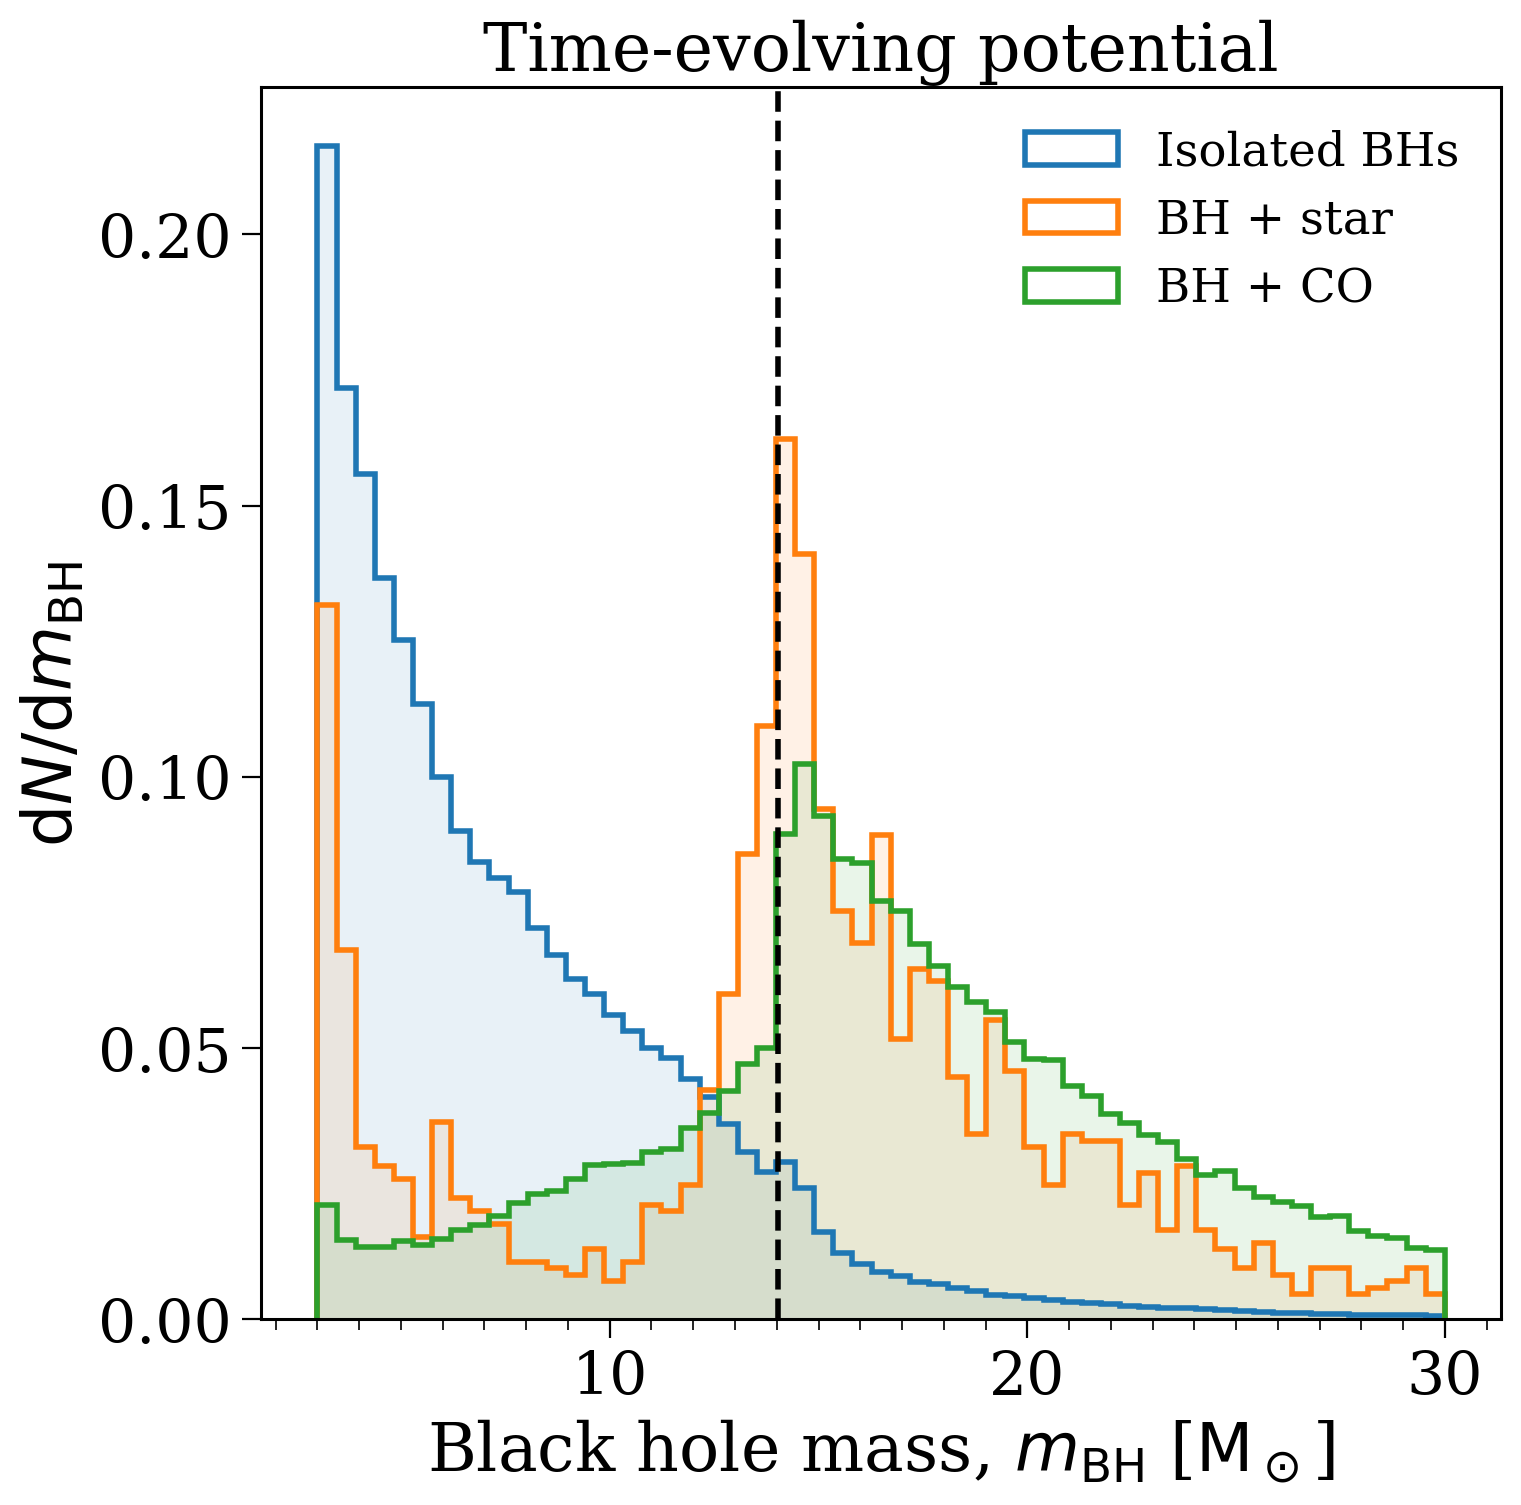

$\alpha_{\rm IMF} = -1.9$ 8523


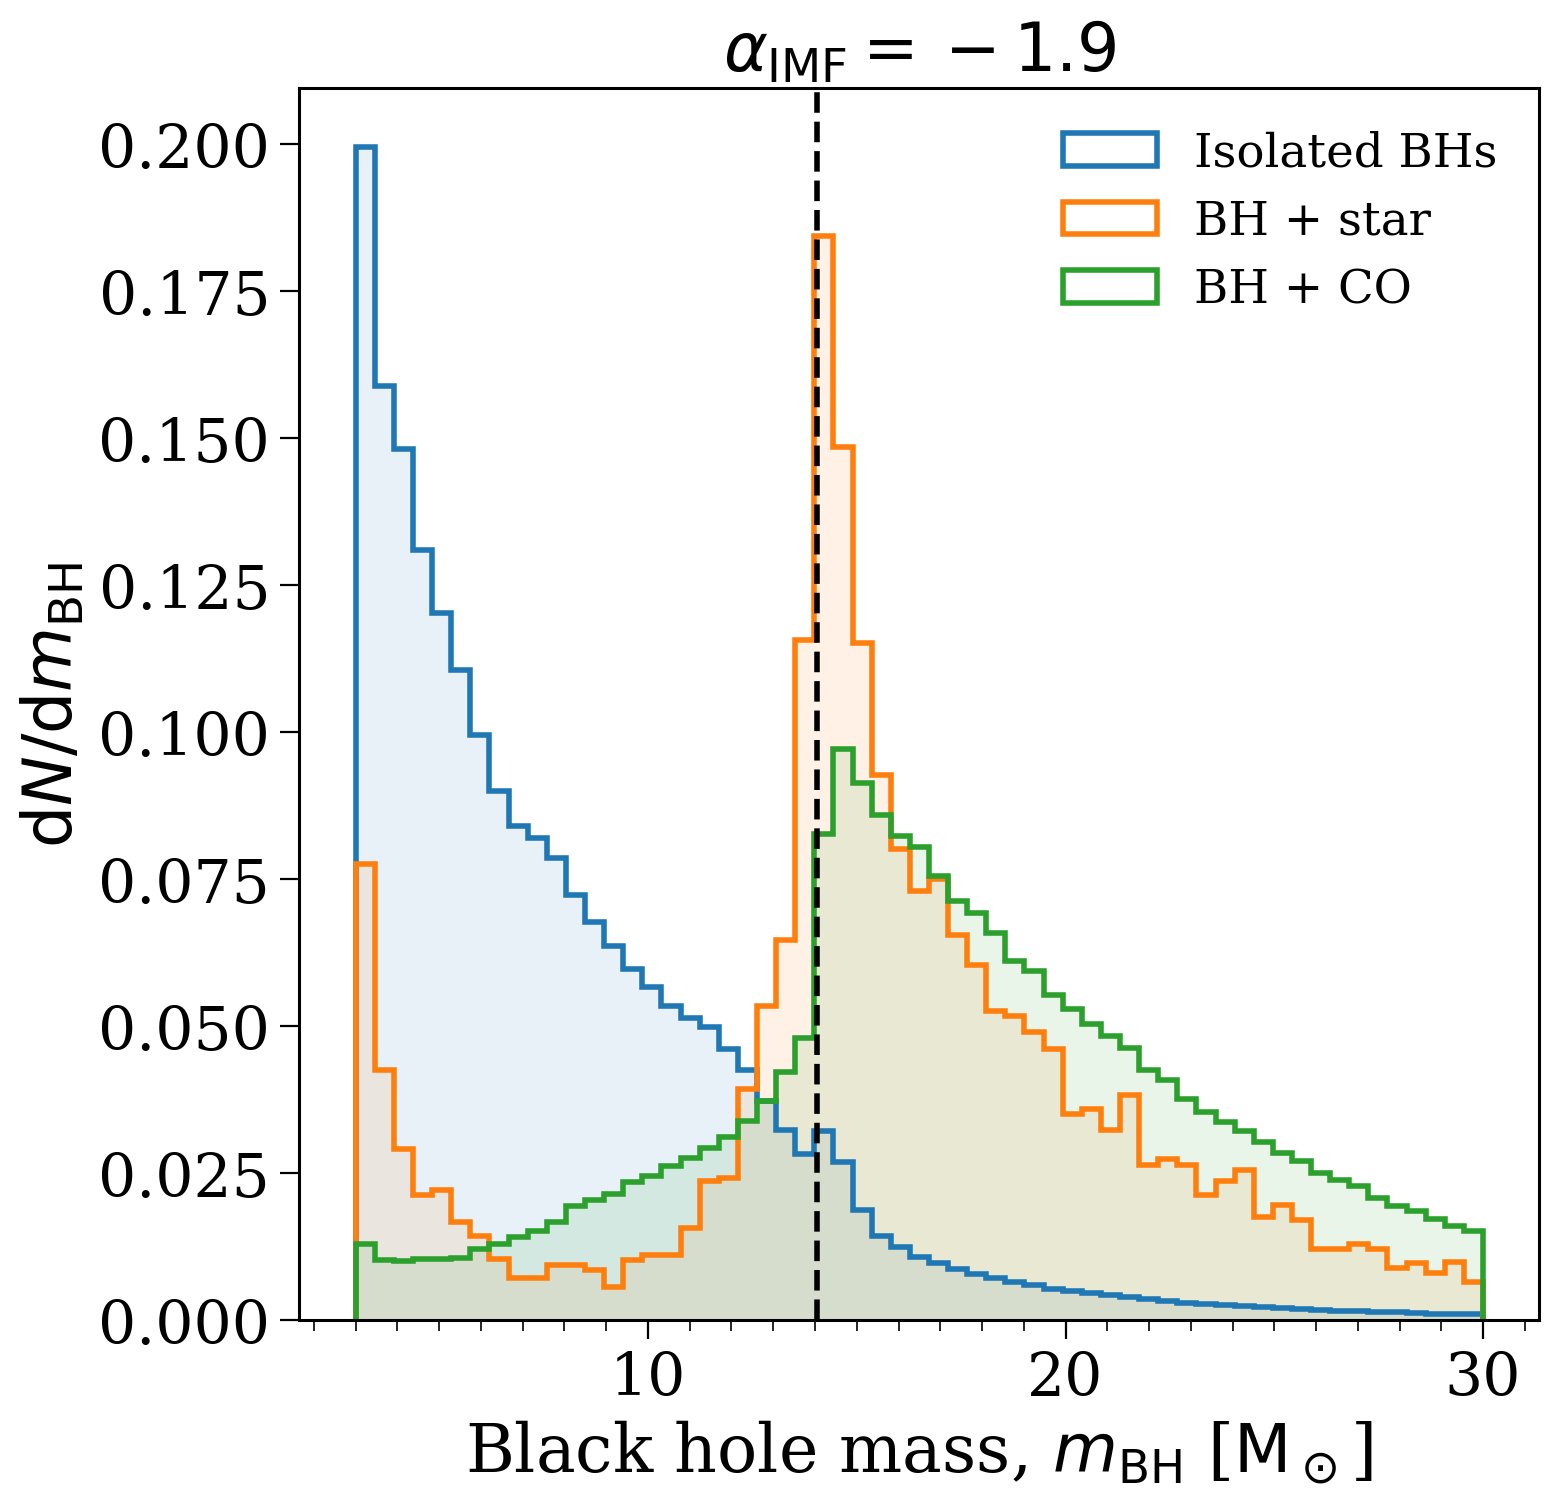

$\alpha_{\rm IMF} = -2.7$ 259


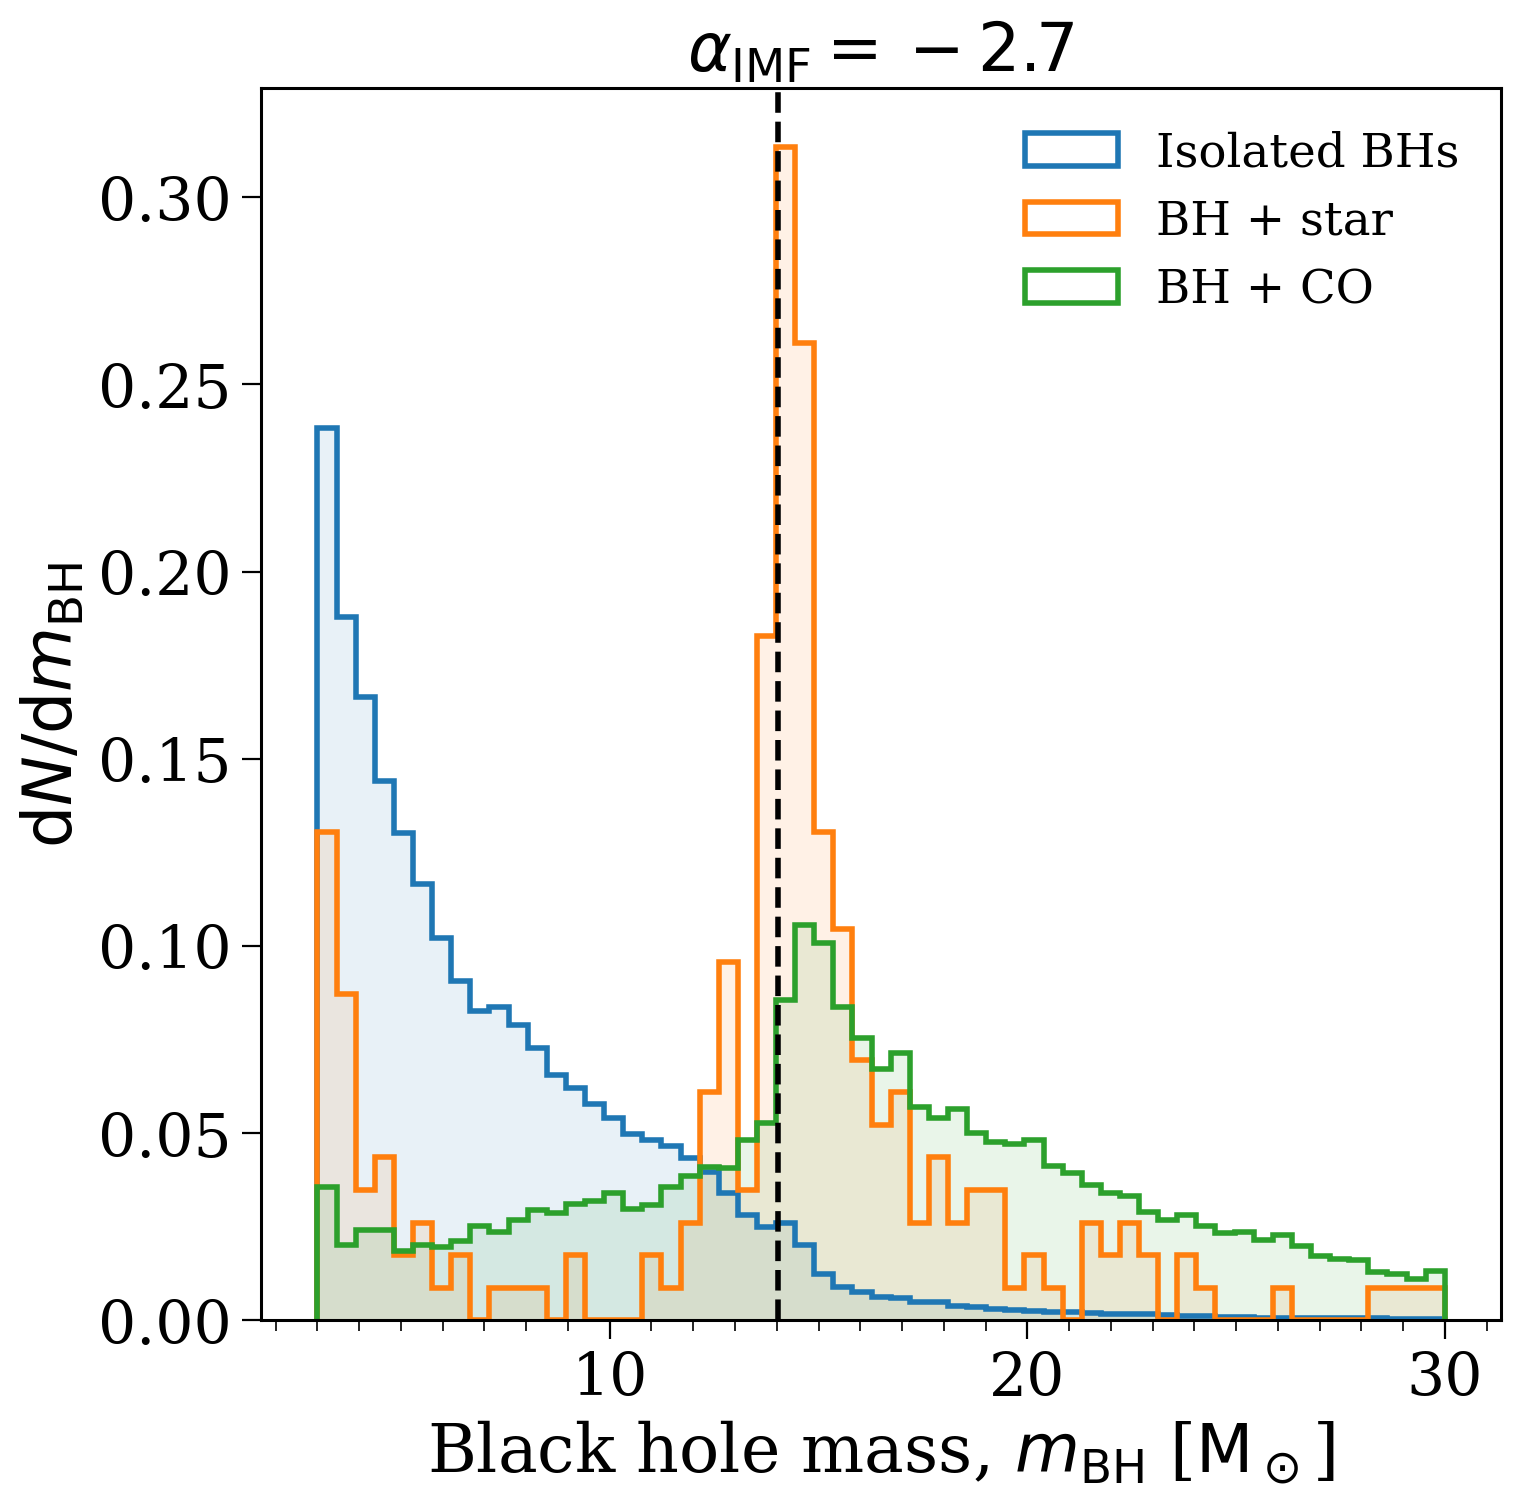

$\kappa = -1.0$ 42860


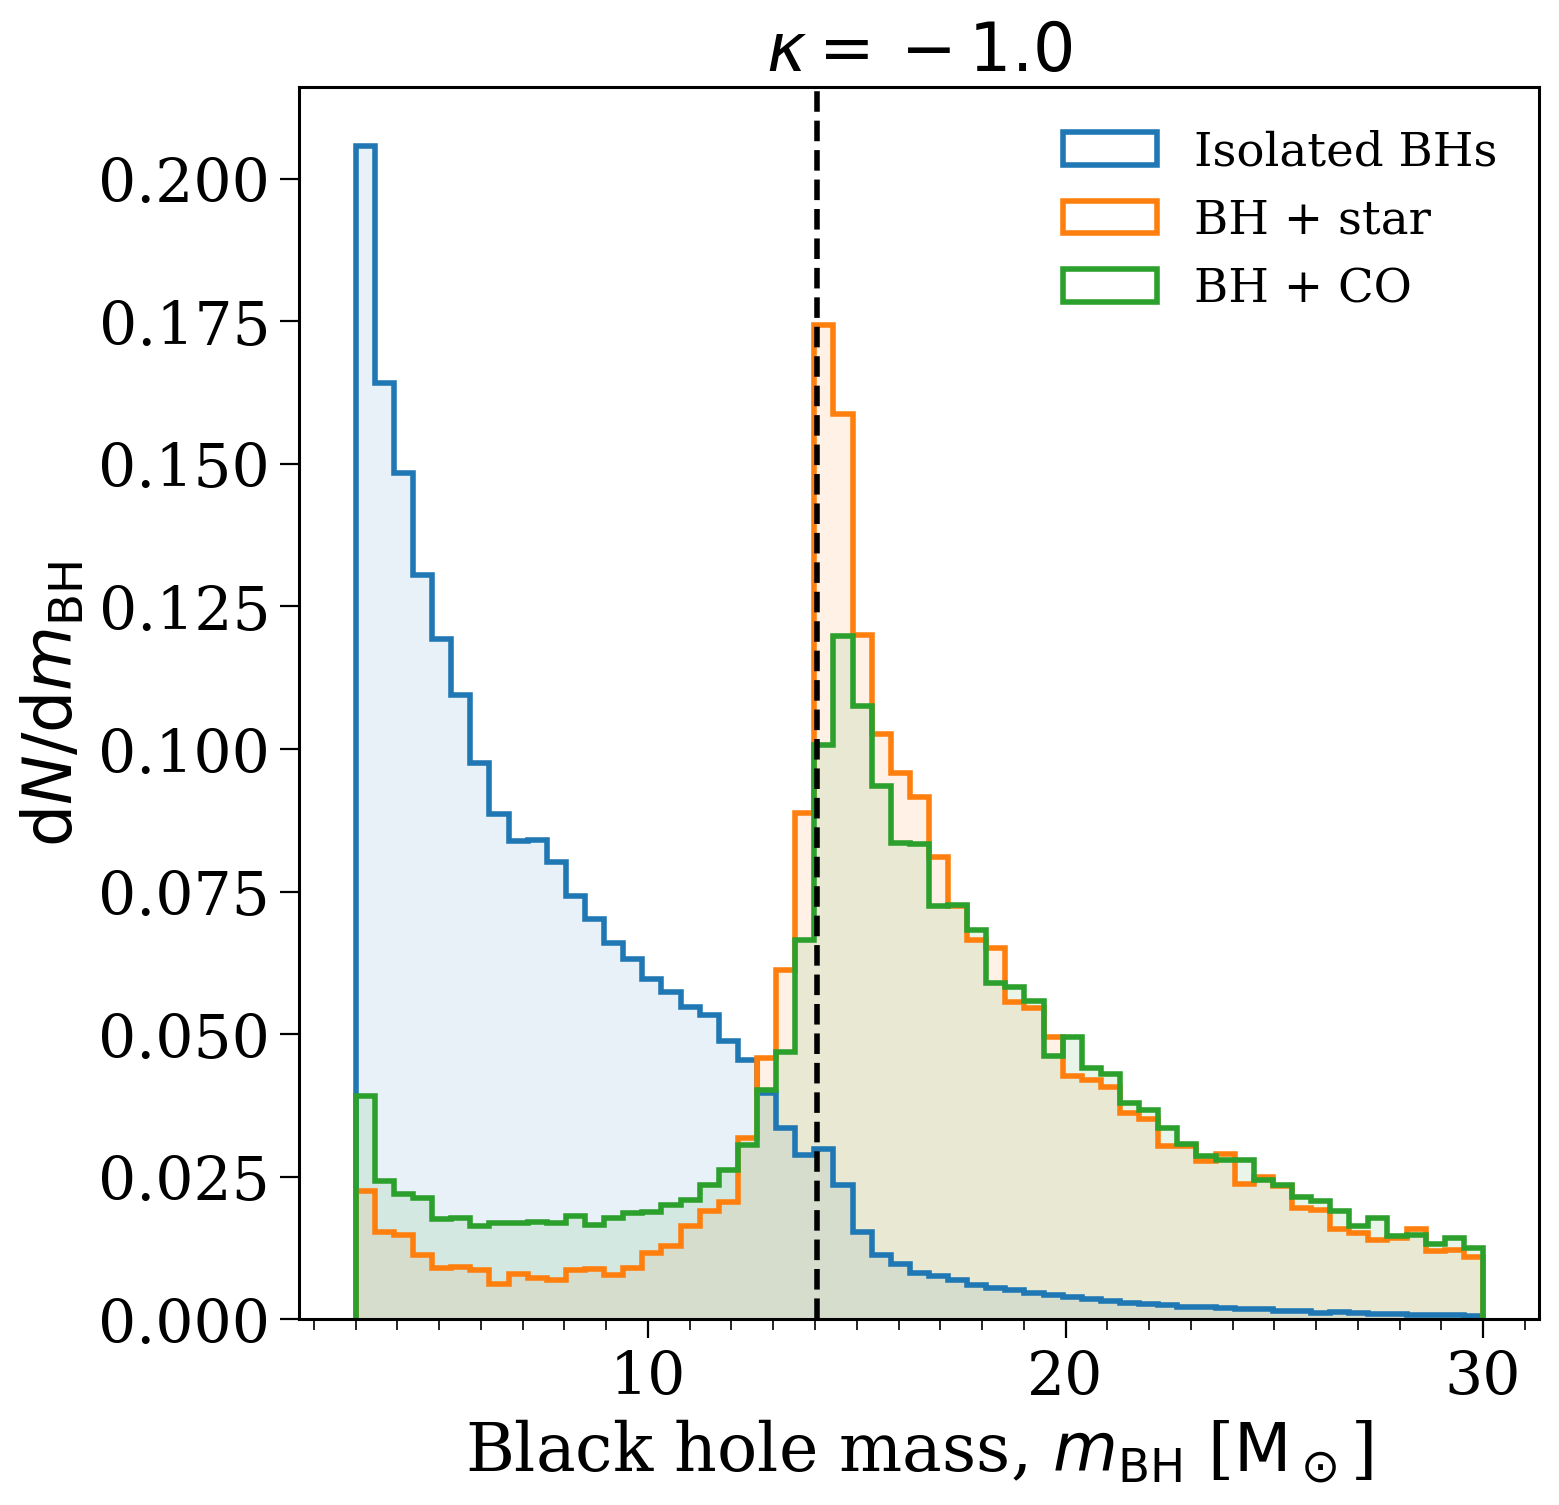

$\kappa = 1.0$ 53


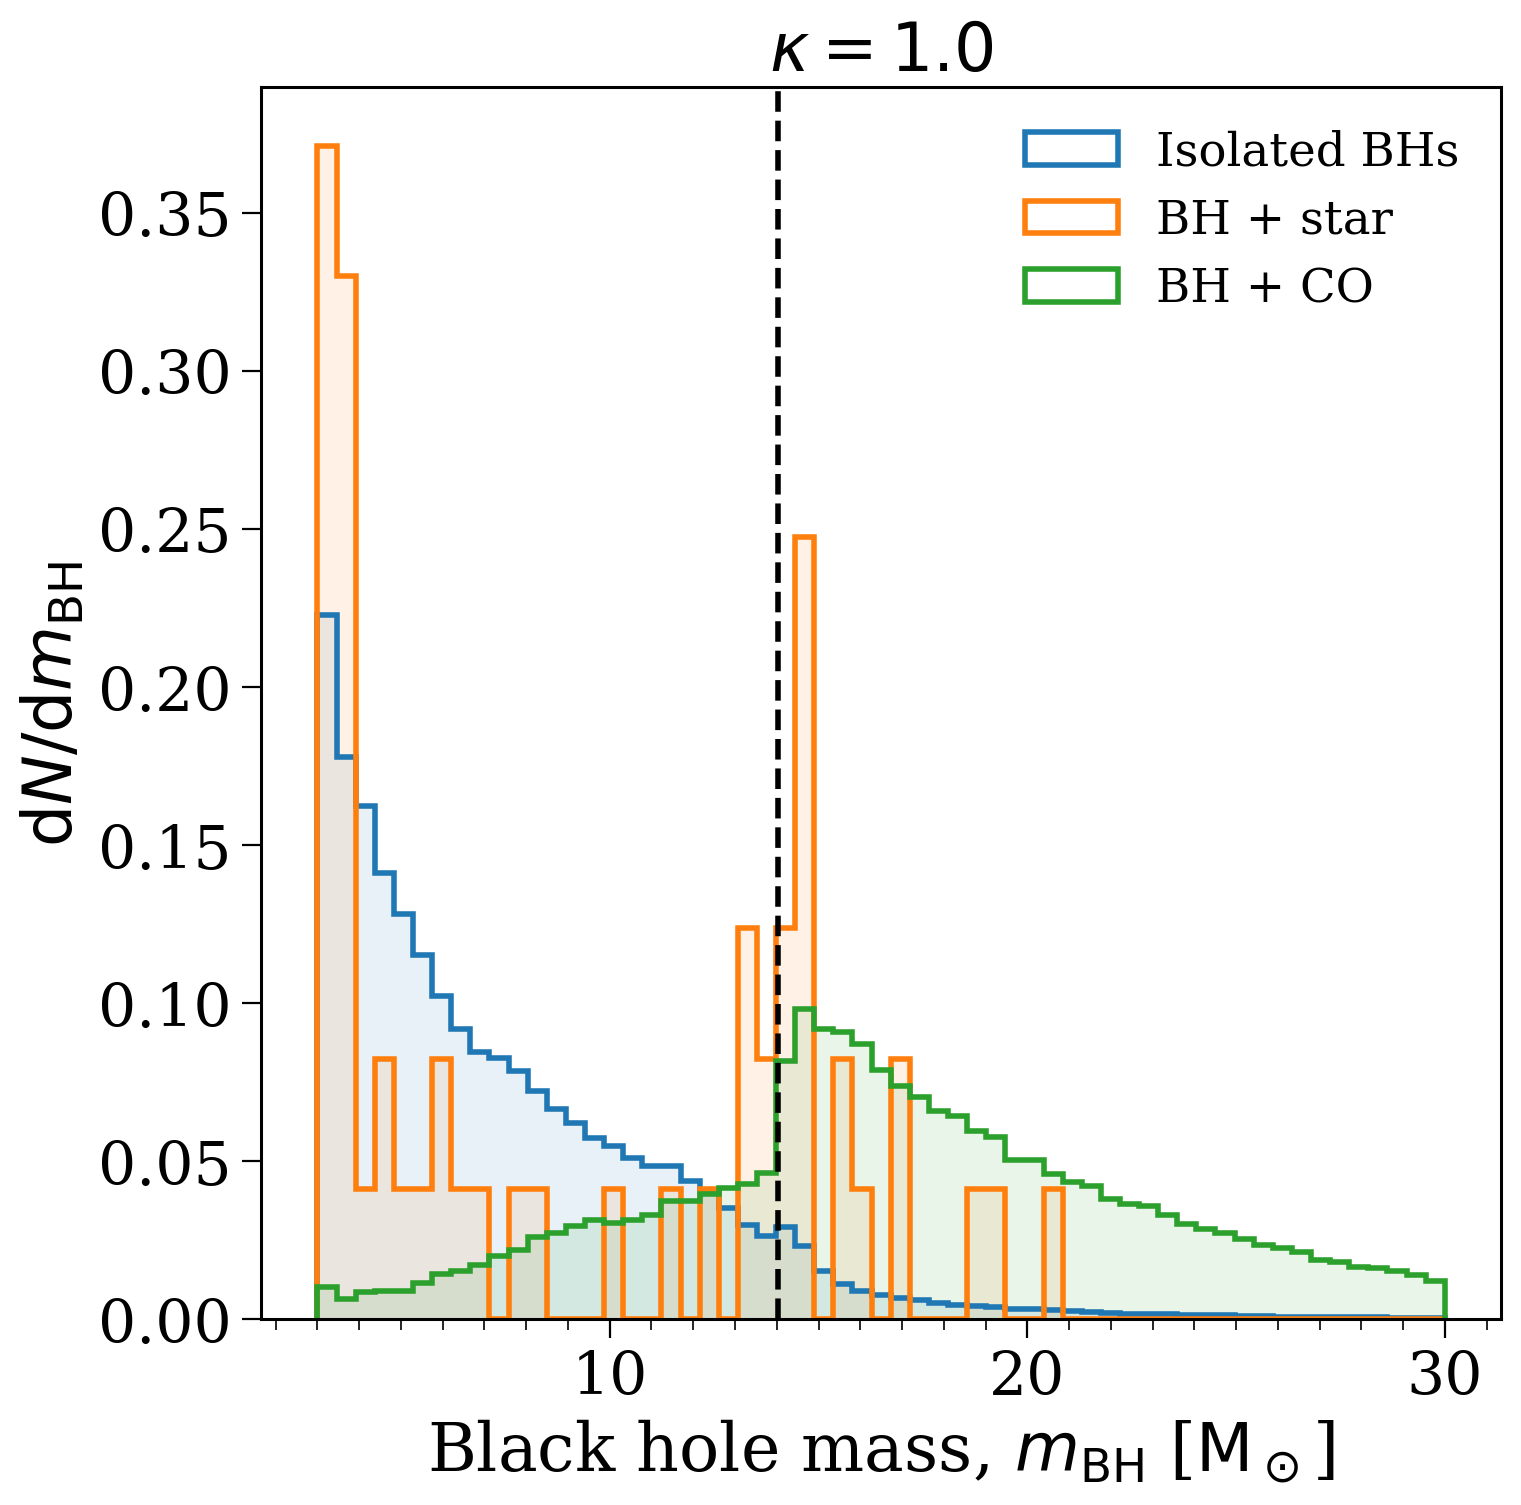

$q_{\rm min} = -1.0$ 176


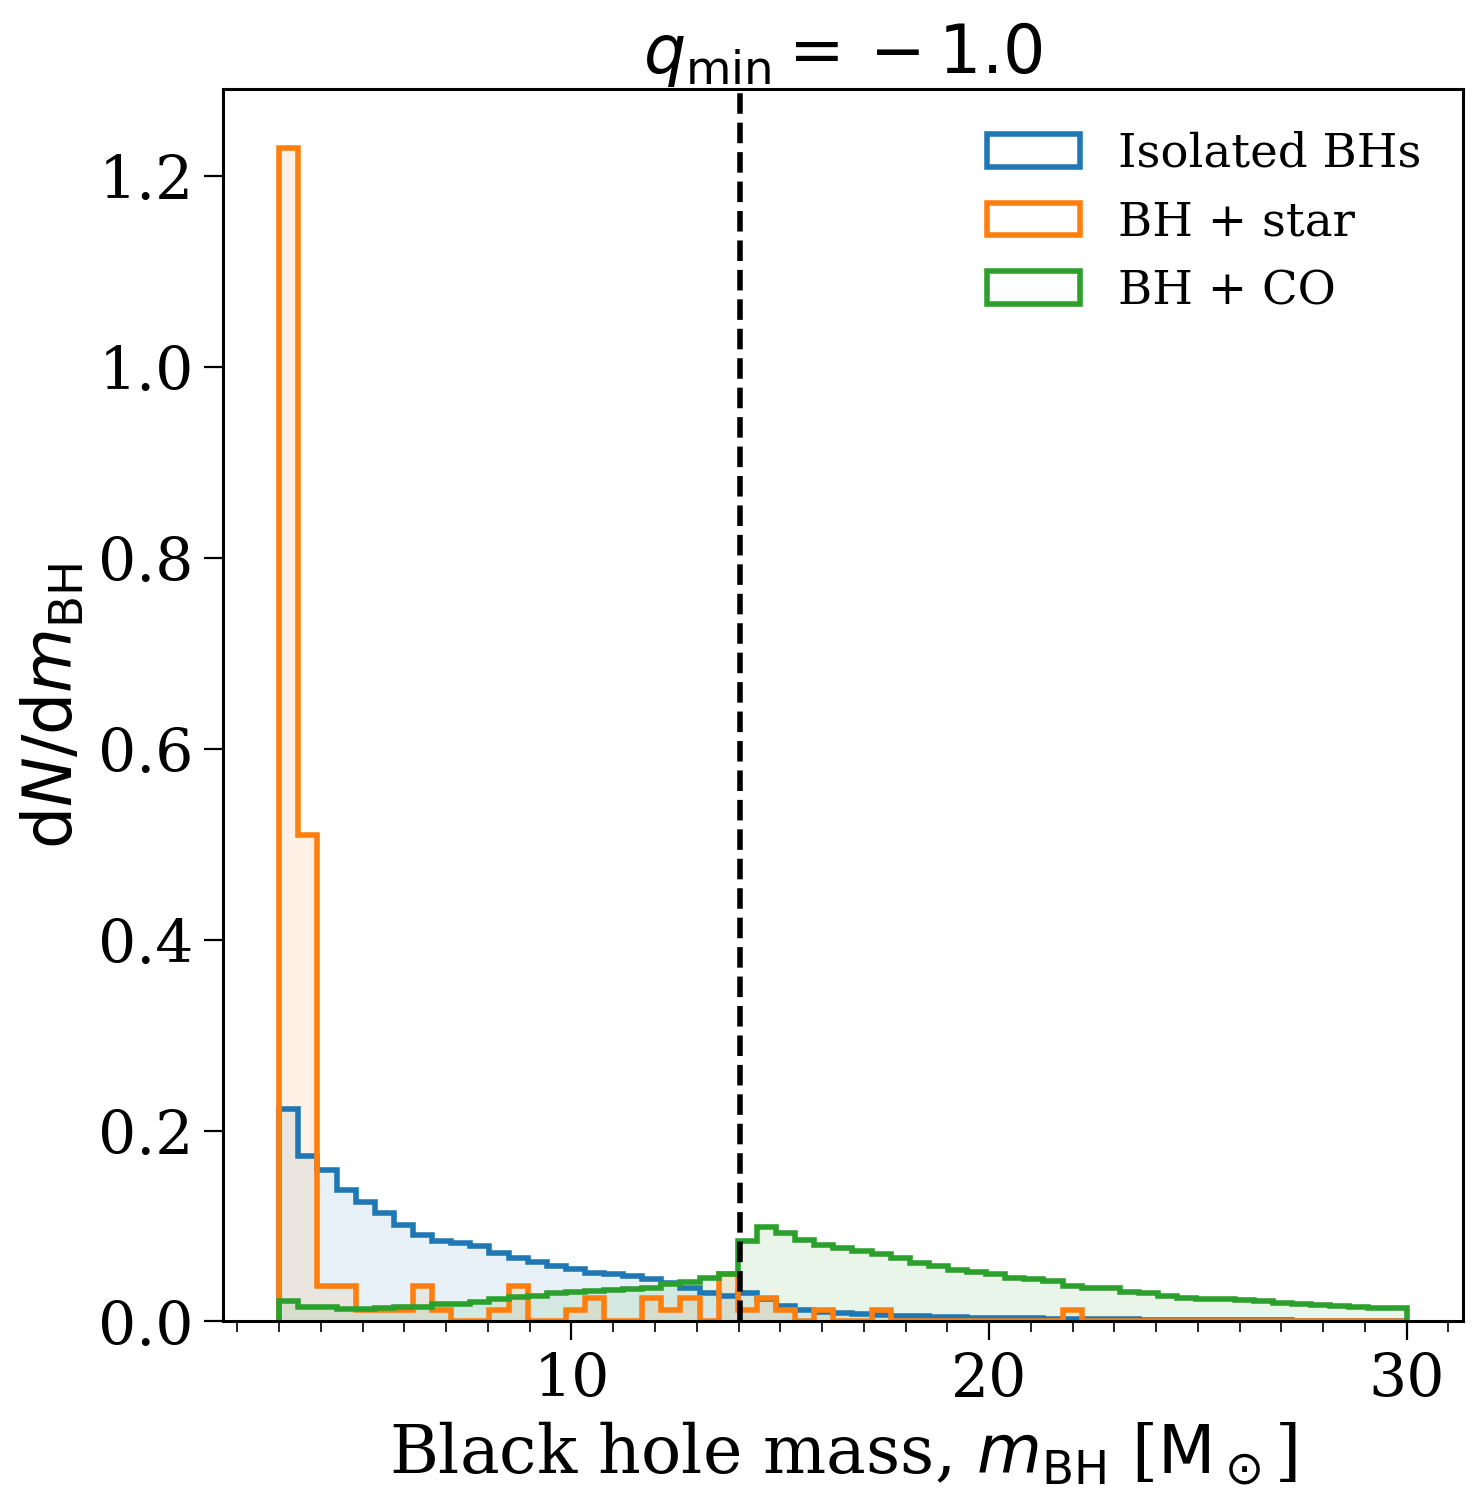

$\pi = 0.0$ 2024


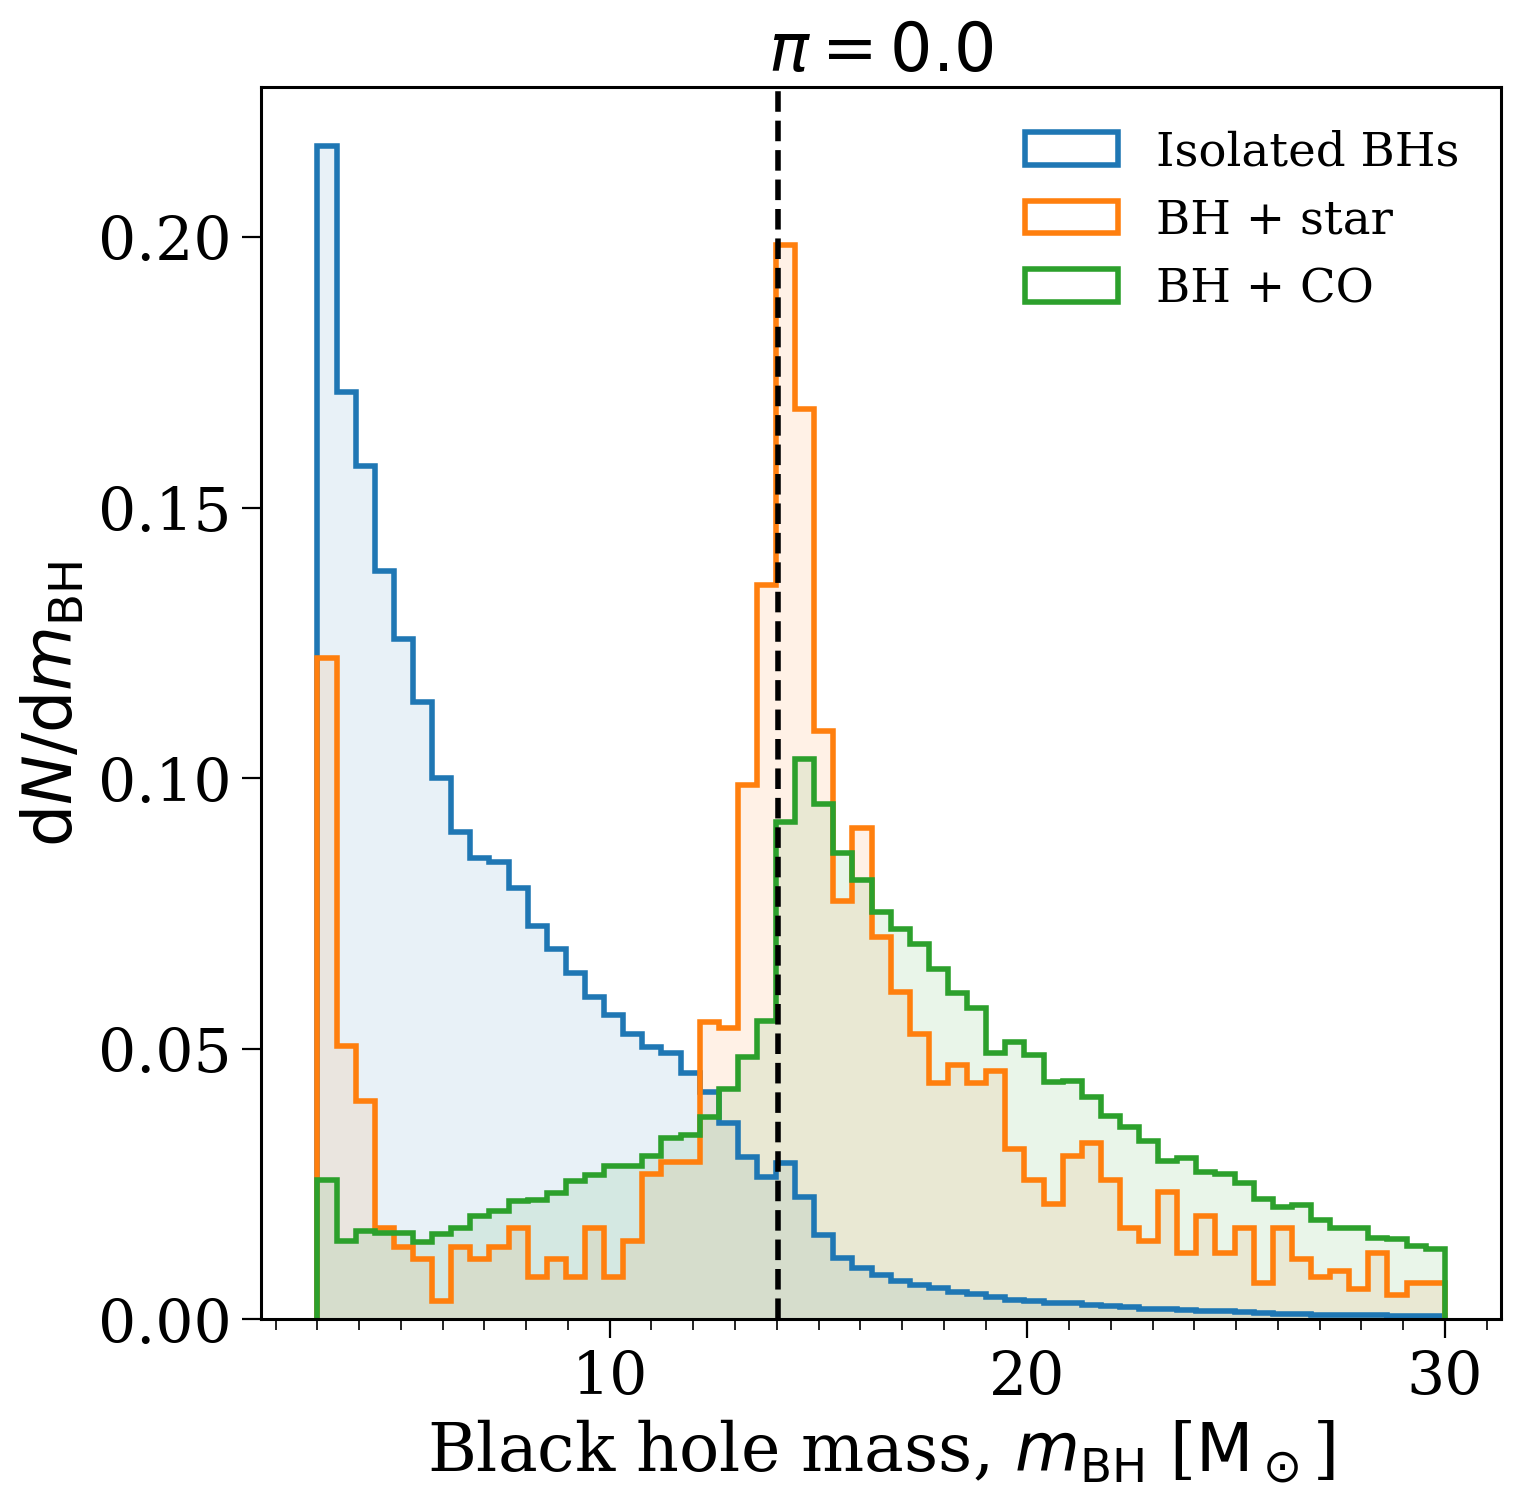

$\pi = -1.0$ 1174


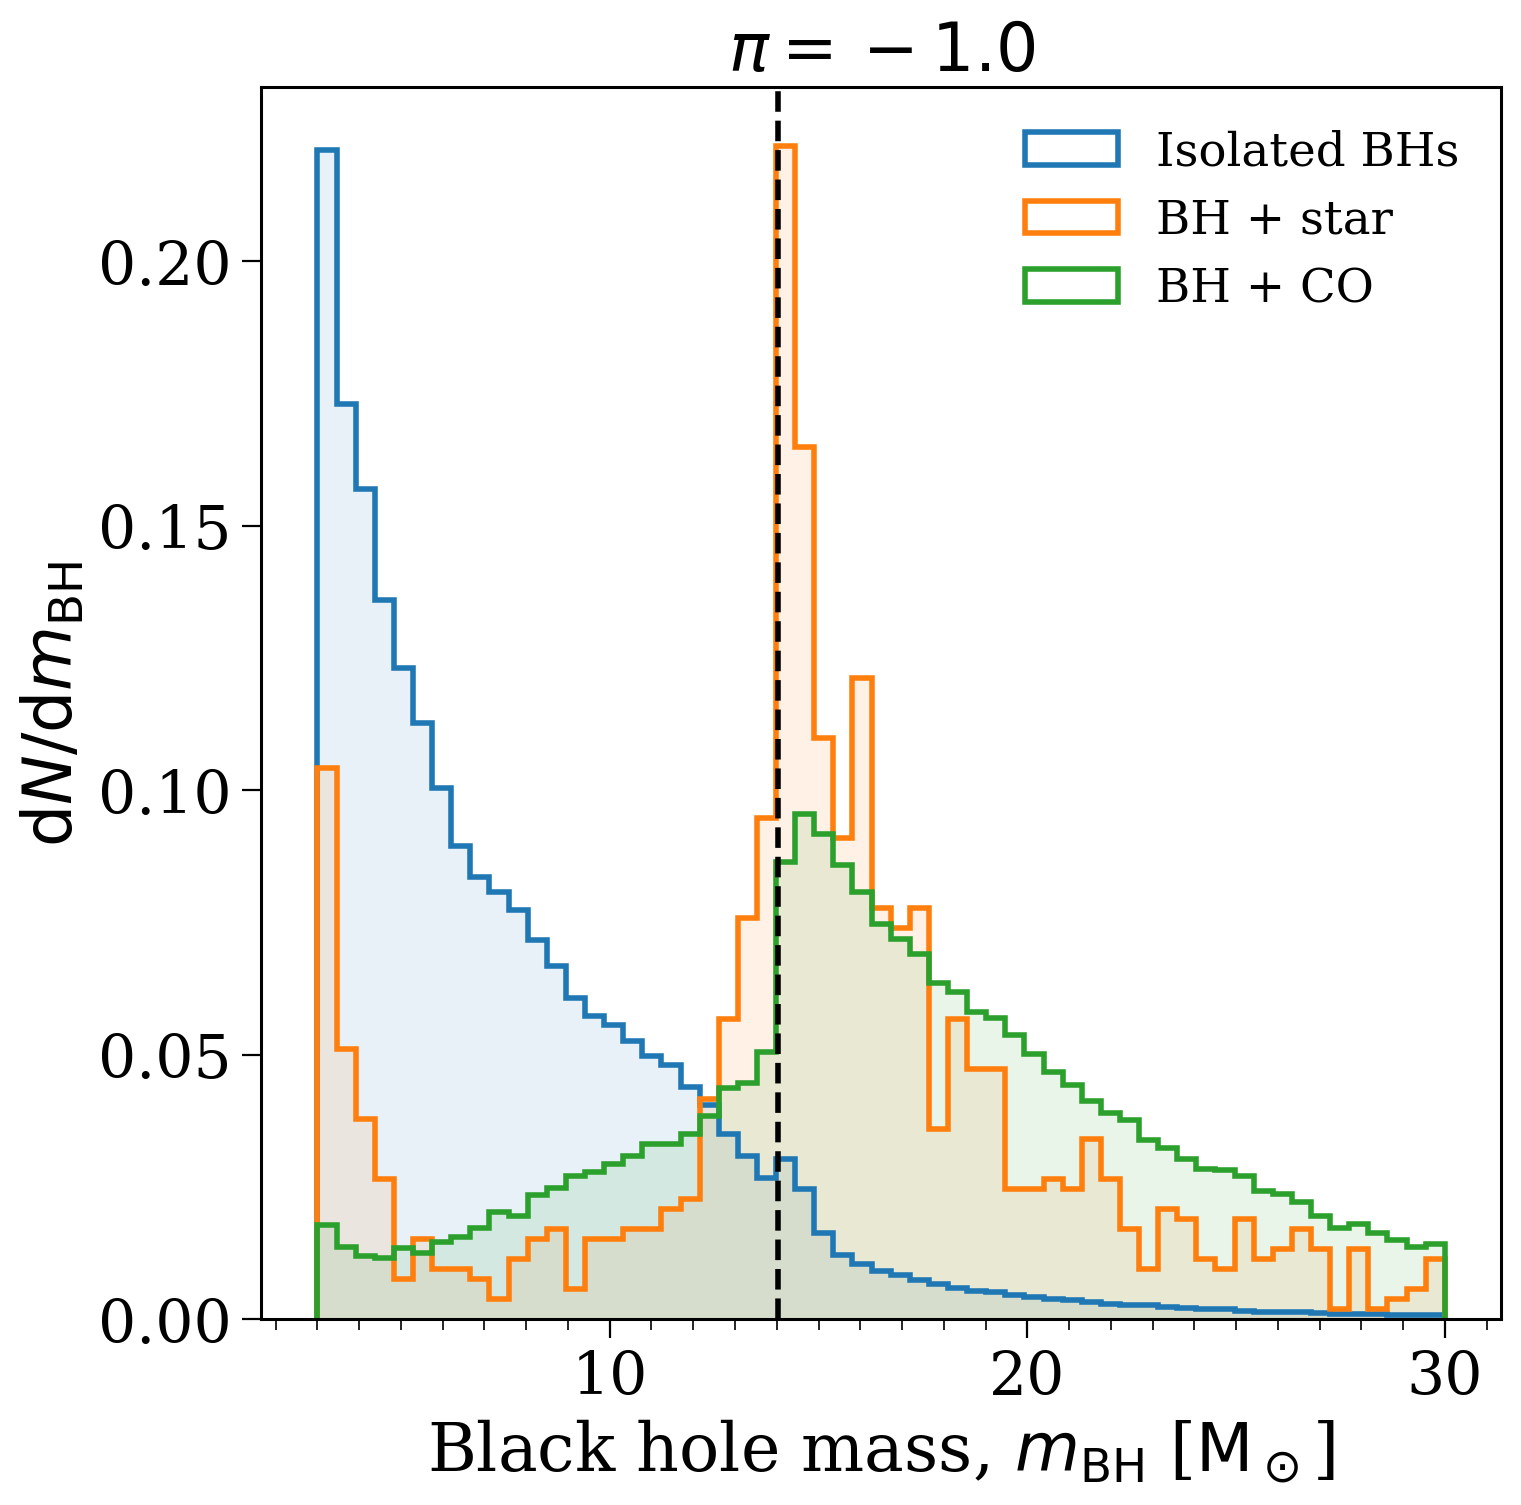

$P_{\rm orb, max} = 10^3\,{\rm days}$ 1905


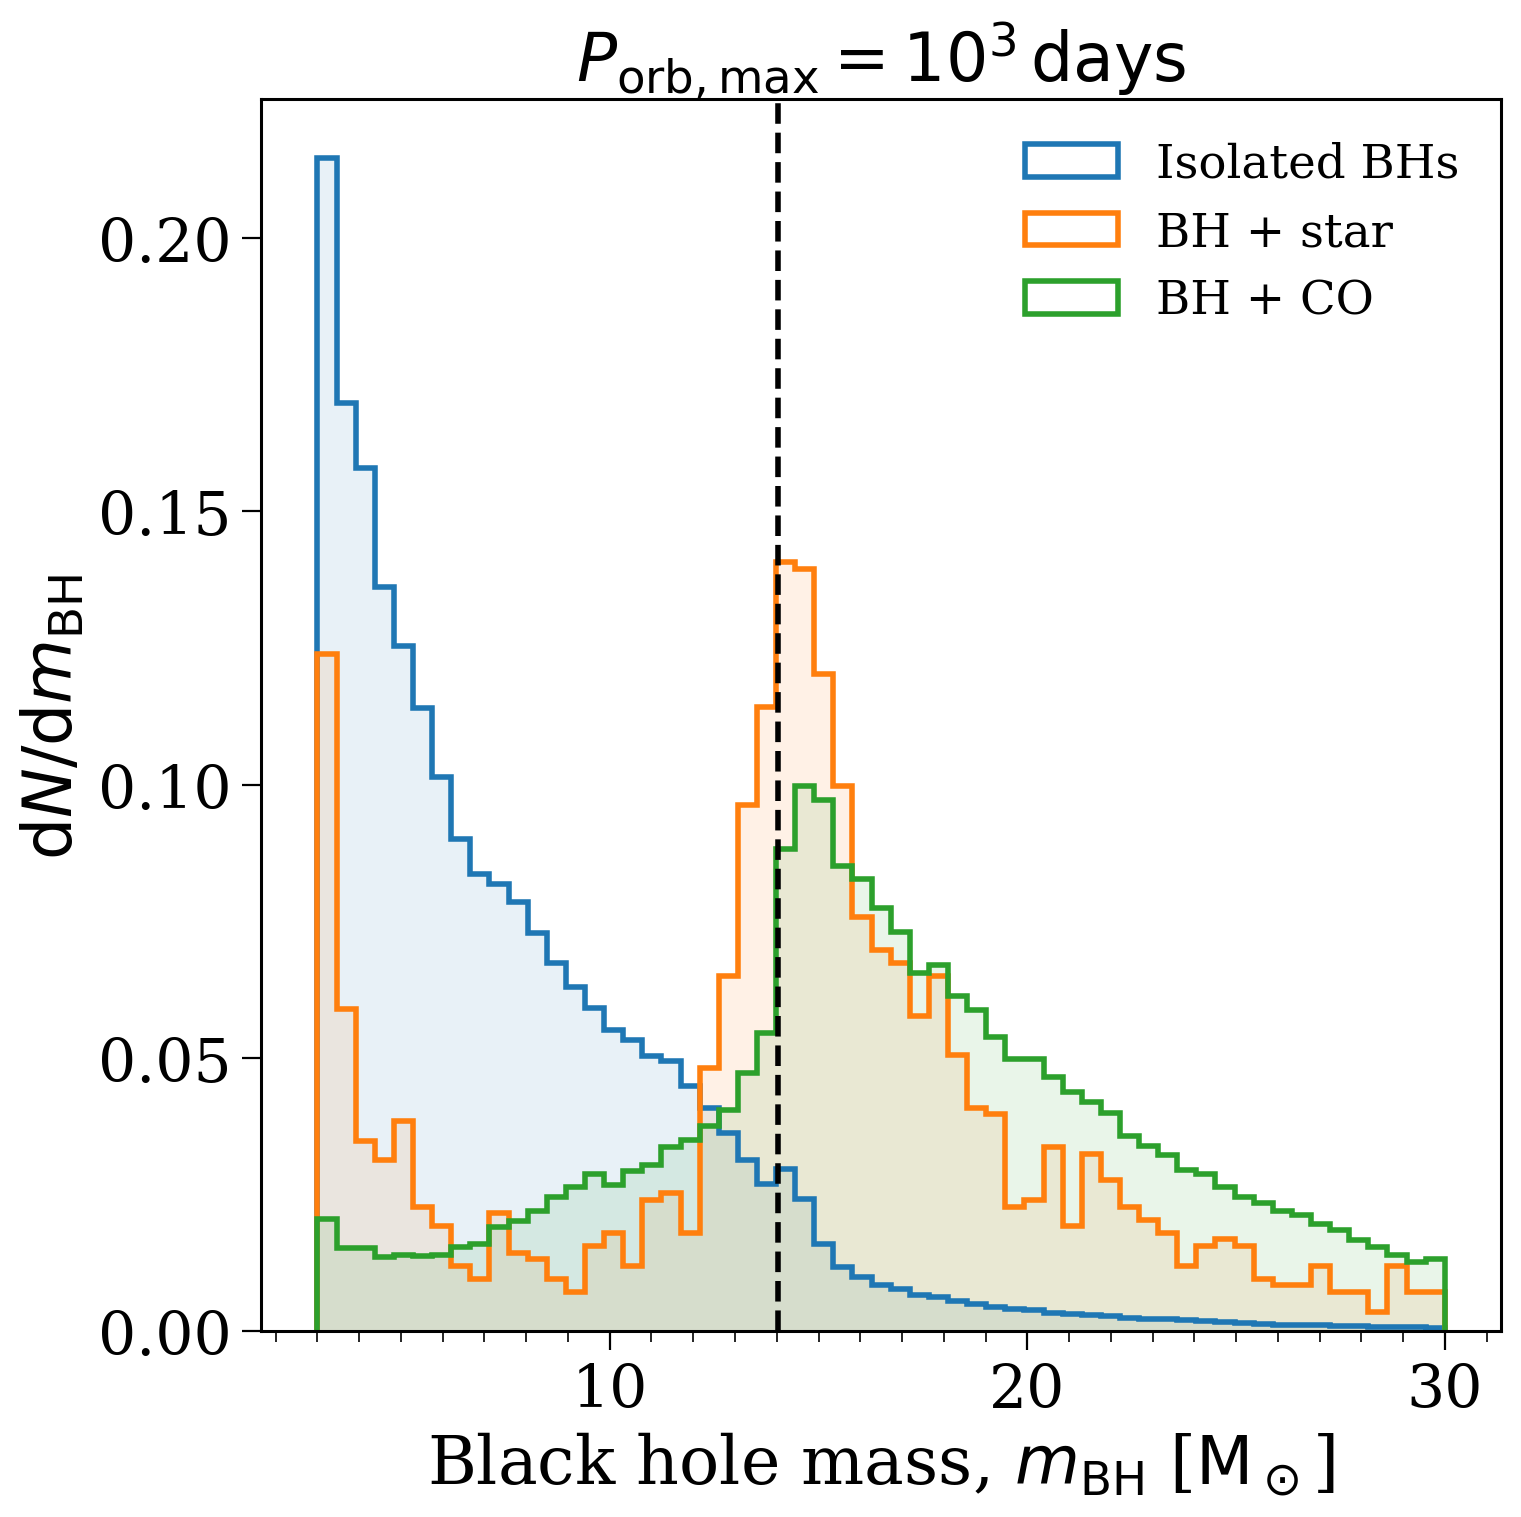

$\beta = 0.0$ 1824


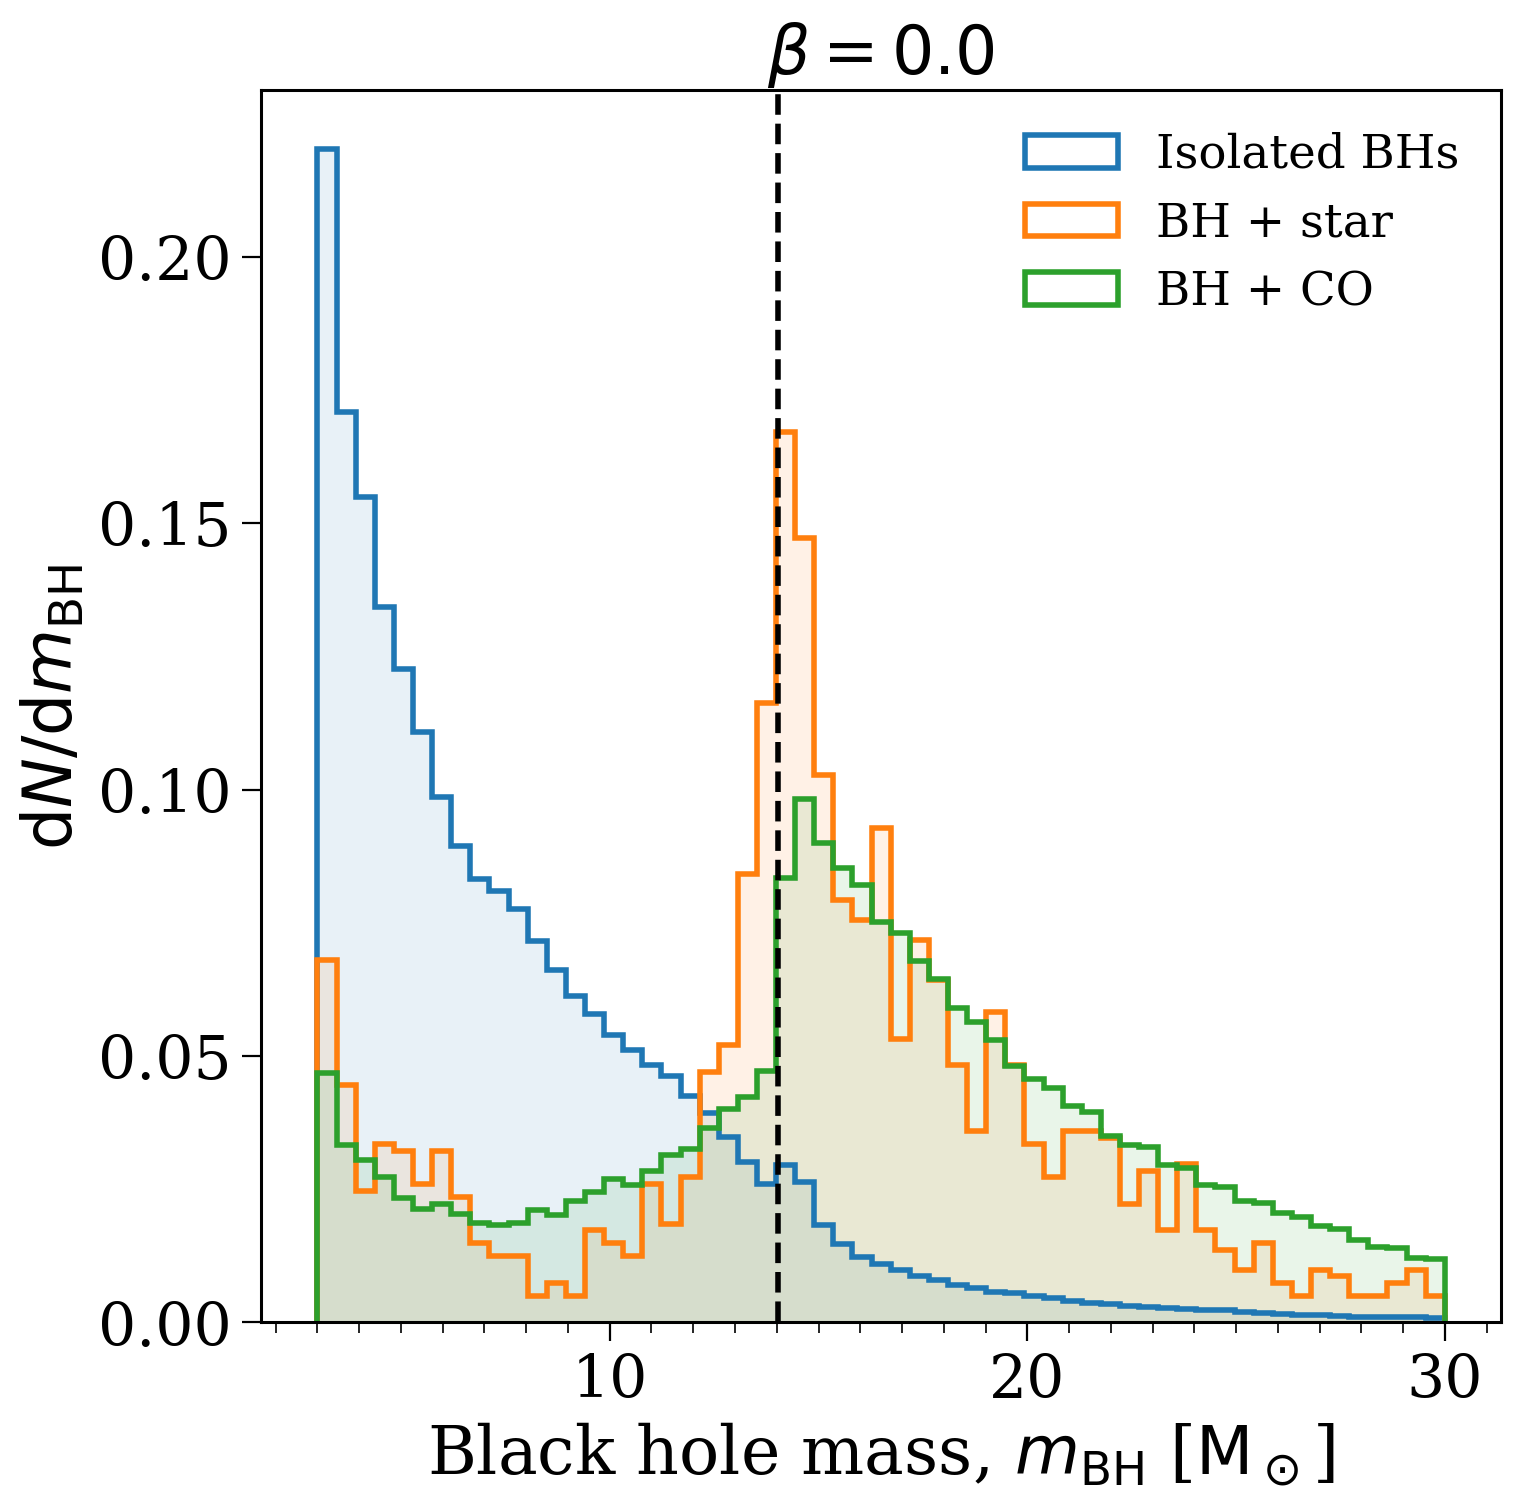

$\beta = 0.5$ 1827


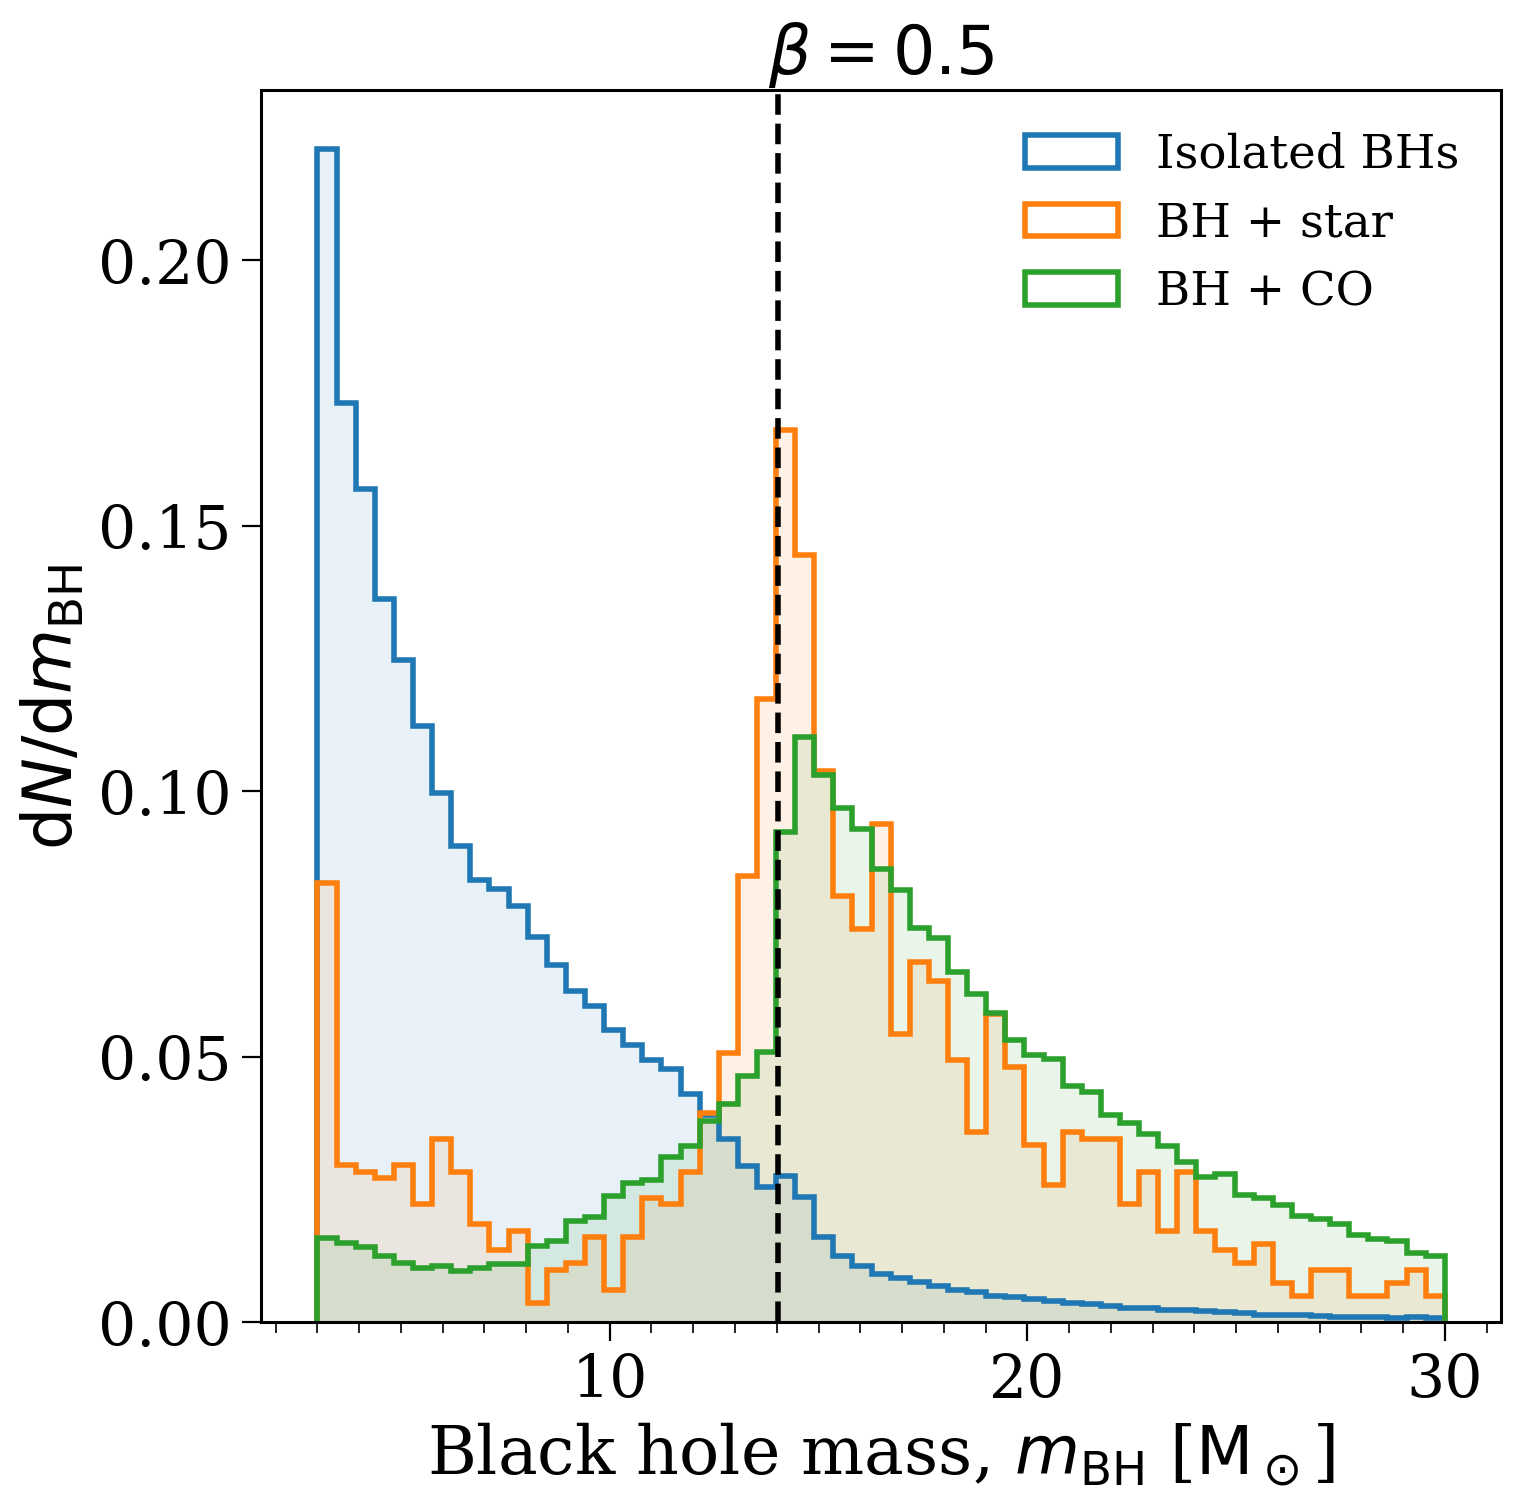

$\beta = 1.0$ 1945


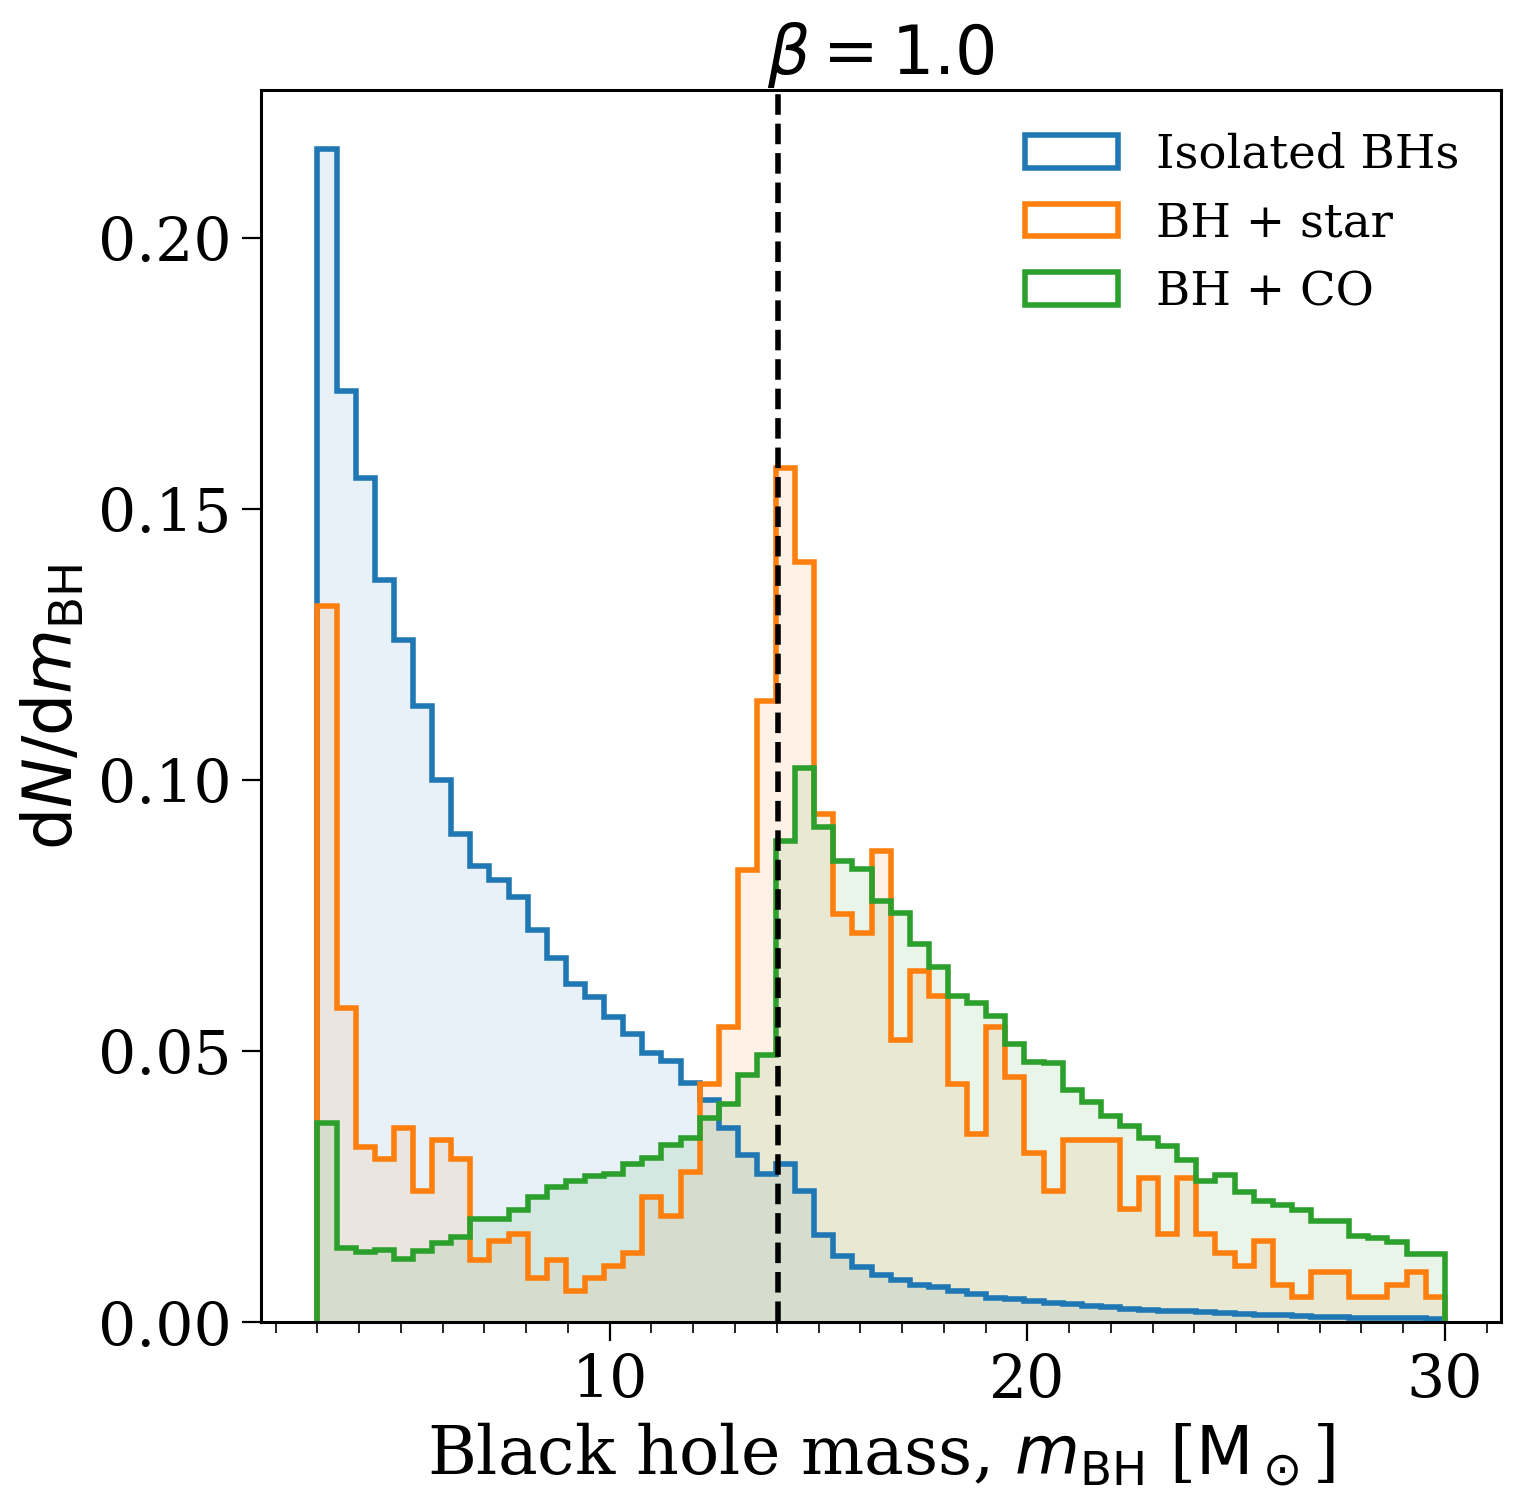

$\alpha_{\rm CE} = 0.1$ 1611


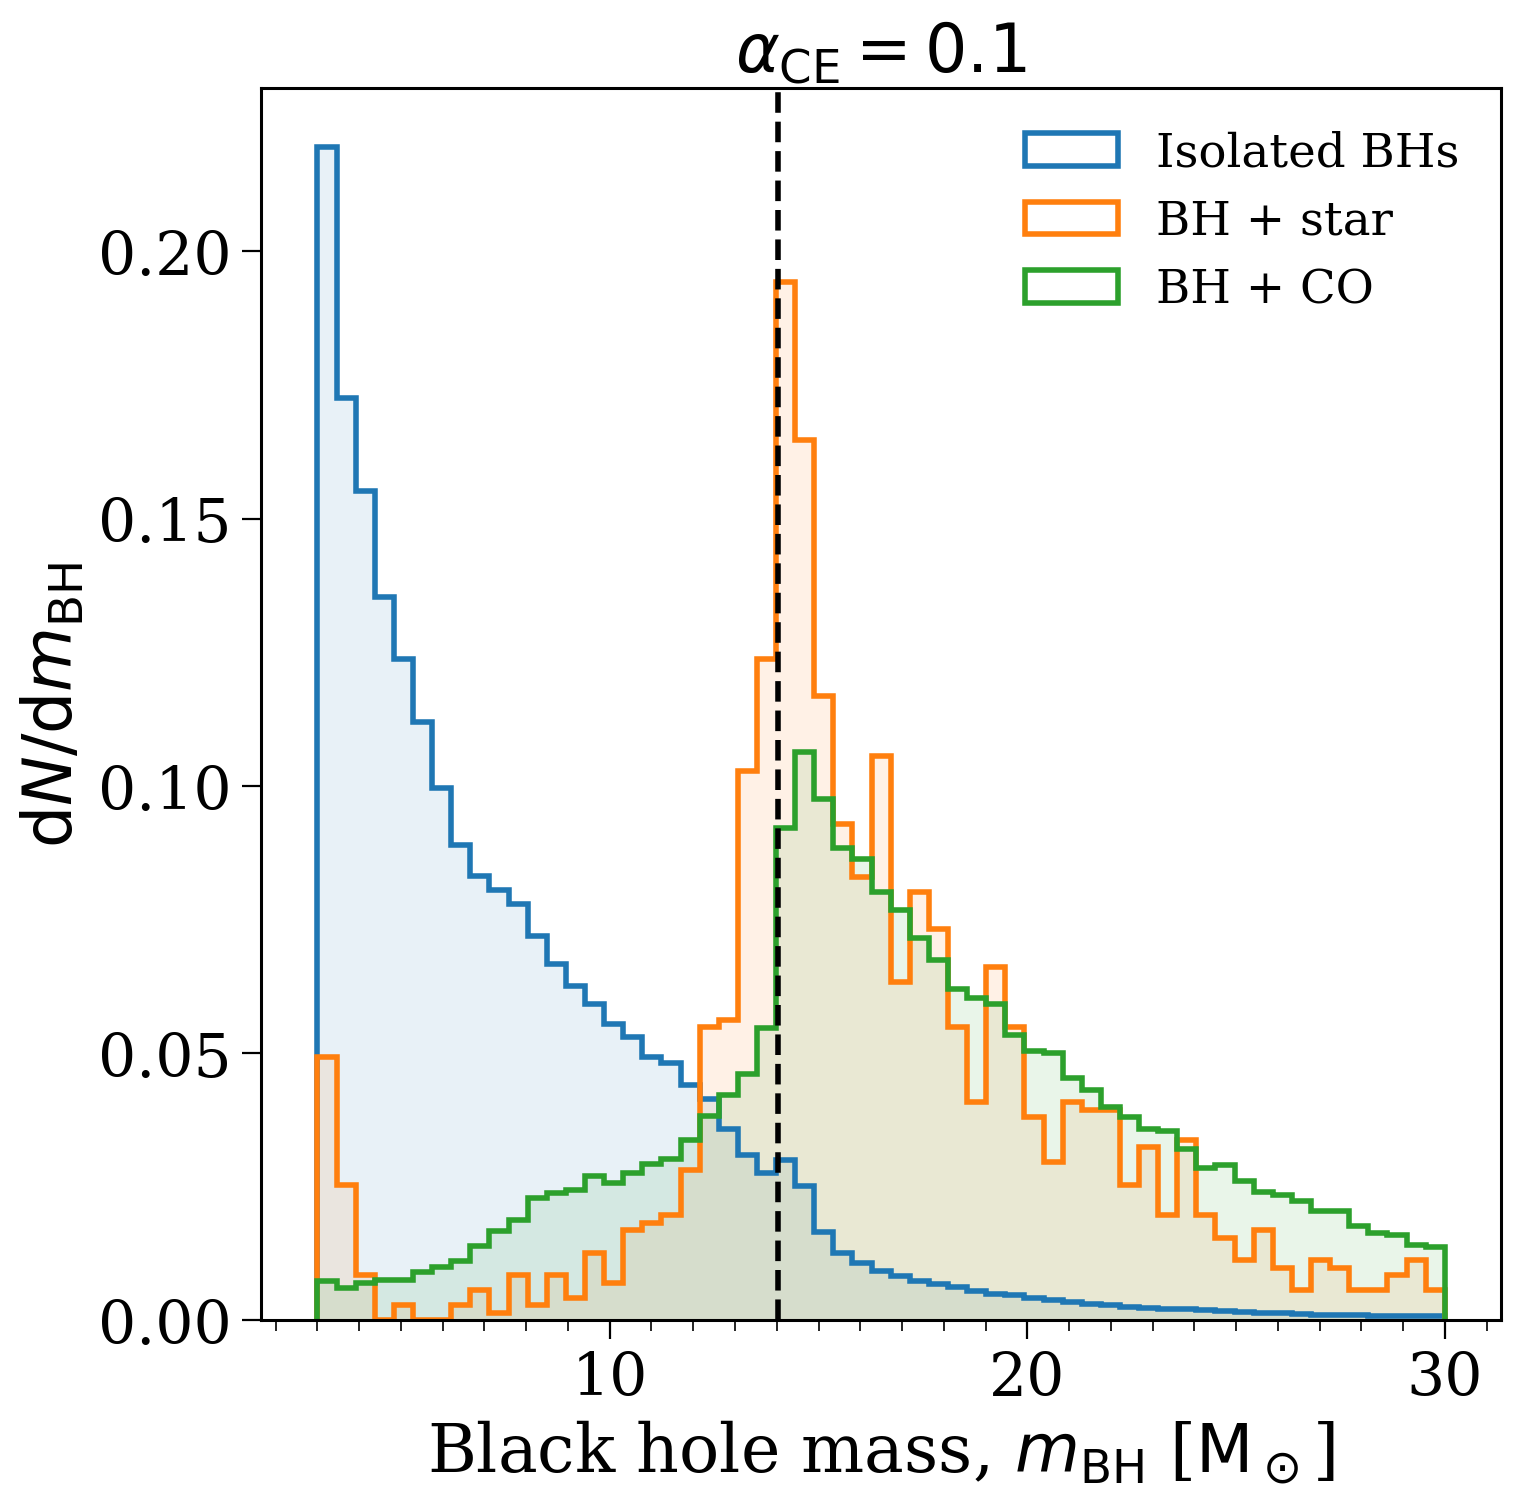

$\alpha_{\rm CE} = 0.5$ 1827


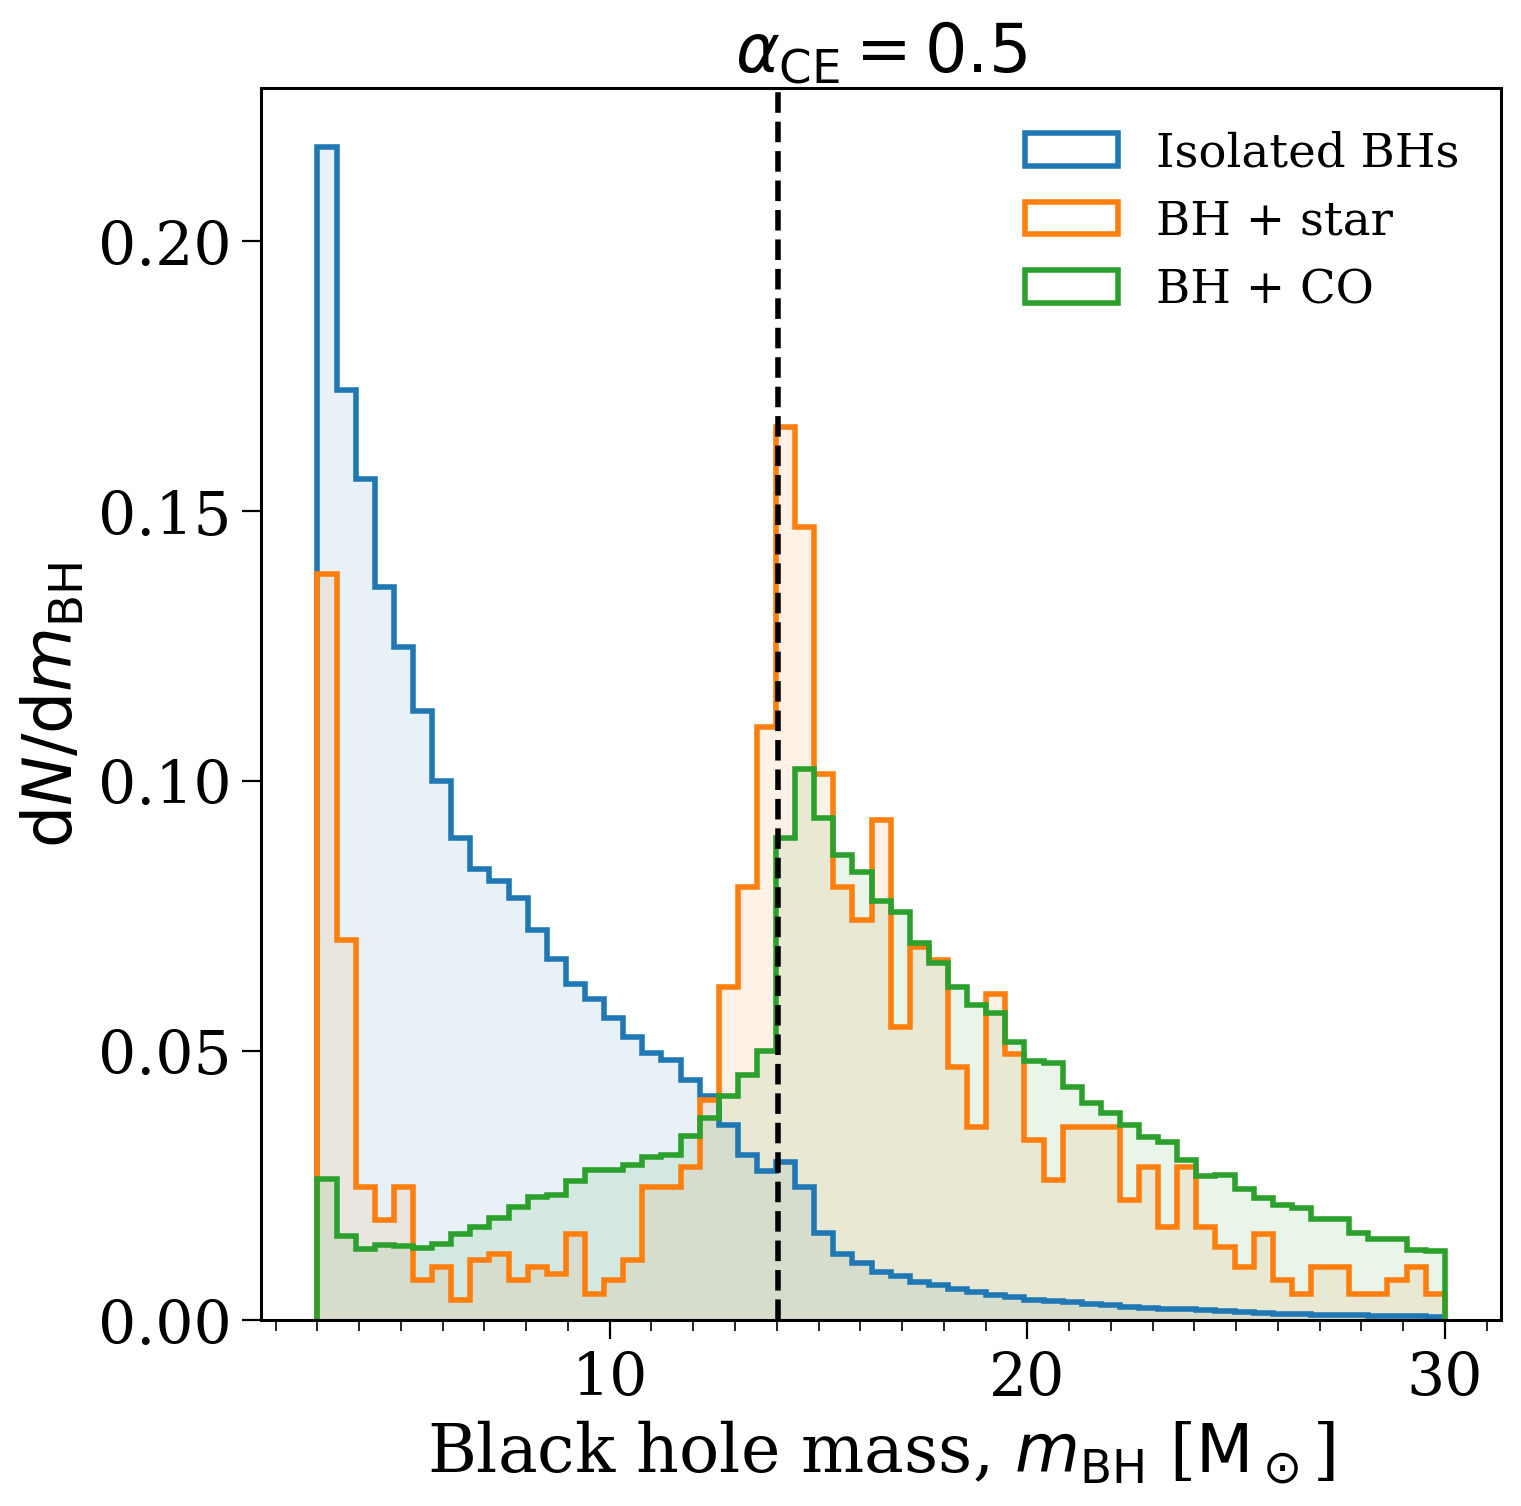

$\alpha_{\rm CE} = 2.0$ 1980


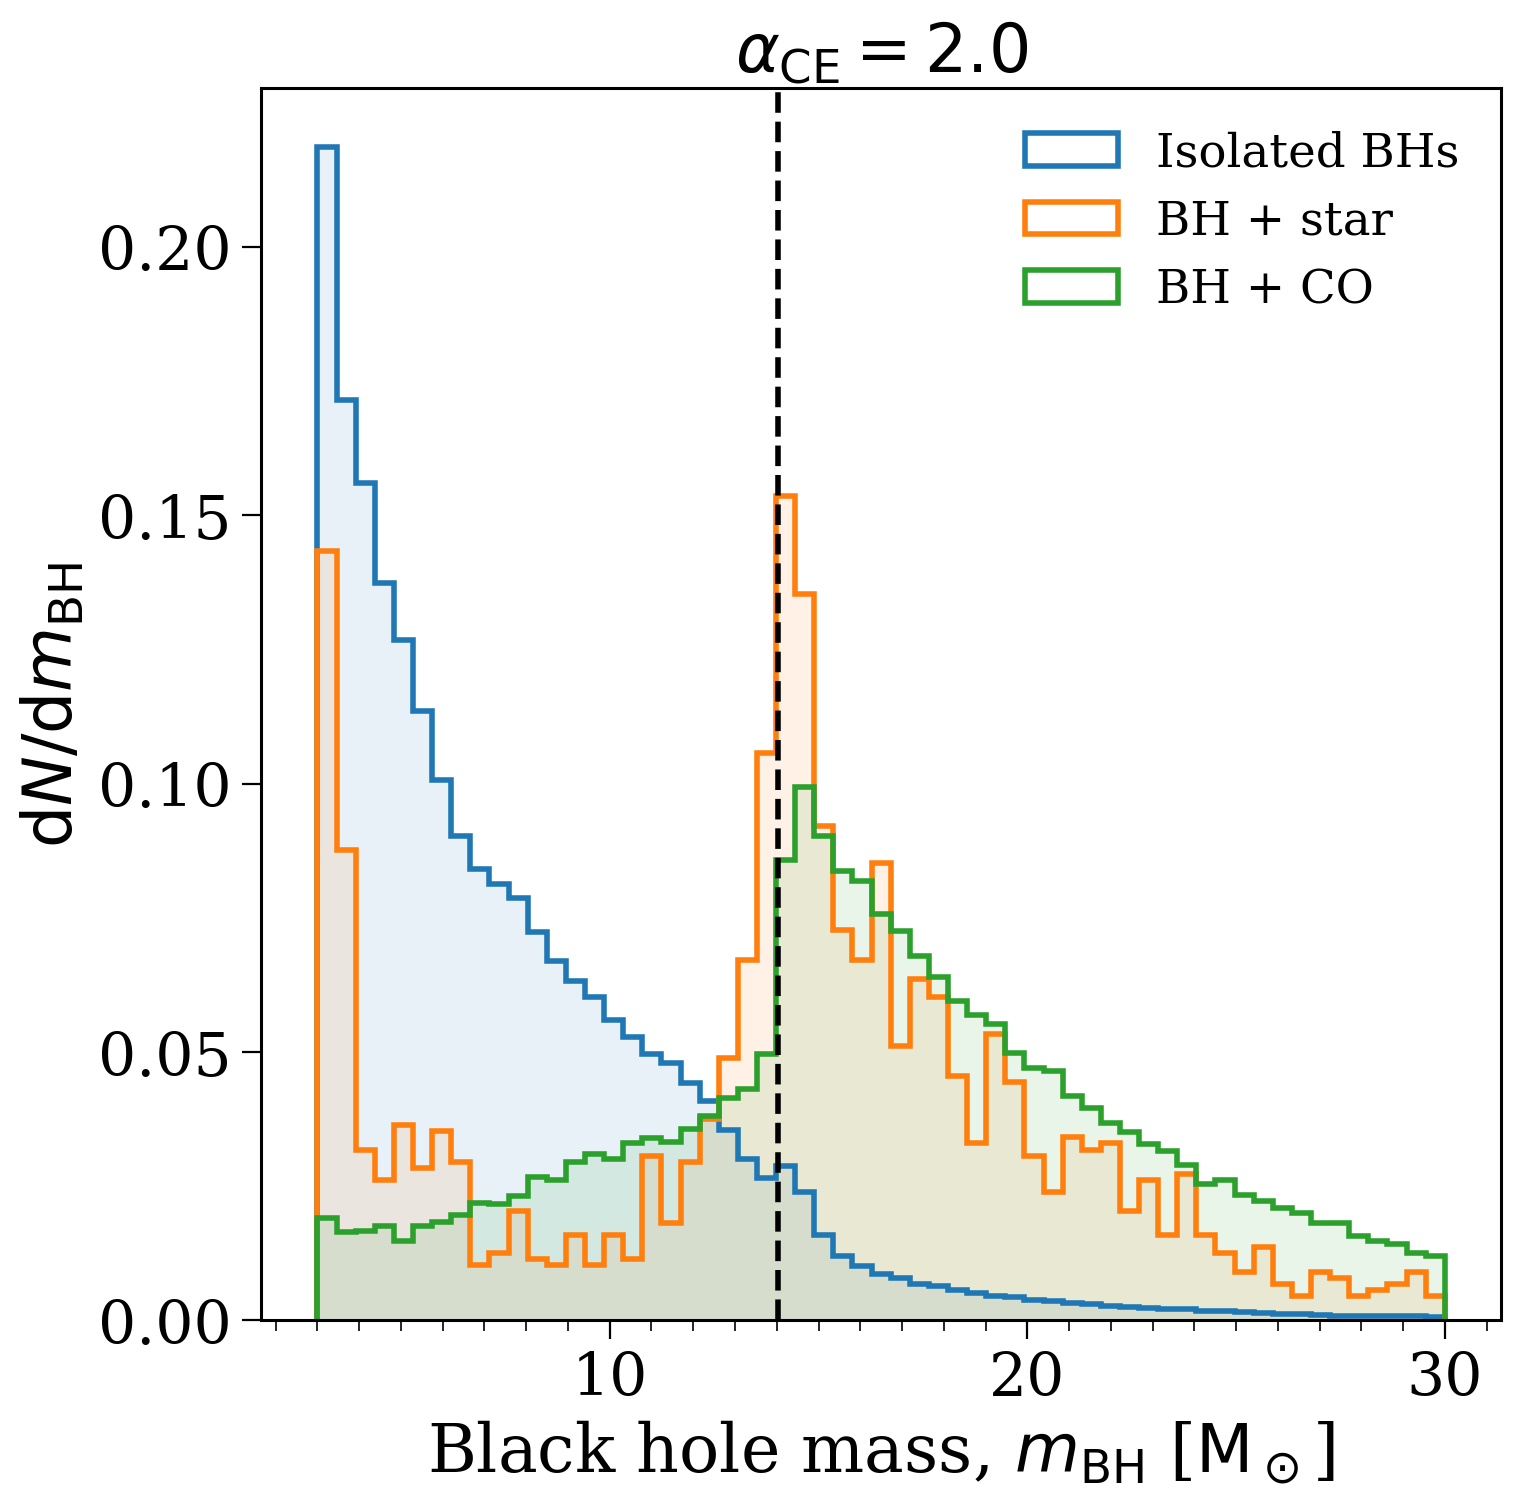

$\alpha_{\rm CE} = 10.0$ 2319


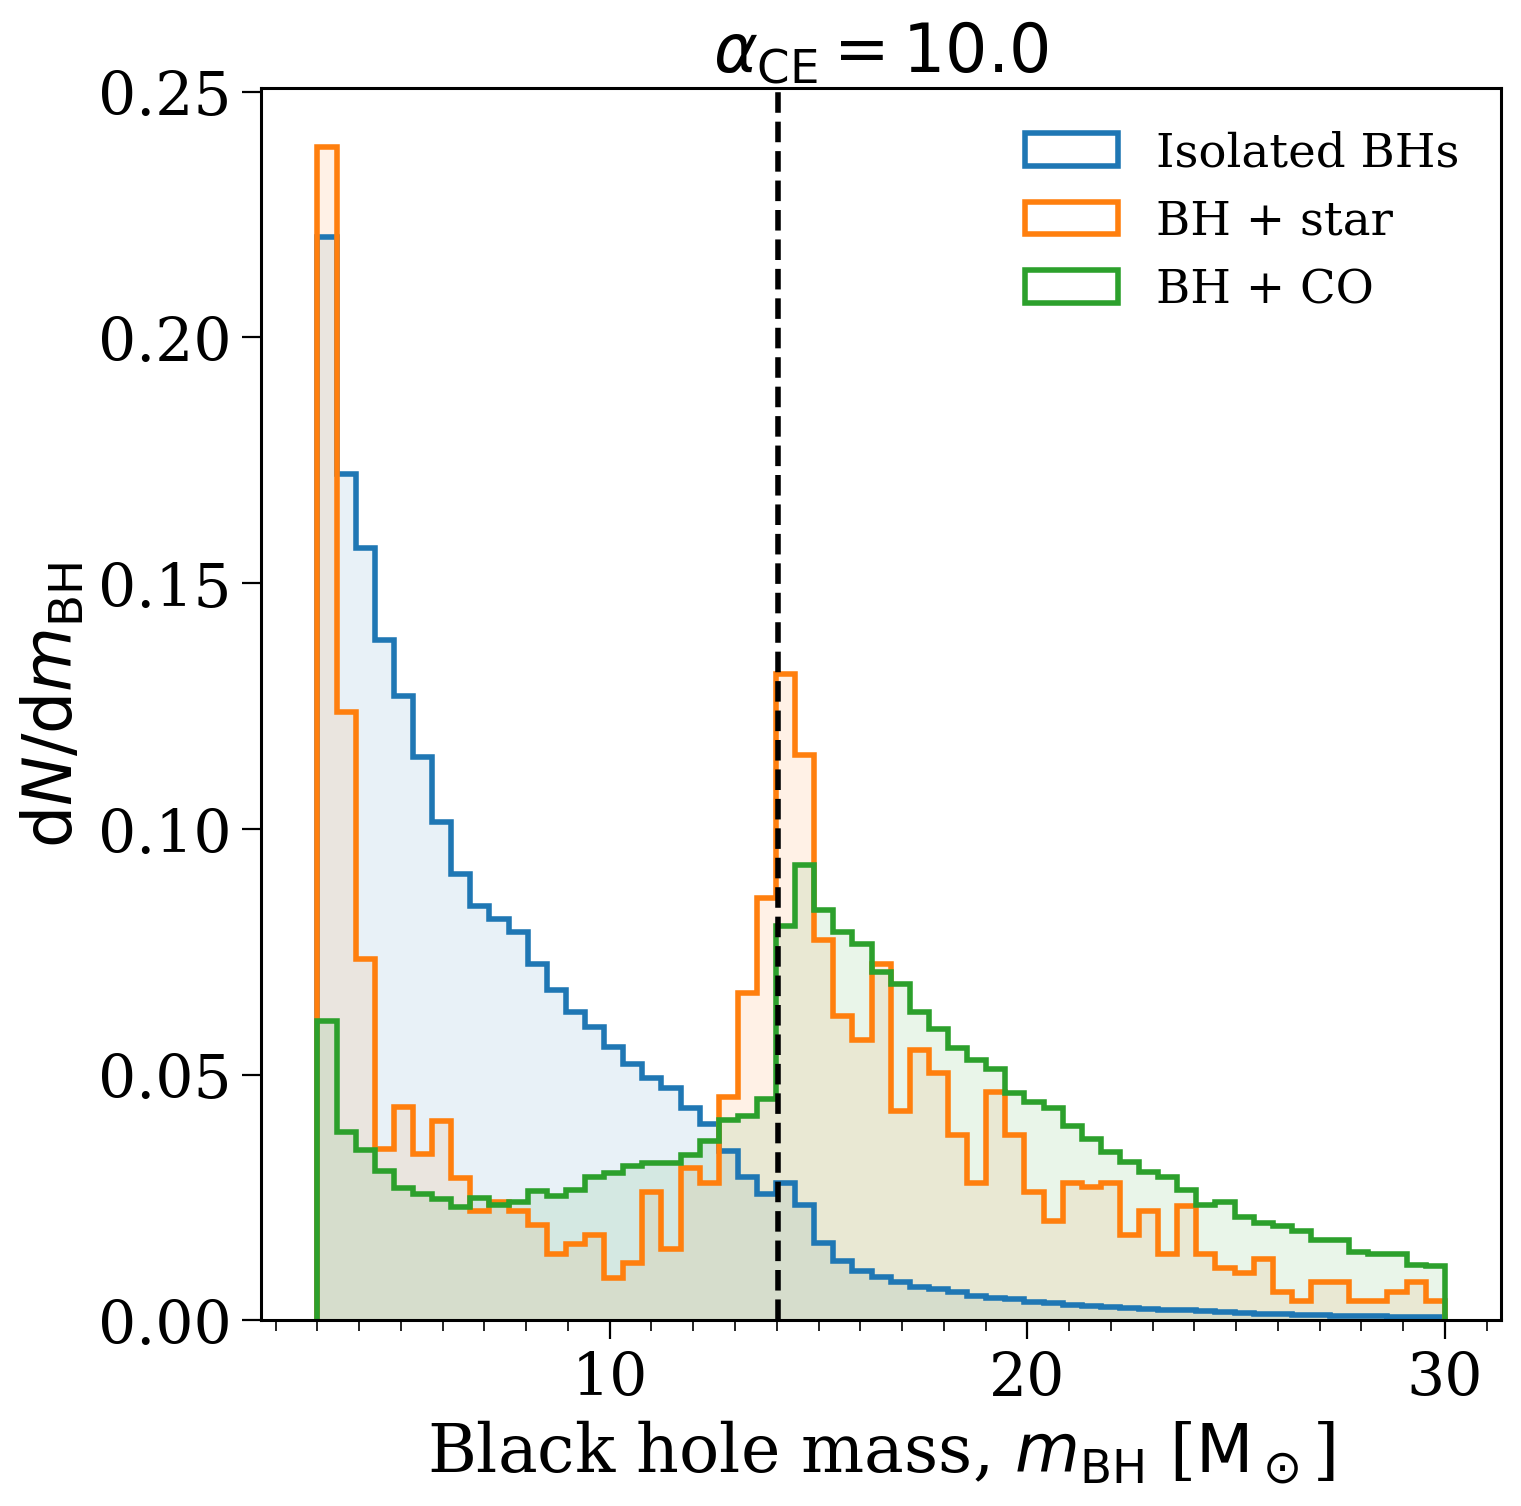

$q_{\rm crit, B} = 0$ 1854


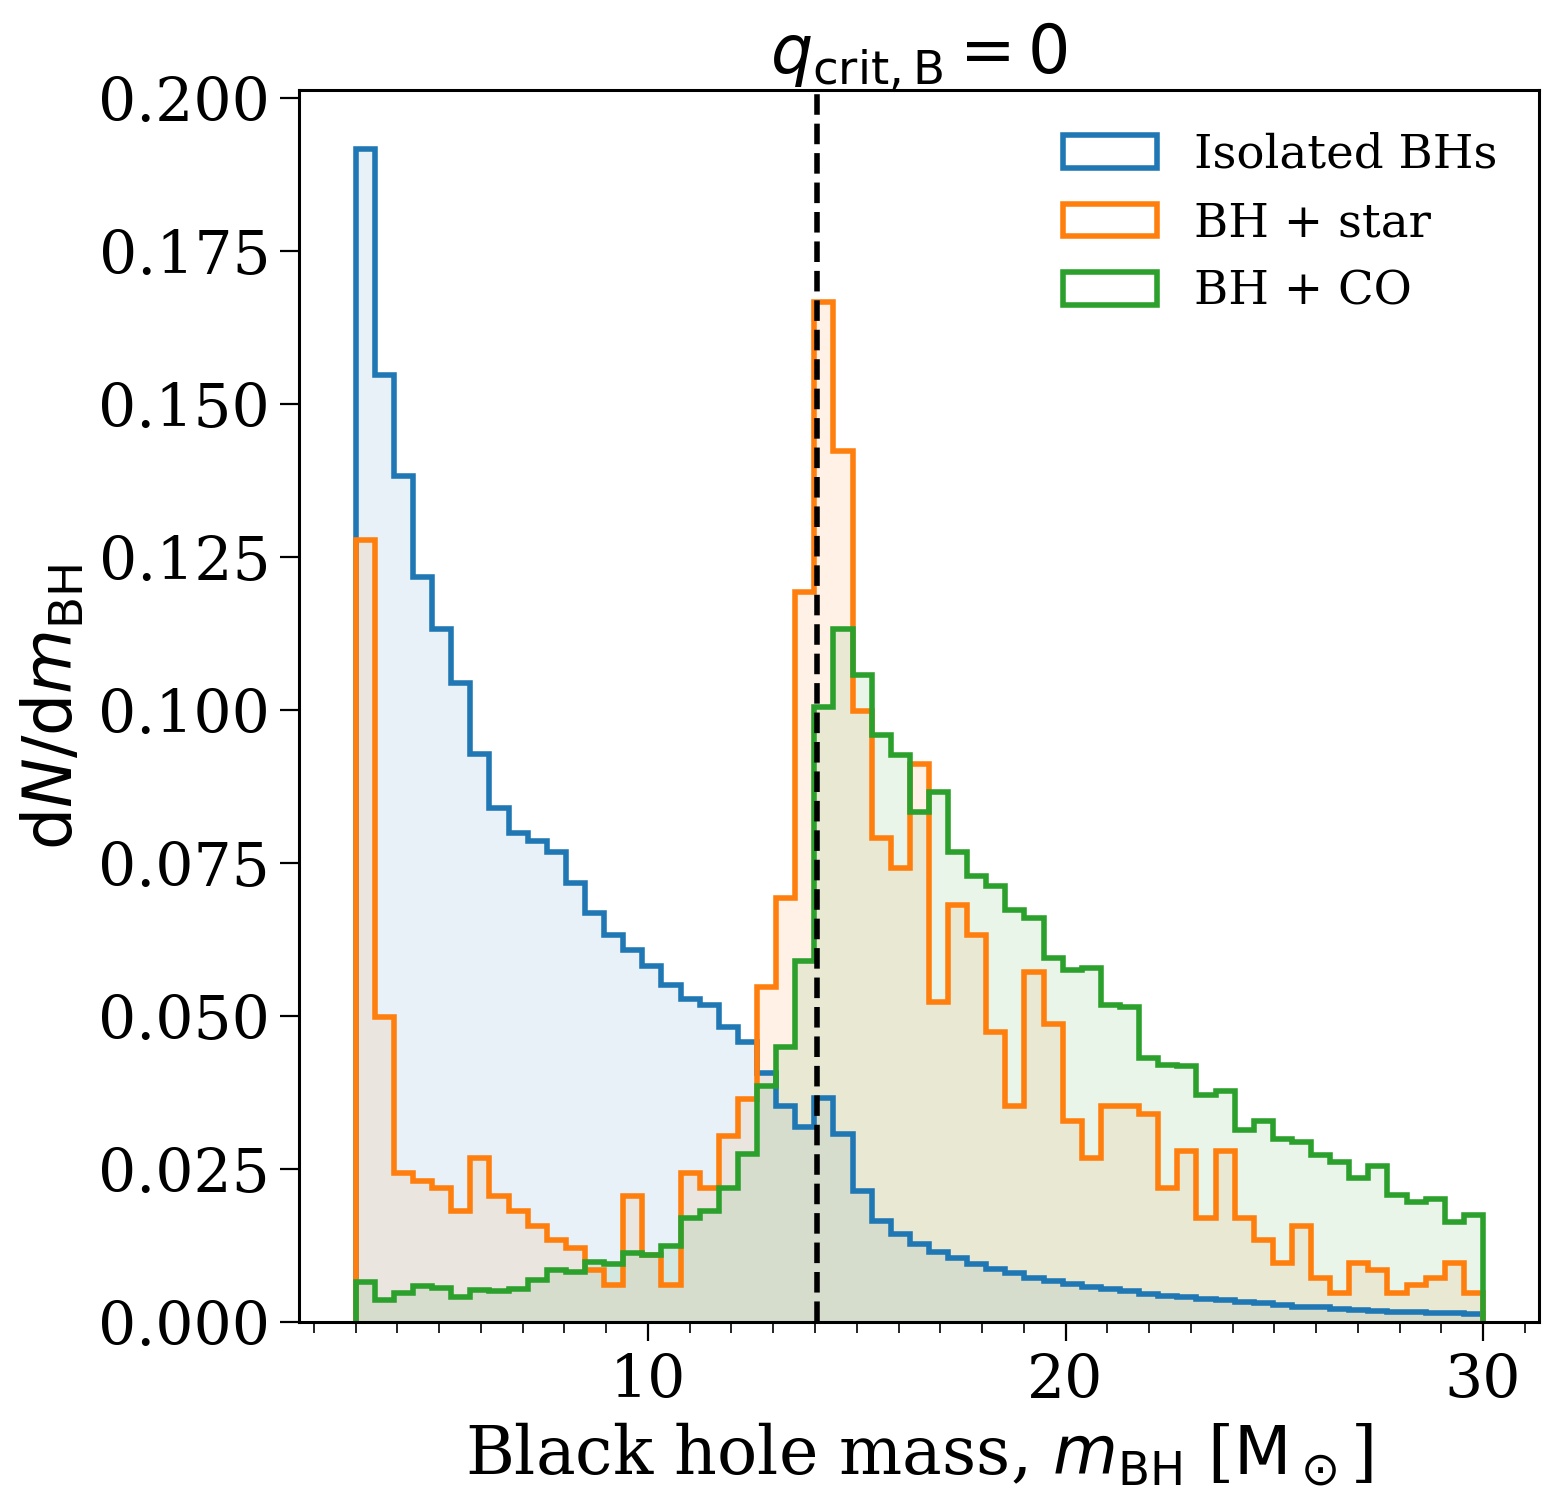

$q_{\rm crit, B} = \infty$ 2483


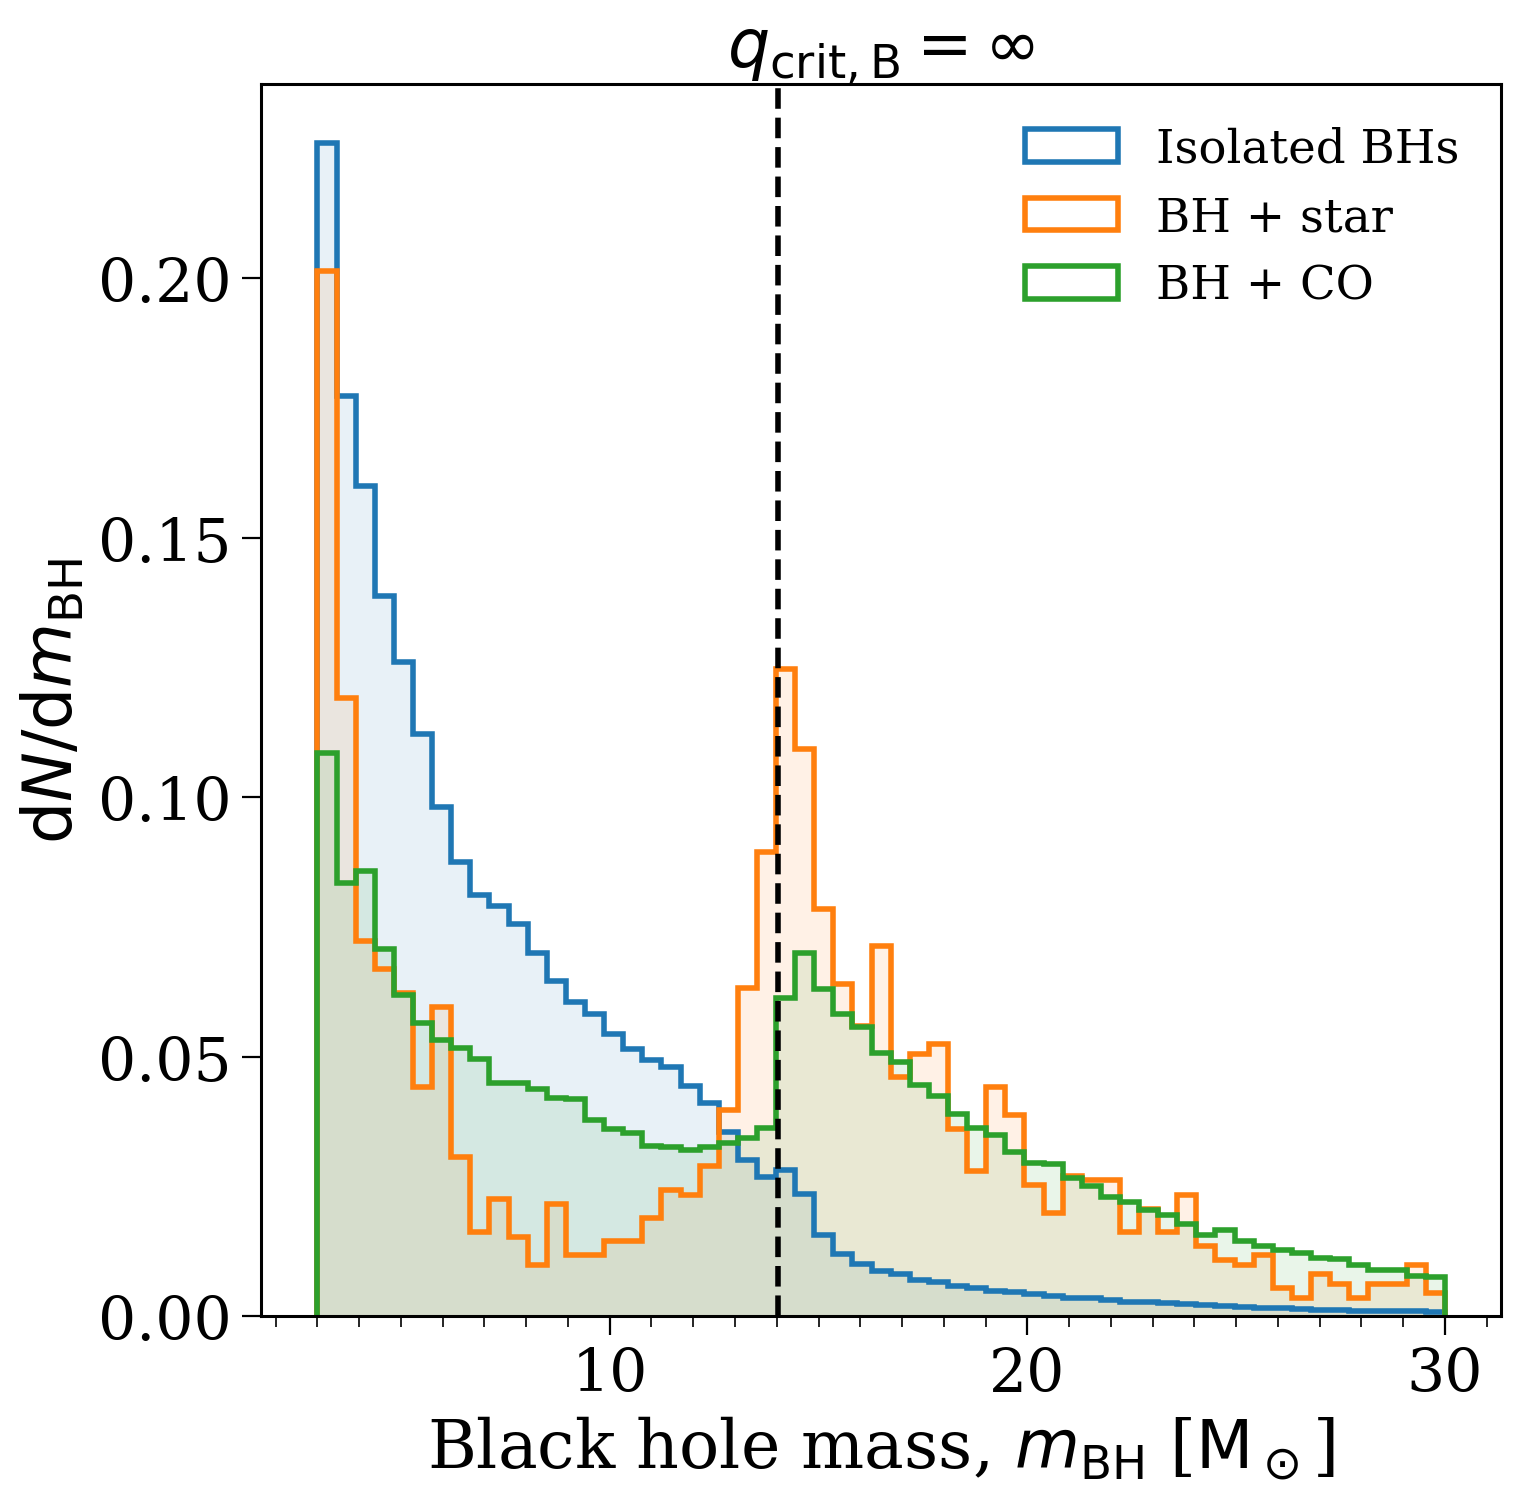

In [15]:
for pop_label in list(data.keys()):#['$f_{\\rm bin} = 1.0$', 'Fryer+2012 Rapid', 'Mandel\\&Muller2020', 'Maltsev+2025']:

    if pop_label == '$f_{\\rm bin} = 0.0$':
        continue

    fig, ax = plt.subplots(figsize=(8, 8))

    bins = np.linspace(3, 30, 60)
    density = True

    # pop_label = "Mandel\\&Muller2020"

    bh_bh = (data[pop_label]["sep"]["BH"] > 0) & (data[pop_label]["primary"]["BH"]) & (data[pop_label]["companion"]["BH"] == 14)
    bh_ns = (data[pop_label]["sep"]["BH"] > 0) & (data[pop_label]["companion"]["BH"] == 13)
    bh_wd = (data[pop_label]["sep"]["BH"] > 0) & (np.isin(data[pop_label]["companion"]["BH"], [10, 11, 12]))
    bh_star = (data[pop_label]["sep"]["BH"] > 0) & (data[pop_label]["companion"]["BH"] < 10)

    print(pop_label, bh_star.sum())

    for masses, colour, label in zip(
        [
            data[pop_label]["mass"]["BH"][data[pop_label]["sep"]["BH"] <= 0],
            data[pop_label]["mass"]["BH"][bh_star],
            data[pop_label]["mass"]["BH"][bh_bh | bh_ns | bh_wd],
        ],
        ['tab:blue', 'tab:orange', 'tab:green'],
        ["Isolated BHs","BH + star", "BH + CO"]
    ):
        plotting.nice_transparent_hist(
            ax, data=masses, bins=bins, colour=colour, alpha=0.1, label=label, density=density, lw=2
        )

        # ["Isolated BHs\n(Microlensing)","BH + star\n(Astrometry or XRBs)", "BH + compact object\n(Gravitational waves)"]

    ax.axvline(14.04, ls='--', c='k', lw=2)

    # ax.annotate("Minimum BH mass\nfor full fallback", xy=(12, 0.14), fontsize=0.6*fs, ha='center', va='center', rotation=90)

    ax.xaxis.set_major_locator(plt.MultipleLocator(10))
    ax.xaxis.set_minor_locator(plt.MultipleLocator(1))

    leg = ax.legend(fontsize=0.7*fs, frameon=False, loc='upper right')#, labelspacing=1.2)

    ax.set(
        xlabel=r"Black hole mass, $m_{\mathrm{BH}}$ [$\rm M_\odot$]",
        ylabel=r"${\rm d}N/{\rm d}m_{\mathrm{BH}}$",
    )

    ax.set_title(plot_labels[labels.index(pop_label)], fontsize=fs)

    # plt.savefig("../plots/bh_binary_masses.pdf", bbox_inches='tight', format='pdf')
    plt.show()